# **Notes for the reader:**


1. Before running the notebook, add the shared folder as a shortcut to your MyDrive root and keep its name exactly NLP_project.


2. Since this notebook is very long and uploads many datasets of big dimensions, some "saving points" have been created. If, for any reason, the notebook crashes, it is always runnable from these saving points (without necessity of rerunning the previous cells):

- 1  
- 2
- 3.1.2
- 3.2.4
- 3.4
- 3.5.3  
- 4  
- 5  

3. Since the initial dataset counts more than 140,000 articles, some computational passages were run externally on HPC: all those passages that were computationally too expensive to run on the full corpus, and that would have made the notebook slow and impractical to run end-to-end. The `.py` and `.sh` files ran on HPC are available in the "NLP_project" shared folder, in Google Drive, together with the output produced by HPC. These output files will be uploaded when needed on this notebook, when necessary for the course of the analysis. The connection to the shared folder is possible through this cell.

 4. It is necessary to run this cell before any of the above cited "saving point":

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **1 EDA**

## **1.1 Dataset loading and initial cleaning**

As first step we upload a dataset taken from Kaggle with more than 140.000 articles taken from The Guardian from January 2016 through end of June 2022.

The original Dataset contain columns not relevant, so we select only the columns useful for the analysis:

- bodyContent (article's text)
- publication date
- title
- section (section of the newspaper in which it was published)

We then perform basic cleaning by formatting the date column, removing rows with missing values, removing duplicate rows, and creating additional time-based variables that will be used in the exploratory analysis.

In [ ]:
# Load the dataset
import pandas as pd
guardian_articles = pd.read_parquet("/content/drive/MyDrive/NLP_project/guardian_articles.parquet")
guardian_articles.head()

,article_id,sectionName,webTitle,webUrl,bodyContent,webPublicationDate,id
0,us-news/2016/jan/31/iowa-caucus-underdog-candi...,US news,Iowa underdogs put on brave faces despite all ...,https://www.theguardian.com/us-news/2016/jan/3...,As polling day looms and the cameras turn only...,2016-01-31T23:53:37Z,1
1,us-news/2016/jan/31/iowa-caucus-worlds-most-pa...,US news,Iowa caucus: hologram eagle and Jesus star on ...,https://www.theguardian.com/us-news/2016/jan/3...,"In Des Moines on Sunday, the Guardian was give...",2016-01-31T23:46:28Z,2
2,world/2016/jan/31/tanzania-britsh-helicopter-p...,World news,British pilot in Tanzania 'manoeuvred ​to save...,https://www.theguardian.com/world/2016/jan/31/...,A British pilot who was shot dead by an elepha...,2016-01-31T23:43:48Z,3
3,football/2016/jan/31/late-winner-gets-usa-off-...,Football,USA 3-2 Iceland | International friendly match...,https://www.theguardian.com/football/2016/jan/...,USA took a step toward shaking off the ghosts ...,2016-01-31T23:30:49Z,4
4,football/2016/jan/31/blackburn-paul-lambert-ox...,Football,Reinvigorated Paul Lambert reflects after impr...,https://www.theguardian.com/football/2016/jan/...,"The clean-shaven, spectacle free and suspiciou...",2016-01-31T22:30:10Z,5


In [ ]:
# Select the columns relevant for the analysis and perform basic cleaning
articles = guardian_articles[["bodyContent", "webPublicationDate", "webTitle", "sectionName"]].copy()

# Keep only the date component and rename the column
articles["webPublicationDate"] = articles["webPublicationDate"].str[:10]
articles = articles.rename(columns={"webPublicationDate": "Date"})

# Check missing values
print(f"bodyContent nulls: {articles['bodyContent'].isna().sum()}")
print(f"Date nulls: {articles['Date'].isna().sum()}")
print(f"webTitle nulls: {articles['webTitle'].isna().sum()}")
print(f"sectionName nulls: {articles['sectionName'].isna().sum()}")

# Count rows before cleaning
n_initial = len(articles)

# Remove rows with missing values in the selected columns
articles_clean = articles.dropna(subset=["bodyContent", "Date", "webTitle", "sectionName"]).copy()

# Count duplicate rows before dropping them
duplicate_count = articles_clean.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

# Remove duplicate rows
articles_clean = articles_clean.drop_duplicates().copy()

# Final count and deleted rows
n_final = len(articles_clean)
print(f"Articles deleted during cleaning: {n_initial - n_final}")
print(f"Current number of articles: {n_final}")

articles_clean.head(1)

bodyContent nulls: 1108
Date nulls: 0
webTitle nulls: 0
sectionName nulls: 0
Duplicate rows: 12
Articles deleted during cleaning: 1120
Current number of articles: 148719


,bodyContent,Date,webTitle,sectionName
0,As polling day looms and the cameras turn only...,2016-01-31,Iowa underdogs put on brave faces despite all ...,US news


In [ ]:
# Convert dates and create time-based columns used in the analysis
articles_clean["Date"] = pd.to_datetime(articles_clean["Date"], errors="coerce")
print("Min date:", articles_clean["Date"].min())
print("Max date:", articles_clean["Date"].max())

# Add four time-based columns used for temporal analysis:
# - month_start: first day of the month of publication, used to aggregate articles by month
# - year_month: publication month in YYYY-MM format, useful for plotting and grouping
# - year: publication year
# - month: publication month as an integer from 1 to 12
articles_clean["month_start"] = articles_clean["Date"].dt.to_period("M").dt.to_timestamp()
articles_clean["year_month"] = articles_clean["month_start"].dt.strftime("%Y-%m")
articles_clean["year"] = articles_clean["Date"].dt.year
articles_clean["month"] = articles_clean["Date"].dt.month

articles_clean.head(1)

Min date: 2016-01-25 00:00:00
Max date: 2022-06-30 00:00:00


,bodyContent,Date,webTitle,sectionName,month_start,year_month,year,month
0,As polling day looms and the cameras turn only...,2016-01-31,Iowa underdogs put on brave faces despite all ...,US news,2016-01-01,2016-01,2016,1


## **1.2 Temporal distribution of the articles**


We then inspect how the number of articles varies over time. In particular, we analyze the monthly and yearly distribution of the corpus in order to identify potential imbalances or irregularities in the temporal coverage of the dataset.

<Axes: title={'center': 'Number of articles per month'}, xlabel='year_month'>

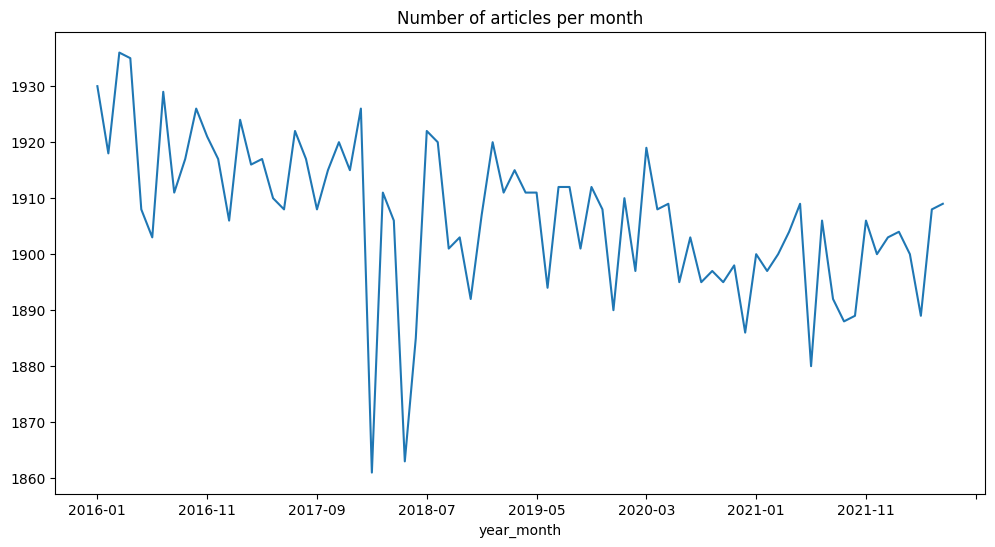

In [ ]:
# Plot the number of articles published each month to inspect temporal coverage across the corpus
monthly_counts = (articles_clean.groupby("year_month").size().sort_index())
monthly_counts.plot(figsize=(12, 6), title="Number of articles per month")

The monthly distribution is relatively stable overall, although a few months show lower article volume. Since monthly article counts are not perfectly uniform, later analyses normalize topic frequencies by monthly totals rather than relying on raw counts alone.

<Axes: title={'center': 'Number of articles per year'}, xlabel='year'>

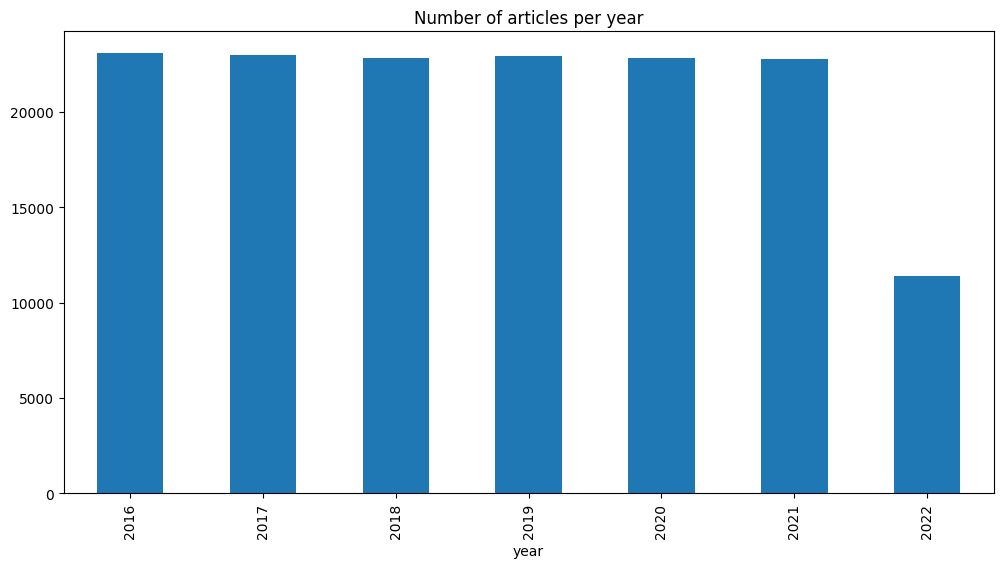

In [ ]:
# Plot the number of articles published each year to inspect yearly coverage of the dataset
yearly_counts = (articles_clean.groupby("year").size())
yearly_counts.plot(kind="bar", figsize=(12, 6), title="Number of articles per year")

The yearly distribution shows that the last year contains substantially fewer articles than the previous ones, almost exactly a half. This is not a meaningful drop in publication volume, but a consequence of the dataset ending on 2022-06-30, so the final year is only partially covered.

## **1.3 Sections**


We examine the distribution of Guardian's Sections in order to understand the thematic composition of the corpus. In particular, we inspect the frequency of section labels, their long-tail structure, and how the relative prevalence of the main Sections changes over time.

Number of unique section names: 159


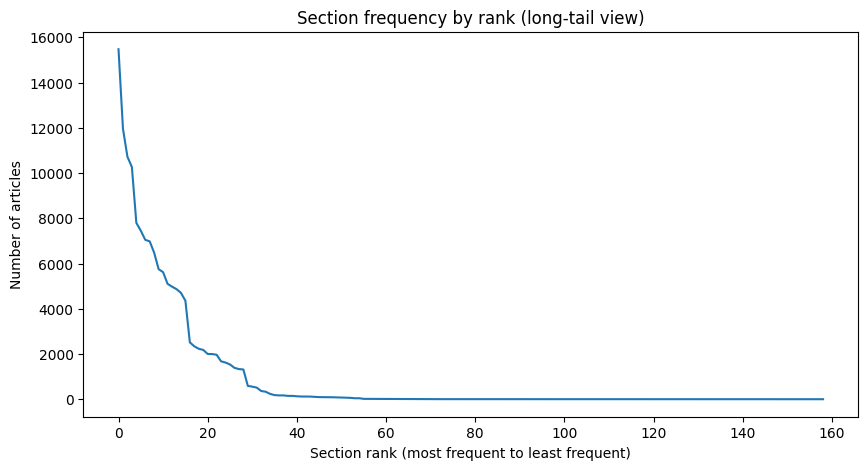

In [ ]:
# Count section categories and inspect their long-tail distribution
import matplotlib.pyplot as plt

print("Number of unique section names:", articles_clean["sectionName"].nunique())

# Raw number of articles per Section
section_counts = articles_clean["sectionName"].value_counts()

ax = section_counts.reset_index(drop=True).plot(figsize=(10, 5), title="Section frequency by rank (long-tail view)")
ax.set_xlabel("Section rank (most frequent to least frequent)")
ax.set_ylabel("Number of articles")
plt.show()

The corpus contains **159 distinct section categories**, indicating substantial thematic variety. At the same time, the rank-frequency curve shows a clear **long-tail distribution** (curiously resembling a Zipflaw's law): a small number of sections account for a large share of the articles, while many sections appear relatively infrequently. This suggests that the dataset is broad in topical coverage, but not balanced across topics. As a result, later analyses based on section membership should be interpreted with care, since a few dominant sections contribute disproportionately to the corpus.

In [ ]:
# Display the top section categories by count and percentage share
section_pct = articles_clean["sectionName"].value_counts(normalize=True).mul(100).round(2)
overview = pd.DataFrame({"count": section_counts, "pct": section_pct})
display(overview.head(10))

,count,pct
sectionName,,
World news,15475,10.41
Opinion,11962,8.04
Football,10722,7.21
Sport,10266,6.90
Australia news,7798,5.24
US news,7451,5.01
Politics,7047,4.74
Business,6980,4.69
UK news,6475,4.35


The top section categories confirm that the corpus is concentrated around a relatively small set of dominant themes. **World news** is the largest section, accounting for just over **10%** of all articles, followed by **Opinion**, **Football**, and **Sport**.

It's interesting to notice how **Football** alone accounts for more than all the other sports summed up, unveling the undiscuss predominance it holds for the readers.

Furthermore, **Australia news** are covered more than **US news** and **UK news**, surprisingly for a British newspaper.

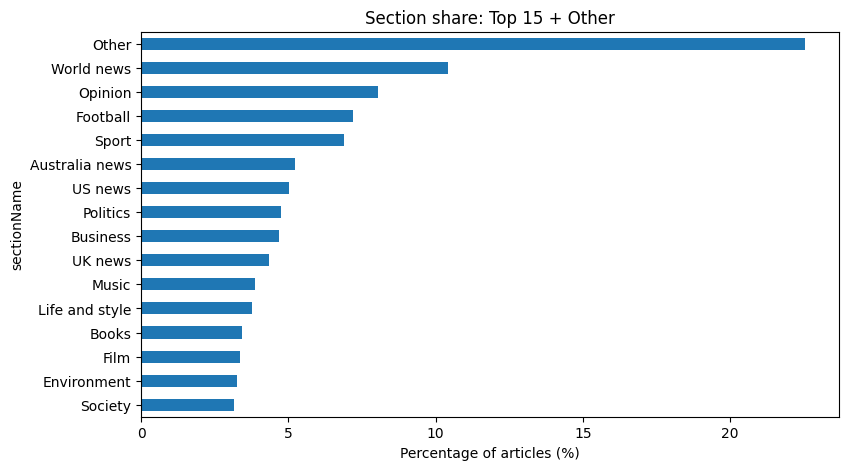

In [ ]:
# Plot the overall section distribution as Top 15 sections plus an aggregated 'Other' category
top_pct = section_pct.head(15).copy()
top_pct["Other"] = 100 - top_pct.sum()

ax = top_pct.sort_values().plot(kind="barh", figsize=(9, 5), title=f"Section share: Top 15 + Other")
ax.set_xlabel("Percentage of articles (%)")
ax.set_ylabel("sectionName")
plt.show()

When the section distribution is summarized as the **top 15 categories plus an aggregated “Other” group**, it becomes even clearer that the corpus, although dominated by few indicidual sections, is highly fragmented among super small ones. Let's just keep in mind that the **“Other”** category, despite accounting alone for more than any single named section, contains 144 sub-sections.

Another interesting analysis is the temporal evolution of articles' proportions across sections. This unveils, behind an apparent overall stability, some intersting patterns.

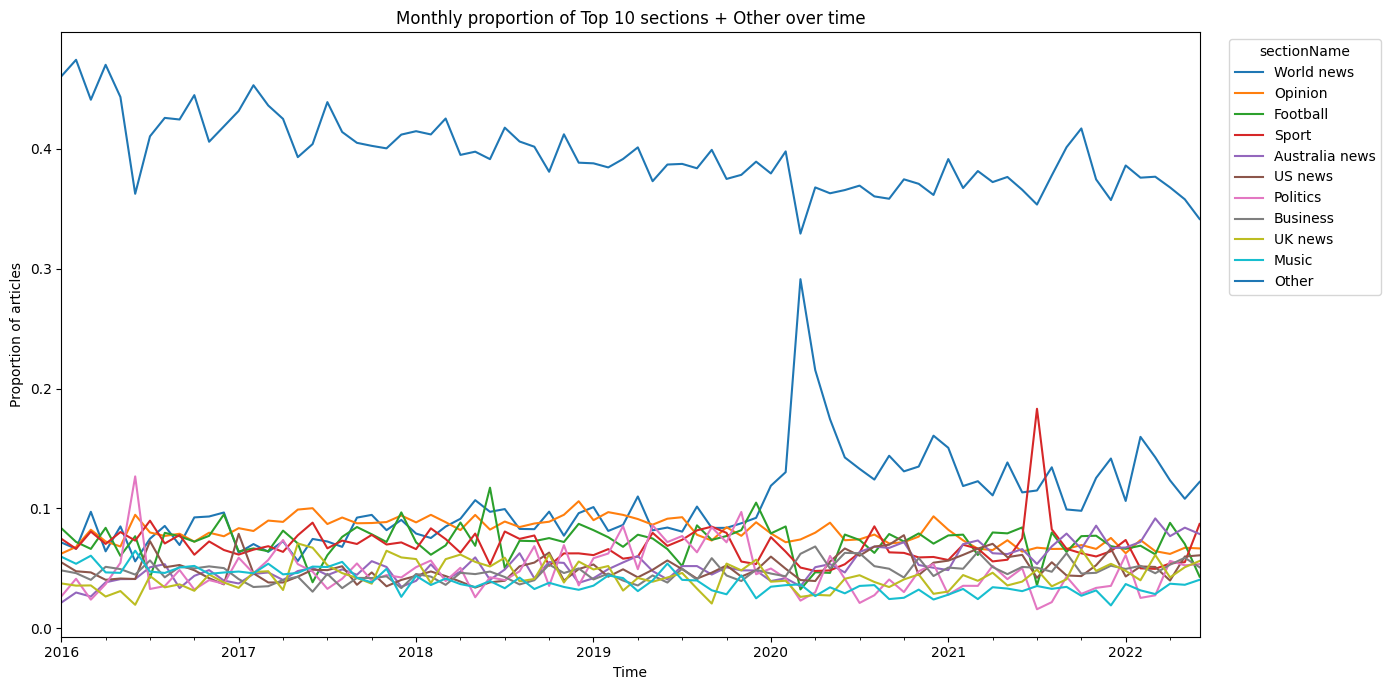

In [ ]:
# Plot how the relative weight of the main sections changes over time
df = articles_clean.copy()

top_n = 10
top_sections = df["sectionName"].value_counts().head(top_n).index.tolist()

df["section_grouped"] = df["sectionName"].where(df["sectionName"].isin(top_sections), "Other")

monthly_section_counts = (df.groupby(["month_start", "section_grouped"]).size().unstack(fill_value=0))

desired_cols = top_sections + ["Other"]
monthly_section_counts = monthly_section_counts.reindex(columns=desired_cols, fill_value=0)

monthly_section_props = monthly_section_counts.div(monthly_section_counts.sum(axis=1), axis=0)

ax = monthly_section_props.plot(figsize=(14, 7), title=f"Monthly proportion of Top {top_n} sections + Other over time")
ax.set_xlabel("Time")
ax.set_ylabel("Proportion of articles")
plt.legend(title="sectionName", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Only by way of example:

1.  **World news** becomes noticeably more prominent around **March 2020**, coinciding with the global spread of Covid-19. This likely reflects the increased attention devoted to developments in other countries, such as China and Italy, during the first phase of the pandemic. After this point, *World news* remains somewhat more prominent than in the earlier years, suggesting a lasting increase in the international coverage.

2. A second visible change concerns **Sport**, whose relative weight increases around **mid-2021**. This likely reflects the concentration of major sporting events that had been postponed because of the pandemic, including **UEFA Euro 2020**, **Copa América 2021**, and the **Tokyo Olympics**.

3. A drop in **World news** can be detected in June 2016, that is exactly in correspondence of the Brexit referendum, showcasing a more internal focus of the british press in that period. Indeed, simultaneously, a small peak in **Politics** can be spotted.

4. A small local peak can be spotted also in January 2017 for **US news**, in correpsondence of the inaugration of Donald Trump as 45th president of the USA.


Overall, this plot shows that section composition is affected not only by long-term editorial structure, but also by major external events that temporarily reshape the news agenda.

## **1.4 Text statistics**

We analyze basic textual properties of the corpus, focusing on title and body length. This allows us to describe the typical size of the articles and identify unusually short or unusually long documents.

In [ ]:
# Compute title and body length (in characters and words) for descriptive analysis
articles_clean["title_len_chars"] = articles_clean["webTitle"].str.len()
articles_clean["title_len_words"] = articles_clean["webTitle"].str.split().str.len()
articles_clean["body_len_chars"] = articles_clean["bodyContent"].str.len()
articles_clean["body_len_words"] = articles_clean["bodyContent"].str.split().str.len()

# Summarize overall title and body length statistics
text_stats_overall = articles_clean[["title_len_words", "body_len_words", "title_len_chars", "body_len_chars"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T

display(text_stats_overall)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
title_len_words,148719.0,11.384752,3.014992,1.0,10.0,11.0,13.0,15.0,17.0,19.00,33.0
body_len_words,148719.0,774.612101,495.961191,0.0,479.0,703.0,944.0,1247.0,1540.0,2551.00,27171.0
title_len_chars,148719.0,68.875335,15.580840,8.0,61.0,69.0,78.0,88.0,94.0,106.00,203.0
body_len_chars,148719.0,4590.903563,2899.114384,1.0,2858.0,4177.0,5603.0,7404.0,9043.1,14843.82,160379.0


Titles are fairly short and homogeneous: the average title is about **11 words** and **69 characters**, with limited variation. Article bodies are much more variable. The median body length is about **703 words**, but the mean is higher (**775 words**), which suggests a right-skewed distribution with some very long articles. This is also visible in the upper tail: while 75% of the articles stay below about **944 words**, the longest texts are much larger, reaching several thousand words.

We also compare basic text statistics across the main section categories to see whether different Sections tend to use different article lengths or different levels of lexical simplicity. For each article we compute: the average number of words in both titles and articles; the average word length for both titles and articles.

In [ ]:
df = articles_clean.copy()

# 1. Keep top 10 sectionName values, collapse the rest into "Other"
top_n = 10
top_sections = df["sectionName"].value_counts().head(top_n).index.tolist()

df["section_grouped"] = df["sectionName"].where(df["sectionName"].isin(top_sections), "Other")

# 2. Body text statistics
df["body_num_words"] = df["bodyContent"].str.split().str.len()
df["body_avg_word_len"] = (
    df["bodyContent"].str.findall(r"\b\w+\b").apply(
        lambda words: sum(len(w) for w in words) / len(words) if len(words) > 0 else 0
    )
)

# 3. Title text statistics
df["title_num_words"] = df["webTitle"].str.split().str.len()
df["title_avg_word_len"] = (
    df["webTitle"].str.findall(r"\b\w+\b").apply(
        lambda words: sum(len(w) for w in words) / len(words) if len(words) > 0 else 0
    )
)

# 4. Aggregate averages by section
section_text_summary = (
    df.groupby("section_grouped")
    .agg(
        body_avg_num_words=("body_num_words", "mean"),
        body_avg_word_len=("body_avg_word_len", "mean"),
        title_avg_num_words=("title_num_words", "mean"),
        title_avg_word_len=("title_avg_word_len", "mean"),
    )
    .round(2)
)

# 5. Order rows
section_text_summary = section_text_summary.sort_values(by="body_avg_num_words", ascending=False)

display(section_text_summary)

,body_avg_num_words,body_avg_word_len,title_avg_num_words,title_avg_word_len
section_grouped,,,,
US news,882.03,4.78,11.48,5.15
Opinion,870.05,4.70,15.00,4.74
Australia news,815.99,4.87,12.32,5.41
Sport,784.42,4.42,12.07,4.97
World news,777.62,4.79,10.71,5.18
Other,773.96,4.63,10.85,4.97
Football,771.66,4.51,11.57,5.08
Politics,757.12,4.69,10.57,5.03
Music,668.26,4.62,10.95,5.10


A few interesting takeaways emerge from this plot:
1. The table shows that article length varies across sections. **US news** and **Opinion** have the longest bodies on average, while sections such as **Business**, **UK news**, and **Music** are shorter.

2. Average word length varies less, but there are still some differences: **Sport** and **Football** tend to use slightly shorter words in the body, which is consistent with a simpler and more direct writing style.

3. It's also interesting to notice how for some sections the average title words length is bigger than the body's one. For sections llike **Football** this could be for example explained by the use of long player's or club's names in the title.

Now we can focus on spotting outliers in the distribution of articles, to detect unusually short or long articles. To do so, we use Tukey's rule: we identify the articles falling below

$$
q_1 - 1.5 \times IQR
$$

and above

$$
q_3 + 1.5 \times IQR
$$

In [ ]:
# Detect unusually short or long articles based on the interquartile range of body length
q1 = articles_clean["body_len_words"].quantile(0.25)
q3 = articles_clean["body_len_words"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_body = articles_clean[
    (articles_clean["body_len_words"] < lower_bound) |
    (articles_clean["body_len_words"] > upper_bound)
].copy()

print("Body length outliers:", len(outliers_body))
print("Outlier share (%):", round(len(outliers_body) / len(articles_clean) * 100, 2))

print("Longest outliers:")
display(
    outliers_body[["Date", "sectionName", "webTitle", "body_len_words"]]
    .sort_values("body_len_words", ascending=False)
    .head(5)
)

Body length outliers: 6065
Outlier share (%): 4.08
Longest outliers:


,Date,sectionName,webTitle,body_len_words
102000,2020-05-22,World news,"Doctors, nurses, porters, volunteers: the UK h...",27171
12099,2016-07-29,Business,Flydubai flight records – the leaked documents,16227
92163,2019-12-20,Stage,The Michael Billington archive: highlights fro...,12563
115103,2020-12-21,Info,The Guardian in 2020,11838
61256,2018-08-24,Stage,The best shows at the Edinburgh festival 2018,11490


In [ ]:
# Separate lower-tail and upper-tail outliers
lower_outliers = articles_clean[articles_clean["body_len_words"] < lower_bound].copy()
upper_outliers = articles_clean[articles_clean["body_len_words"] > upper_bound].copy()

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Minimum body length:", articles_clean["body_len_words"].min())
print("Maximum body length:", articles_clean["body_len_words"].max())
print()

print("Lower-tail outliers:", len(lower_outliers))
print("Upper-tail outliers:", len(upper_outliers))

Lower bound: -218.5
Upper bound: 1641.5
Minimum body length: 0
Maximum body length: 27171

Lower-tail outliers: 0
Upper-tail outliers: 6065


Using the interquartile-range rule, about **4.1%** of the corpus is flagged as body-length outliers. The longest articles are far above the typical range, often exceeding several thousand words. These extreme cases are not concentrated in a single section: they appear in **World news**, **Business**, **Stage**, **Politics**, **Technology**, and **Music**, suggesting that unusually long articles reflect specific editorial formats rather than a single topical domain. In many cases, these articles seem likely to correspond to special features, archival summaries, reviews, or long-form pieces rather than standard news reporting.

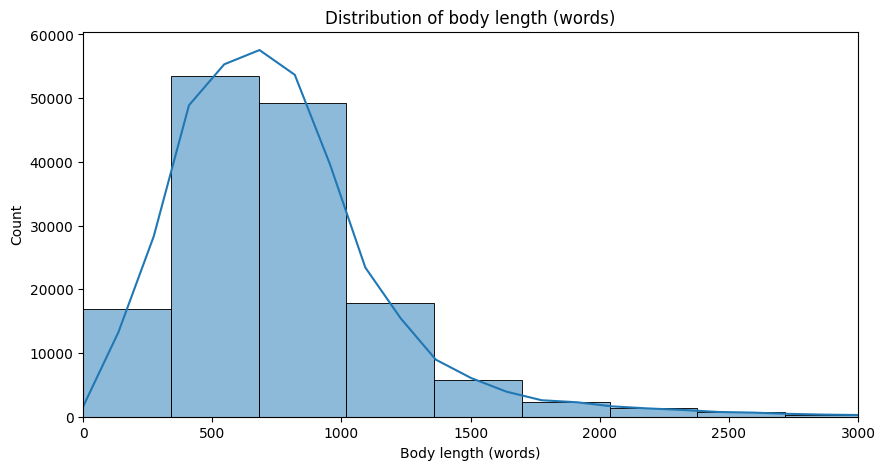

In [ ]:
# Visualize the distribution of article body length, focusing on the main mass of the corpus
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(articles_clean["body_len_words"], bins=80, kde=True)
plt.xlim(0, 3000)
plt.title("Distribution of body length (words)")
plt.xlabel("Body length (words)")
plt.ylabel("Count")
plt.show()

## **1.5 Temporal trends of selected terms**

This subsection presents a simple descriptive tool for examining how selected terms vary over time in the Guardian corpus. The terms can be easily modified in the code, making the approach reusable for other words or keyword pairs of interest. By tracking the proportion of articles containing a given word or phrase, it becomes possible to identify broad temporal patterns and compare the behaviour of different terms. Here, we first illustrate the method with the term **"pandemic"**, which provides a clear example of a strong time-specific shock, and then apply it to the project-related terms **"crime"** and **"immigration"** to compare their temporal profiles. Since the presence of a single word is only a rough proxy for article content, these plots should be interpreted as exploratory descriptive summaries rather than as substantive evidence on the underlying topics.

### 1.5.1 Example: "pandemic" over time

The following plot illustrates the method with the term **"pandemic"**, chosen as an example of a word associated with a clear external shock. It tracks the monthly proportion of articles containing the term, showing how its prevalence rises sharply in a specific historical phase and then declines over time.

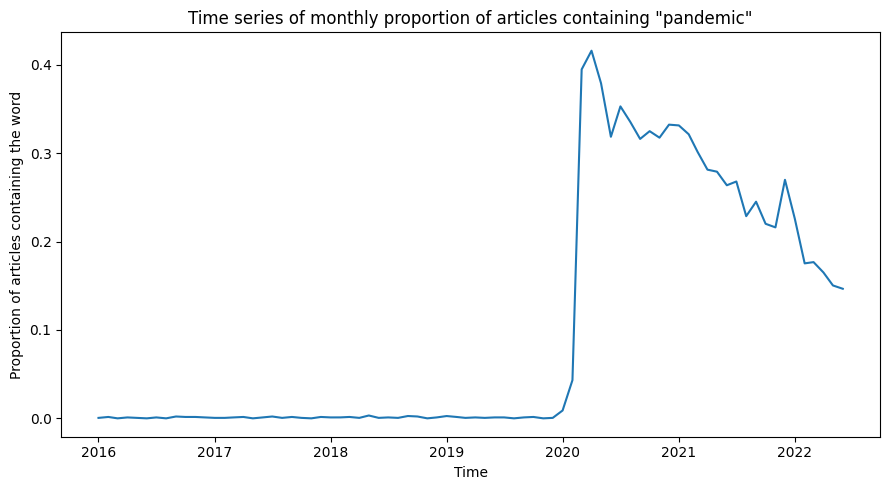

In [ ]:
import re
import matplotlib.pyplot as plt

df = articles_clean.copy()

# YOU CAN EVENTUALLY MODIFY IT WITH OTHER WORDS OF INTEREST
WORD = "pandemic"
##########################################################
WHOLE_WORD_ONLY = False

# 1. Build boolean mask: article contains the word
if WHOLE_WORD_ONLY:
    pat = rf"\b{re.escape(WORD)}\b"
    has_word = df["bodyContent"].str.contains(pat, case=False, na=False, regex=True)
else:
    has_word = df["bodyContent"].str.contains(WORD, case=False, na=False, regex=False)

# 2. Count matching articles (with word of interest) by month over time
monthly_counts = (df.loc[has_word].groupby("month_start").size())

# 3. Count total articles by month over time
monthly_totals = (df.groupby("month_start").size())

# 4. Compute monthly proportion
monthly_share = (monthly_counts / monthly_totals).fillna(0)

# 5. Plot time series
plt.figure(figsize=(9, 5))
plt.plot(monthly_share.index, monthly_share.values)

plt.xlabel("Time")
plt.ylabel("Proportion of articles containing the word")
plt.title(f'Time series of monthly proportion of articles containing "{WORD}"')

plt.tight_layout()
plt.show()

The term **"pandemic"** shows a very clear temporal pattern. Its monthly share is close to zero until early 2020, then increases abruptly with the onset of the COVID-19 crisis. At its peak, **more than 40% of the articles published in a month contain the word "pandemic"**, showing how strongly this topic dominated media coverage during that period. The proportion then gradually declines, although the term remains noticeably present well after the initial shock. This matches ineed the fact that The World Health Organization (WHO) declared the end of COVID-19 as a global health emergency only right after our corpus coverage, on May 5, 2023.

### 1.5.2 Comparison of "crime" and "immigration" over chronological time

The following plot compares the monthly proportion of articles containing the terms **"crime"** and **"immigration"** over the full chronological timeline of the corpus, allowing us to observe how their prevalence evolves across years. The code closely resembles the one of previous cell.

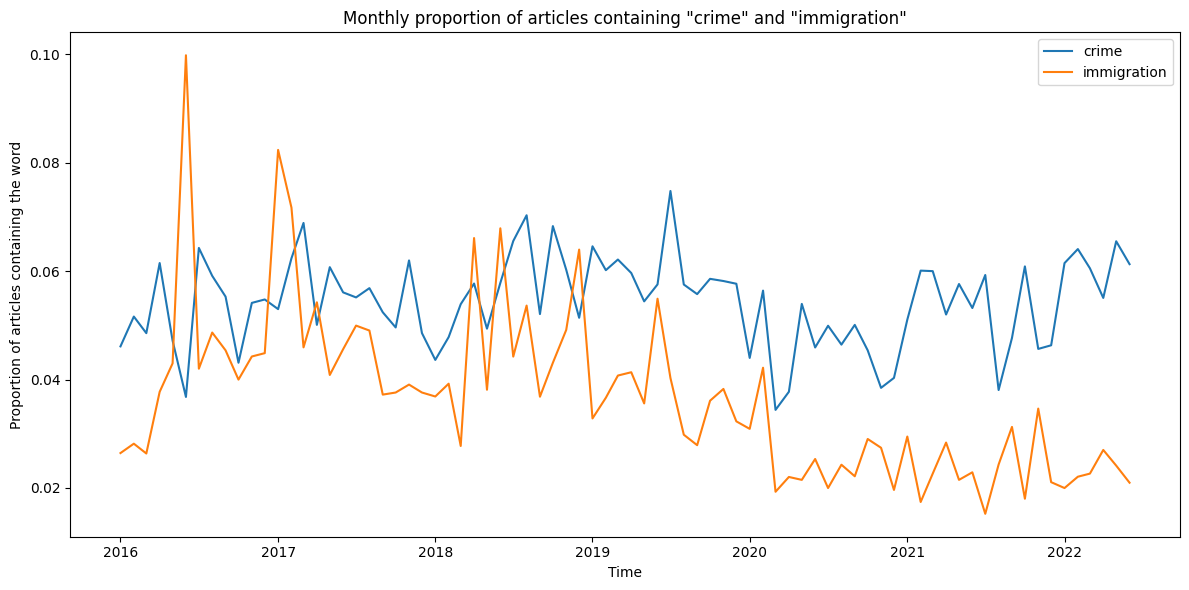

(Timestamp('2016-06-01 00:00:00'), 0.09984235417761429)

In [ ]:
# Monthly proportion of articles containing selected keywords
import re
import matplotlib.pyplot as plt

df = articles_clean.copy()

# THESE TWO WORDS COULD BE MODIFIED
WORDS = ["crime", "immigration"]
##########################################
WHOLE_WORD_ONLY = True

# 1. Count total articles by month over time
monthly_totals = df.groupby("month_start").size()

plt.figure(figsize=(12, 6))

# 2. Create empty dictionary to store monthly proportions
monthly_shares = {}

# 3. Compute monthly proportions over chronological time for each selected term
for word in WORDS:
    # 3.1 Build boolean mask: article contains the word
    if WHOLE_WORD_ONLY:
        pat = rf"\b{re.escape(word)}\b"
        has_word = df["bodyContent"].str.contains(pat, case=False, na=False, regex=True)
    else:
        has_word = df["bodyContent"].str.contains(word, case=False, na=False, regex=False)

    # 3.2 Count matching articles by month over time
    monthly_counts = df.loc[has_word].groupby("month_start").size()

    # 3.3 Compute monthly proportion
    monthly_share = (monthly_counts / monthly_totals).fillna(0)

    # 3.4 Store monthly proportion
    monthly_shares[word] = monthly_share

    # 3.5 Plot time series
    plt.plot(monthly_share.index, monthly_share.values, label=word)

plt.xlabel("Time")
plt.ylabel("Proportion of articles containing the word")
plt.title('Monthly proportion of articles containing "crime" and "immigration"')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Find the month with the highest proportion for immigration
monthly_shares["immigration"].idxmax(), monthly_shares["immigration"].max()

A few interesting takeaways emerge from this plot:
1. Despite many independent peaks of the two words, we can notice somehow a correlation from 2019 onwards, with almost parallel behaviours in 2019 and beginning of 2020.

2. There was a huge peak of **"immigration"** in June 2016. It arrived to appear in 10% of the monthly articles. This may be explained with the correspondence with the Brexit referendum (immigration was one of the central campaign topics).

3. A diminuishing trend of the word "immigration" can be seen, particularly in correspondence with the Covid pandemic. This probably reflects both a diminuishment in departures and, seen the immediate drop, a quick shift of the interest of the press from "immigration" to Covid-related news.

### 1.5.3 Seasonal lines by year for "crime" and "immigration"

To examine possible within-year seasonal structure, the following plots show monthly proportions separately for each year for the terms **"crime"** and **"immigration"**. In this case, the focus is on the pattern across calendar months within each individual year rather than on the full chronological timeline.

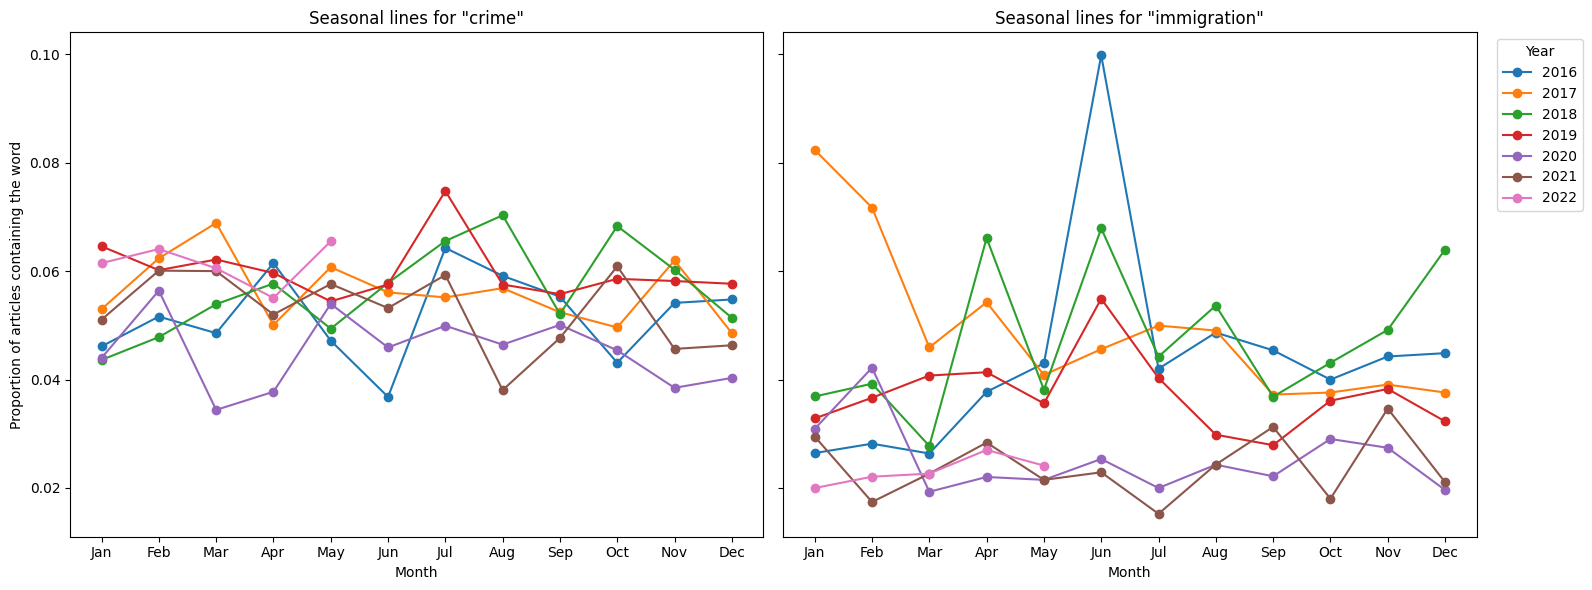

In [ ]:
# Seasonal monthly lines for selected keywords
import calendar
import re
import matplotlib.pyplot as plt

df = articles_clean.copy()

# THESE TWO WORDS COULD BE MODIFIED
WORDS = ["crime", "immigration"]
##########################################
WHOLE_WORD_ONLY = True

# 1. Count total articles for each year-month pair
total_counts = (df.groupby(["year", "month"]).size().reset_index(name="n_total"))

# 2. Remove final incomplete month
last_date = df["Date"].max()
total_counts = total_counts[~((total_counts["year"] == last_date.year) & (total_counts["month"] == last_date.month))].copy()

# 3. Compute monthly proportions and plot one panel per word
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, word in zip(axes, WORDS):
    # 3.1 Build boolean mask: article contains the word
    if WHOLE_WORD_ONLY:
        pat = rf"\b{re.escape(word)}\b"
        has_word = df["bodyContent"].str.contains(pat, case=False, na=False, regex=True)
    else:
        has_word = df["bodyContent"].str.contains(word, case=False, na=False, regex=False)

    # 3.2 Count matching articles by year-month pair
    word_counts = (df.loc[has_word].groupby(["year", "month"]).size().reset_index(name="n_with_word"))

    # 3.3 Merge total article counts and matching article counts
    monthly_props = total_counts.merge(word_counts, on=["year", "month"], how="left")

    # 3.4 Compute monthly proportion
    monthly_props["n_with_word"] = monthly_props["n_with_word"].fillna(0)
    monthly_props["proportion"] = monthly_props["n_with_word"] / monthly_props["n_total"]

    # 3.5 Plot seasonal lines, one line per year
    for year in sorted(monthly_props["year"].unique()):
        temp = monthly_props[monthly_props["year"] == year].sort_values("month")
        ax.plot(temp["month"], temp["proportion"], marker="o", label=str(year))

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)])
    ax.set_xlabel("Month")
    ax.set_title(f'Seasonal lines for "{word}"')

axes[0].set_ylabel("Proportion of articles containing the word")
axes[1].legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

A few interesting takeaways emerge from this plot:
1. The word "immigration" (forgetting about 2020, 2021 and 2022, for which we have already noticed in 1.5.2 a drop of the usage) tends to have usage peaks in the summer months (April, June and August). This matches the spike in physical migration arrivals during warmer weather (particularly in the Mediterranean).

2. The use of the word "crime " seems more stable across the year.

### 1.5.4 Distribution across years by month

The following boxplots summarize how the monthly proportions vary across years for each calendar month. Unlike the chronological plots above, this view pools observations by month of the year, making it easier to compare whether some months tend to show systematically higher or lower values across the corpus period.

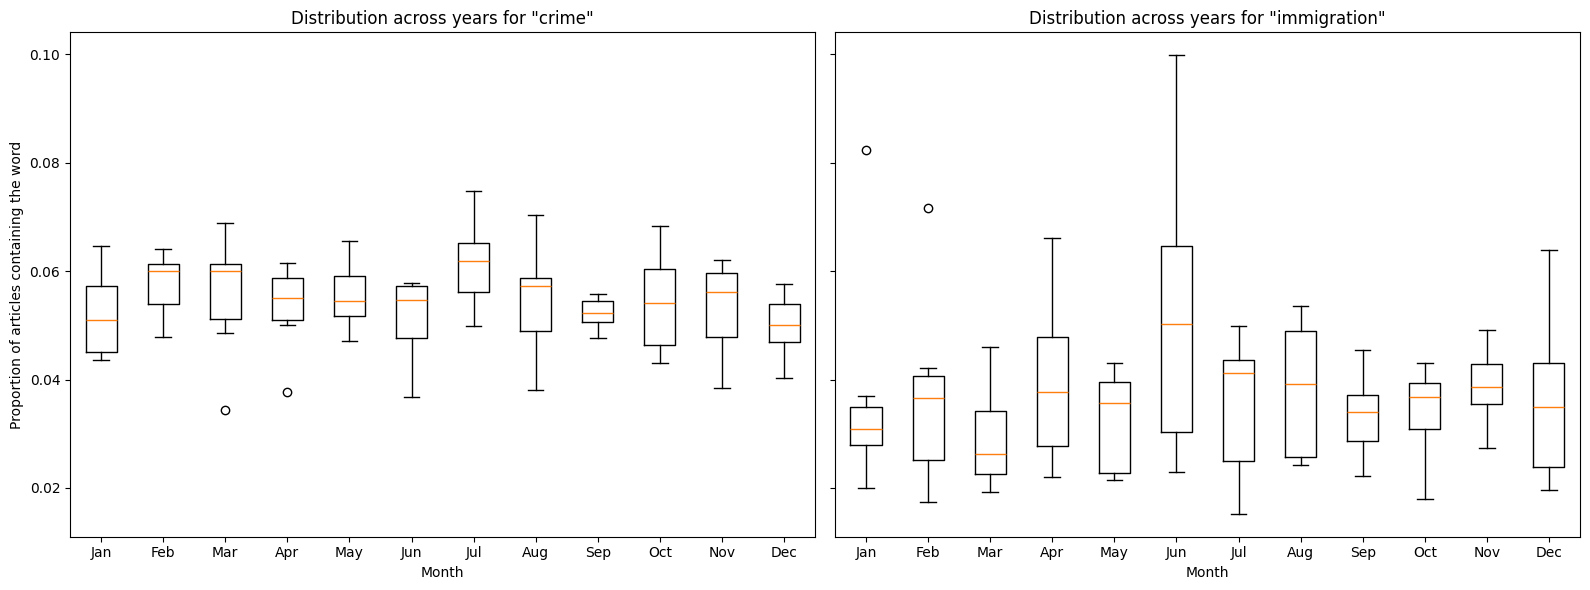

In [ ]:
# Monthly distribution across years for selected keywordsimport calendar
import calendar
import re
import matplotlib.pyplot as plt

df = articles_clean.copy()

# THESE TWO WORDS COULD BE MODIFIED
WORDS = ["crime", "immigration"]
##########################################
WHOLE_WORD_ONLY = True

# 1. Count total articles for each year-month pair
total_counts = (df.groupby(["year", "month"]).size().reset_index(name="n_total"))

# 2. Remove final incomplete month
last_date = df["Date"].max()
total_counts = total_counts[~((total_counts["year"] == last_date.year) & (total_counts["month"] == last_date.month))].copy()

# 3. Compute monthly proportions and plot one boxplot panel per word
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, word in zip(axes, WORDS):
    # 3.1 Build boolean mask: article contains the word
    if WHOLE_WORD_ONLY:
        pat = rf"\b{re.escape(word)}\b"
        has_word = df["bodyContent"].str.contains(pat, case=False, na=False, regex=True)
    else:
        has_word = df["bodyContent"].str.contains(word, case=False, na=False, regex=False)

    # 3.2 Count matching articles by year-month pair
    word_counts = (df.loc[has_word].groupby(["year", "month"]).size().reset_index(name="n_with_word"))

    # 3.3 Merge total article counts and matching article counts
    monthly_props = total_counts.merge(word_counts, on=["year", "month"], how="left")

    # 3.4 Compute monthly proportion
    monthly_props["n_with_word"] = monthly_props["n_with_word"].fillna(0)
    monthly_props["proportion"] = monthly_props["n_with_word"] / monthly_props["n_total"]

    # 3.5 Collect monthly proportions across years
    boxplot_data = [
        monthly_props.loc[monthly_props["month"] == m, "proportion"].values
        for m in range(1, 13)
    ]

    # 3.6 Plot distribution across years for each month
    ax.boxplot(boxplot_data, tick_labels=[calendar.month_abbr[m] for m in range(1, 13)])
    ax.set_xlabel("Month")
    ax.set_title(f'Distribution across years for "{word}"')

axes[0].set_ylabel("Proportion of articles containing the word")
plt.tight_layout()
plt.show()

Overall, these plots provide a descriptive view of how selected terms vary over time in the corpus. They are useful for visualizing broad differences in prominence, temporal shocks, and possible seasonal variation, but they should be interpreted cautiously, since single-word occurrence is only a limited proxy for the broader topics addressed in the articles.

## **1.6 Focus on Opinion articles**

In [ ]:
!python -m spacy download en_core_web_sm
!pip install -q gensim

In [ ]:
# 1) Select Opinion articles
subset = articles_clean[articles_clean["sectionName"] == "Opinion"].copy()
subset = subset[subset["bodyContent"].astype(str).str.len() > 50].copy()

# Optional quick sample for faster runs
sample_size = min(2000, len(subset))
subset_quick = subset.sample(n=sample_size, random_state=42).copy()

print("Documents in Opinion subset:", len(subset))
print("Documents used for model selection / LDA:", len(subset_quick))

# 2) Clean text + lemmatize
import re
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def clean_and_lemmatize(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)         # keep letters/spaces
    text = re.sub(r"\s+", " ", text).strip()      # extra spaces

    doc = nlp(text)

    lemmas = [
        token.lemma_
        for token in doc
        if token.is_alpha and len(token) > 2
    ]

    return " ".join(lemmas)

subset_quick["clean_text"] = subset_quick["bodyContent"].astype(str).apply(clean_and_lemmatize)
subset_quick = subset_quick[subset_quick["clean_text"].str.len() > 20].copy()

print("Documents after cleaning:", len(subset_quick))

# 3) Vectorize text
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

custom_stopwords = ENGLISH_STOP_WORDS.union({

    # journalism
    "said", "says", "told", "mr", "mrs", "ms",

    # generic high-frequency low-information words
    "people", "time", "year", "years", "day", "days", "thing", "things", "way", "ways",
    "good", "bad", "much", "many", "lot", "lots", "even", "still", "well", "really",

    # weak verbs
    "make", "made", "get", "got", "go", "going", "take", "took", "come", "came",
    "look", "see", "know", "think", "want", "need", "say",

    # opinion-writing filler
    "opinion", "article", "writer", "story", "view", "point", "issue",

    # dataset-specific words
    "guardian", "news",

    # vague structural words
    "new", "now", "back", "first", "last", "another",

    # conversational / stylistic
    "like", "just", "also", "could", "would", "should",

    # generic human references
    "man", "men", "woman", "women", "person", "persons",
})

vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),
    min_df=50,
    max_df=0.4,
    ngram_range=(1, 1),
    token_pattern=r"(?u)\b[a-z]{3,30}\b"
)

X = vectorizer.fit_transform(subset_quick["clean_text"])
feature_names = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(feature_names))
print("Document-term matrix shape:", X.shape)

# 4) Prepare tokenized texts aligned to the vectorizer vocabulary
vocab_set = set(feature_names)

tokenized_texts = [
    [tok for tok in doc.split() if tok in vocab_set]
    for doc in subset_quick["clean_text"]
]

# Remove documents that became empty after vocabulary filtering
non_empty_mask = [len(tokens) > 0 for tokens in tokenized_texts]

subset_quick = subset_quick.loc[non_empty_mask].reset_index(drop=True)
tokenized_texts = [tokens for tokens in tokenized_texts if len(tokens) > 0]

# Rebuild X on the filtered subset to keep everything aligned
X = vectorizer.fit_transform(subset_quick["clean_text"])
feature_names = vectorizer.get_feature_names_out()
vocab_set = set(feature_names)

tokenized_texts = [
    [tok for tok in doc.split() if tok in vocab_set]
    for doc in subset_quick["clean_text"]
]

print("Documents after removing empty tokenized texts:", len(subset_quick))
print("Final vocabulary size:", len(feature_names))
print("Final document-term matrix shape:", X.shape)

# 5) Build Gensim dictionary/corpus for coherence metrics
from gensim import corpora
from gensim.models import CoherenceModel

dictionary = corpora.Dictionary(tokenized_texts)
corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

# 6) Helpers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation

def get_topic_word_lists(lda_model, feature_names, top_n_words=10):
    topics = []
    for topic in lda_model.components_:
        top_ids = topic.argsort()[-top_n_words:][::-1]
        topics.append([feature_names[i] for i in top_ids])
    return topics

def topic_diversity(topics):
    total_words = sum(len(topic) for topic in topics)
    unique_words = len(set(word for topic in topics for word in topic))
    return unique_words / total_words if total_words > 0 else 0.0

def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_ids = topic.argsort()[-n_top_words:][::-1]
        top_terms = [feature_names[i] for i in top_ids]
        print(f"Topic {topic_idx}: {', '.join(top_terms)}")

# 7) Try different numbers of topics and compute metrics
topic_range = [5,7,9]
top_n_words = 10

results = []

for k in topic_range:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method="batch"
    )

    doc_topic_k = lda_k.fit_transform(X)
    topics_k = get_topic_word_lists(lda_k, feature_names, top_n_words=top_n_words)

    cv_score = CoherenceModel(
        topics=topics_k,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence="c_v",
        processes=1
    ).get_coherence()

    cnpmi_score = CoherenceModel(
        topics=topics_k,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence="c_npmi",
        processes=1
    ).get_coherence()

    umass_score = CoherenceModel(
        topics=topics_k,
        corpus=corpus,
        dictionary=dictionary,
        coherence="u_mass",
        processes=1
    ).get_coherence()

    diversity_score = topic_diversity(topics_k)

    results.append({
        "n_topics": k,
        "c_v": cv_score,
        "c_npmi": cnpmi_score,
        "u_mass": umass_score,
        "topic_diversity": diversity_score
    })

metrics_df = pd.DataFrame(results).sort_values("n_topics").reset_index(drop=True)
print("\n=== Topic-number selection metrics ===")
display(metrics_df.round(4))

# 8) Optional: plot metrics vs number of topics
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(metrics_df["n_topics"], metrics_df["c_v"], marker="o")
axes[0, 0].set_title("C_v")
axes[0, 0].set_xlabel("Number of topics")
axes[0, 0].set_ylabel("Score")

axes[0, 1].plot(metrics_df["n_topics"], metrics_df["c_npmi"], marker="o")
axes[0, 1].set_title("C_npmi")
axes[0, 1].set_xlabel("Number of topics")
axes[0, 1].set_ylabel("Score")

axes[1, 0].plot(metrics_df["n_topics"], metrics_df["u_mass"], marker="o")
axes[1, 0].set_title("UMass")
axes[1, 0].set_xlabel("Number of topics")
axes[1, 0].set_ylabel("Score")

axes[1, 1].plot(metrics_df["n_topics"], metrics_df["topic_diversity"], marker="o")
axes[1, 1].set_title("Topic diversity")
axes[1, 1].set_xlabel("Number of topics")
axes[1, 1].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 9) AFTER INSPECTING THE TABLE, CHOOSE best_k MANUALLY
# ============================================================
best_k = 7   # <-- replace after inspecting metrics

lda = LatentDirichletAllocation(
    n_components=best_k,
    random_state=42,
    learning_method="batch"
)

doc_topic = lda.fit_transform(X)

print(f"\n=== Top words for best_k = {best_k} ===")
print_top_words(lda, feature_names, n_top_words=10)

In [ ]:
# Check if topic 5 garbage or not

topic_id = 5
subset_with_topics = pd.concat(
    [subset_quick.reset_index(drop=True),
     pd.DataFrame(doc_topic, columns=[f"topic_{i}" for i in range(doc_topic.shape[1])])],
    axis=1
)

top_docs = subset_with_topics.sort_values(f"topic_{topic_id}", ascending=False)

for i, row in top_docs.head(10).iterrows():
    print(f"\n--- Document {i} | topic weight = {row[f'topic_{topic_id}']:.3f} ---")
    print(row["webTitle"])
    print(row["bodyContent"][:800])

In [ ]:
# ============================================================
# 10) Topic evolution over time with the chosen best_k
# ============================================================

doc_topic_df = pd.DataFrame(
    doc_topic,
    columns=[f"topic_{i}" for i in range(doc_topic.shape[1])]
)

subset_with_topics = pd.concat(
    [subset_quick.reset_index(drop=True), doc_topic_df],
    axis=1
)

topic_cols = [f"topic_{i}" for i in range(doc_topic.shape[1])]

topic_time = (
    subset_with_topics
    .groupby("month_start")[topic_cols]
    .mean()
    .sort_index()
)

plt.figure(figsize=(14, 7))

for col in topic_time.columns:
    plt.plot(topic_time.index, topic_time[col], label=col)

plt.xlabel("Time")
plt.ylabel("Average topic proportion")
plt.title('Topic evolution over time in "Opinion" articles')
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Topic evolution over time
import pandas as pd
import matplotlib.pyplot as plt

# 1) Build topic-probability DataFrame
doc_topic_df = pd.DataFrame(
    doc_topic,
    columns=[f"topic_{i}" for i in range(doc_topic.shape[1])]
)

# 2) Attach time (ensure alignment)
subset_with_topics = pd.concat(
    [subset_quick.reset_index(drop=True), doc_topic_df],
    axis=1
)

# 3) Aggregate by month (average topic proportions)
topic_cols = [f"topic_{i}" for i in range(doc_topic.shape[1])]

topic_time = (
    subset_with_topics
    .groupby("month_start")[topic_cols]
    .mean()
    .sort_index()
)

# 4) Plot
plt.figure(figsize=(14, 7))

for col in topic_time.columns:
    plt.plot(topic_time.index, topic_time[col], label=col)

plt.xlabel("Time")
plt.ylabel("Average topic proportion")
plt.title("""Topic evolution over time in "Opinion" articles""")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

________________________________________________________________________________________________

In [ ]:
# Map sectionName values into broader groups (Macrosection) to reduce category sparsity.
# Sections not explicitly mapped are assigned to "Other".
mapping = {
    'Politics': 'Politics',
    'World news': 'Politics',
    'US news': 'Politics',
    'UK news': 'Politics',
    'Global development': 'Politics',
    'Law': 'Politics',

    'Business': 'Business',
    'Money': 'Business',
    'Media': 'Business',

    'Sport': 'Sport',
    'Football': 'Sport',

    'Film': 'Culture',
    'Music': 'Culture',
    'Books': 'Culture',
    'Culture': 'Culture',
    'Stage': 'Culture',
    'Television & radio': 'Culture',
    'Art and design': 'Culture',

    'Life and style': 'Lifestyle',
    'Food': 'Lifestyle',
    'Fashion': 'Lifestyle',
    'Travel': 'Lifestyle',

    'Science': 'Science',
    'Technology': 'Science',
    'Environment': 'Science',

    'Society': 'Society',
    'Education': 'Society',
    'Cities': 'Society',

    'Opinion': 'Opinion'
}

articles_clean["Macrosection"] = articles_clean["sectionName"].map(mapping).fillna("Other")

In [ ]:
# Analyze how section composition changes over time using monthly section shares
monthly_topic_counts = (
    articles_clean
    .groupby(["month_start", "section_group"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

monthly_topic_shares = monthly_topic_counts.div(monthly_topic_counts.sum(axis=1), axis=0)

ax = monthly_topic_shares.plot.area(figsize=(13, 6), alpha=0.85)
ax.set_title("Section distribution over time (monthly shares)")
ax.set_xlabel("Month")
ax.set_ylabel("Share of monthly articles")
ax.legend(title="Section group", bbox_to_anchor=(1.02, 1), loc="upper left")

# **2. PRE-PROCESSING: LEMMATIZATION** (performed externally on HPC)

At this stage, the preprocessing pipeline continues outside the notebook.

After the initial cleaning steps, the dataframe `articles_clean` was exported to CSV with `index=False`, so that the saved file would not retain the intermediate dataframe indexing generated during the cleaning process. The exact export command used was:

```python
articles_clean.to_csv("/content/drive/MyDrive/NLP_project/hpc_lemmatization/articles_clean.csv", index=False)
```

This exported file was then processed on the HPC environment in order to perform lemmatization on the full corpus.

The external HPC step was executed using the following files:

- `lemmatize_guardian.py`: performs corpus lemmatization
- `lemmatize_guardian.sh`: launches that script on the HPC system

They use the library spaCy and the spaCy

The output of that step is the file:

- `articles_clean_with_both_lemma_columns.parquet`


It contains two extra columns:
1. **body_sent_lemma_tokens**: one list for each article, containing lists of lemmatized tokens, one for each sentence
2. **bodyContent_lemma**: contains the article text as a sequence of lemmas

To keep the notebook clear and runnable, the HPC job is **not re-executed here**. Instead, the notebook resumes from the parquet file produced by that external step, which is loaded below.

In [ ]:
# Load the dataset produced by the external HPC lemmatization step
import pandas as pd
articles_clean = pd.read_parquet("/content/drive/MyDrive/NLP_project/hpc_lemmatization/articles_clean_with_both_lemma_columns.parquet")
articles_clean.head()

,bodyContent,Date,webTitle,sectionName,month_start,year_month,year,month,body_sent_lemma_tokens,bodyContent_lemma
0,As polling day looms and the cameras turn only...,2016-01-31,Iowa underdogs put on brave faces despite all ...,US news,2016-01-01,2016-01,2016,1,"[['as', 'polling', 'day', 'loom', 'and', 'the'...",as polling day loom and the camera turn only t...
1,"In Des Moines on Sunday, the Guardian was give...",2016-01-31,Iowa caucus: hologram eagle and Jesus star on ...,US news,2016-01-01,2016-01,2016,1,"[['in', 'des', 'moines', 'on', 'sunday', 'the'...",in des moines on sunday the guardian be give a...
2,A British pilot who was shot dead by an elepha...,2016-01-31,British pilot in Tanzania 'manoeuvred ​to save...,World news,2016-01-01,2016-01,2016,1,"[['a', 'british', 'pilot', 'who', 'be', 'shoot...",a british pilot who be shoot dead by an elepha...
3,USA took a step toward shaking off the ghosts ...,2016-01-31,USA 3-2 Iceland | International friendly match...,Football,2016-01-01,2016-01,2016,1,"[['usa', 'take', 'a', 'step', 'toward', 'shake...",usa take a step toward shake off the ghost of ...
4,"The clean-shaven, spectacle free and suspiciou...",2016-01-31,Reinvigorated Paul Lambert reflects after impr...,Football,2016-01-01,2016-01,2016,1,"[['the', 'clean', 'shaven', 'spectacle', 'free...",the clean shaven spectacle free and suspicious...


**Optional consistency check:**

the following cell can be run only if Section 1 has already been executed in the current session and the dataframe `articles_clean` is available in memory. It verifies that the externally lemmatized checkpoint aligns with the cleaned dataframe built earlier in the notebook.

In [ ]:
# # Verify that the externally lemmatized file matches the cleaned dataframe built earlier
# print("articles_clean shape:", articles_clean.shape)
# print("lemmatized file shape:", articles_clean_lem.shape)

# assert len(articles_clean) == len(articles_clean_lem)

# # Compare title and section directly
# for col in ["webTitle", "sectionName"]:
#     assert articles_clean[col].reset_index(drop=True).equals(
#         articles_clean_lem[col].reset_index(drop=True)
#     ), f"Mismatch found in column: {col}"

# # Compare Date after standardizing format
# date_clean = pd.to_datetime(articles_clean["Date"], errors="coerce").dt.strftime("%Y-%m-%d")
# date_lem = pd.to_datetime(articles_clean_lem["Date"], errors="coerce").dt.strftime("%Y-%m-%d")

# assert date_clean.reset_index(drop=True).equals(
#     date_lem.reset_index(drop=True)
# ), "Mismatch found in column: Date"

# print("Alignment check passed.")

# **3. CLASSIFICATION**


In this section, we build the article-level classification pipeline in four main steps, in the following order:

1. We obtain an initial topic signal through **zero-shot classification** using **facebook/bart-large-mnli** [section 3.1]
2. We construct **lexicon-based scores**, computing the ratio of words belonging to a certain semantic field over the length of the article [section 3.2]
3. We compute **embedding-based similarity scores** using manually selected seed articles [section 3.3]
4. We run a logistic regression using as regressors the scores obtained in previous steps [section 3.4 and 3.5]

## **3.1 Zero-shot classification**

We begin with a zero-shot approach to obtain an initial topic signal without training a supervised classifier. We chose zero-shot classification because:
1. We dont have a large manually labelled training set
2. It uses the article as premise and "This article is about immmigration" as hypothesis.
3. NLI can be used as universal classification task

(Laurer, M., van Atteveldt, W., Casas, A., & Welbers, K. (2024). Building Efficient Universal Classifiers with Natural Language Inference. arXiv:2312.17543. https://doi.org/10.48550/arXiv.2312.17543)

---

We use a pretrained natural language inference model, namely **"MoritzLaurer/ModernBERT-large-zeroshot-v2.0"**.
(https://huggingface.co/MoritzLaurer/ModernBERT-large-zeroshot-v2.0)

We chose it for three reasons:
1. It is a Hugging Face model explicitly designed for zero-shot classification
2. It is based on ModernBERT, a newer encoder architecture trained with 8192-token sequence length, way more than BERT, RoBERTA and similar (usually 512 tokens). This makes ModernBERT more appropriate for newspaper articles
3. It is efficient for large-scale inference: the ModernBERT paper emphasizes speed and memory efficiency, which matters because you apply the classifier to many Guardian articles on HPC (https://arxiv.org/abs/2412.13663). For example it is stated



Each article is scored with respect to the project-related labels **crime** and **immigration**.

### **3.1.1 Sample run**

 We first test the method on a small sample of articles to verify that the scores are meaningful and reasonable.

In [ ]:
# Install and import the libraries required for zero-shot classification
!pip install -q transformers torch

import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from tqdm.auto import tqdm

In [ ]:
# Use GPU if available, otherwise use CPU
device = 0 if torch.cuda.is_available() else -1

# Initialize the zero-shot classification pipeline
classifier = pipeline(
    "zero-shot-classification",
    # model="facebook/bart-large-mnli",
    model="MoritzLaurer/ModernBERT-large-zeroshot-v2.0",
    device=device
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/792M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/174 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

For each article, we concatenate the title with the beginning of the body text and compute zero-shot scores for the labels **crime** and **immigration**.

In [ ]:
# Draw a small sample and create a text field combining title and body
sample_df = articles_clean.sample(5, random_state=40).copy()
sample_df["zs_text"] = (
    sample_df["webTitle"].fillna("") + ". " +
    sample_df["bodyContent"].fillna("").str.slice(0, 600)
)

# Initialize two lists that will be filled with ZS scores
crime_scores = []
immigration_scores = []
batch_size = 2

# Take the "zs_text" column and transform it in a list
texts = sample_df["zs_text"].tolist()

# Score the sampled articles in batches
# Loop avoer texts in batches. "tqdm" is being used to display progress bar. The step 2 is the batch size.
for i in tqdm(range(0, len(texts), batch_size)):
    # Take one batch of text
    batch = texts[i:i + batch_size]

    # Run zero-shot classification. Obtain a list of dictionaries.
    results = classifier(
        batch,
        candidate_labels=["crime", "immigration"],
        hypothesis_template= "This article is about {}",
        multi_label=True
    )

    # For each article/dictionary in results, extract the scores and append them to the pre initalized lists
    for result in results:
        score_map = dict(zip(result["labels"], result["scores"]))
        crime_scores.append(score_map.get("crime", 0.0))
        immigration_scores.append(score_map.get("immigration", 0.0))

# Add the lists crime_scores and immigration_scores to the DataFrame
sample_df["zs_crime_score"] = crime_scores
sample_df["zs_immigration_score"] = immigration_scores

  0%|          | 0/3 [00:00<?, ?it/s]

I inspect manually the articles randomly sampled and their score. I can read only their titles or go in details reading their bodyContent. I realise the scores are accurate and properly reflects the content of the article. Indeed there was no space for much doubt, as "facebook/bart-large-mnli" is one of the most widely used and referenced models for zero shot classification tasks.

In [ ]:
# Inspect titles
pd.set_option("display.max_colwidth", None)
display(sample_df[["webTitle", "zs_crime_score", "zs_immigration_score"]])

,webTitle,zs_crime_score,zs_immigration_score
105608,Hurricane Laura levels homes and causes deaths as one of US's strongest ever storms,0.000028,0.000011
84435,Serotonin by Michel Houellebecq review – Alan Partridge in Gilead,0.000032,0.000911
20146,Premiership round-up: Bath’s defeat by Harlequins sends Wasps second,0.000007,0.000017
54874,Chess: Nigel Short launches campaign to secure role as Fide president,0.000099,0.000017
47133,John Worboys' release put on hold after victims launch legal challenge,0.994531,0.000171


In [ ]:
# Inspect whole article
display(sample_df[["bodyContent", "zs_crime_score", "zs_immigration_score"]])
pd.reset_option("display.max_colwidth")

bodyContent  \
105608                                                                                                                                          Remnants of Hurricane Laura unleashed heavy rain and twisters hundreds of miles inland from a path of death and mangled buildings along the Gulf coast, and forecasters warn of new dangers as the tropical weather blows toward the eastern seaboard this weekend.\nMore than 600,000 homes and businesses were without power in Louisiana, Texas and Arkansas in the category 4 storm’s wake, according to poweroutage.us, which tracks utility reports. One of the strongest hurricanes ever to strike the United States, Laura was blamed for 14 deaths as it barreled across Louisiana and parts of Texas. Aerial pictures showed whole neighborhoods leveled across parts of the coast, huge expanses of flood water and many buildings with shredded roofs and blasted-out windows. But a sense of relief prevailed that Laura was not the annihilating menace forecasters had feared, though a full assessment of the true extent of all the damage could take days. The death toll rose to 11 after authorities reported that a Texas man was killed when the category 4 hurricane sent a tree crashing into his home near the Louisiana border. Four other people, all in the same residence, died from carbon monoxide poisoning from a generator. Six deaths were reported Thursday in Louisiana, mostly from falling trees. The threat of tornadoes was forecast to redevelop on Friday after a reported tornado tore through a church and homes in north-eastern Arkansas. Trees were down and power was out where what was left of the once fearsome category 4 hurricane spun over the state. The storm crashed ashore in low-lying Louisiana and clobbered Lake Charles, an industrial and casino city of 80,000 people. On Broad Street, many buildings had partially collapsed. Windows were blown out, awnings ripped away and trees split in eerily misshapen ways. A floating casino came unmoored and hit a bridge, and small planes were thrown atop each other at the airport. A television station’s tower toppled. A Confederate statue in front of a courthouse that local officials had voted to keep in place just days earlier was knocked down by Laura. “It looks like 1,000 tornadoes went through here. It’s just destruction everywhere,” said Brett Geymann, who rode out the storm with three relatives in Moss Bluff, near Lake Charles. He described a roar like a jet engine as Laura passed over his house around 2am. “There are houses that are totally gone,” he said.\nAs the extent of the damage in Lake Charles came into focus, a massive plume of smoke visible for miles began rising from a chemical plant. Police said the leak was at a facility run by Biolab, which manufactures chemicals used in household cleaners and chlorine powder for pools. Nearby residents were told to close their doors and windows, and the fire smoldered into the night. Laura weakened to a tropical depression late on Thursday, but more tornadoes and up to 5in (13cm) of rain were expected across the Tennessee Valley region before the system closed in on the mid-Atlantic states by Saturday. “It is clear that we did not sustain and suffer the absolute, catastrophic damage that we thought was likely,” said Louisiana’s governor, John Bel Edwards. “But we have sustained a tremendous amount of damage.” He called Laura the most powerful hurricane to strike Louisiana, meaning it surpassed even Katrina, which was a category 3 storm when it hit in 2005. The hurricane’s top wind speed of 150mph (241km/h) put it among the strongest systems on record in the US. It was unclear when the journey home would be complete for more than 580,000 coastal residents who evacuated under the shadow of a coronavirus pandemic. Although not everyone fled, officials credited those who did leave with minimizing the loss of life.\nA lower-than-expected storm surge also helped save lives. Edwards said ocean water rose as mu

### **3.1.2 Full-corpus run**

After checking that the ZS classification gives appropriate results, in line with our definition of "criminality" and "immigration" articles, the full zero-shot inference step was executed externally on the HPC environment using the following files:

- `zero_shot_guardian.py`: loads the prepared article file, builds the zero-shot input text by concatenating `webTitle` and the first 600 characters of `bodyContent`, applies the classifier to the full corpus, and stores the resulting scores
- `run_zero_shot.sh`: launches that script on the HPC system with GPU support

The classifier was run on all articles using the same project-relevant labels tested in the notebook:

- `crime`
- `immigration`

The output of that step is the file:

- `articles_clean_with_lemmas_and_zs_scores.parquet`

It contains the previously computed lemmas columns, plus the ZS scores in columns **zs_crime_score** and **zs_immmigration_score**.

In [ ]:
# Load the dataset produced by the external HPC zero-shot classification step
# This file contains the previously computed lexicon-based variables together with the zero-shot scores
import pandas as pd

articles_clean = pd.read_parquet("/content/drive/MyDrive/NLP_project/hpc_zero_shot_classification/articles_clean_with_lemmas_and_zs_scores.parquet")
articles_clean.head(2)

,bodyContent,Date,webTitle,sectionName,month_start,year_month,year,month,body_sent_lemma_tokens,bodyContent_lemma,zs_crime_score,zs_immigration_score
0,As polling day looms and the cameras turn only...,2016-01-31,Iowa underdogs put on brave faces despite all ...,US news,2016-01-01,2016-01,2016,1,"[['as', 'polling', 'day', 'loom', 'and', 'the'...",as polling day loom and the camera turn only t...,0.000017,0.000496
1,"In Des Moines on Sunday, the Guardian was give...",2016-01-31,Iowa caucus: hologram eagle and Jesus star on ...,US news,2016-01-01,2016-01,2016,1,"[['in', 'des', 'moines', 'on', 'sunday', 'the'...",in des moines on sunday the guardian be give a...,0.000007,0.000038


## **3.2 Lexicon scores**

As a complementary approach to zero-shot classification, we also compute lexicon-based scores. Lexicon methods are useful because they provide a transparent and interpretable way to measure the presence of predefined concepts in a document. In our case, the article-level score is the ratio of relevant terms in the lemmatized text over total number of lemmas. In other words, it measures how strongly each article contains vocabulary related to crime or immigration.

We implement it in 3 phases:
1. In **section 3.2.1** we start from a small manually defined seed lexicon
2. In **section 3.2.2** we expand it by inspecting high-scoring articles and selecting words that catch our attention and are topic-related
3. In **section 3.2.3** we expand it using Word2Vec-based word embeddings trained on the Guardian corpus.

Similar approaches have been used in previous work:
- Hamilton et al. (2016) induce domain-specific lexicons from small seed sets using word embeddings

    ([Inducing Domain-Specific Sentiment Lexicons from Unlabeled Corpora](https://aclanthology.org/D16-1057/) (Hamilton et al., EMNLP 2016)


- Garten et al. (2018) discuss how dictionary methods can be combined with distributional representations. This makes the lexicon more adapted to our specific corpus than a purely hand-written list.

    (Garten, J., Hoover, J., Johnson, K.M. et al. Dictionaries and distributions: Combining expert knowledge and large scale textual data content analysis. Behav Res 50, 344–361 (2018). https://doi.org/10.3758/s13428-017-0875-9)

In the middle, in **section 3.2.2** we extract a samle of 60 articles to manually label, that are gonna be used in **3.3** to select the seed articles used as benchmarcks for articles embeddings, and in **3.5** for the training and test sets of the logistic regression.

### 3.2.1 Preliminary lexicon scores

In [ ]:
# Define the initial keyword lexicons for the two target topics
immigration_words = set(["immigration", "immigrant", "migration", "migrant", "asylum", "refugee", "deportation", "deport", "border", "visa", "citizenship", "nationality", "naturalisation", "integration"])
crime_words = set(["crime", "criminal", "offence", "arrest", "police", "prosecution", "court", "prison", "violence", "murder", "assault", "robbery", "theft", "fraud", "sentence"])

In [ ]:
# Check if any value in bodyContent_lemma is NaN and fill them
print(articles_clean["bodyContent_lemma"].isna().sum())
articles_clean["bodyContent_lemma"] = articles_clean["bodyContent_lemma"].fillna("").astype(str)

0


In [ ]:
# Compute article length and lexicon counts in one pass over the lemmatized body text
def compute_lexicon_counts(text):
    tokens = str(text).split()
    n_tokens = len(tokens)
    crime_count = sum(token in crime_words for token in tokens)
    immigration_count = sum(token in immigration_words for token in tokens)
    return pd.Series([n_tokens, crime_count, immigration_count])

articles_clean[["n_tokens", "crime_count", "immigration_count"]] = articles_clean["bodyContent_lemma"].apply(compute_lexicon_counts)

# Normalize the counts by article length to obtain comparable topic scores
articles_clean["lex_crime_score"] = articles_clean["crime_count"] / articles_clean["n_tokens"].replace(0, 1)
articles_clean["lex_immigration_score"] = articles_clean["immigration_count"] / articles_clean["n_tokens"].replace(0, 1)

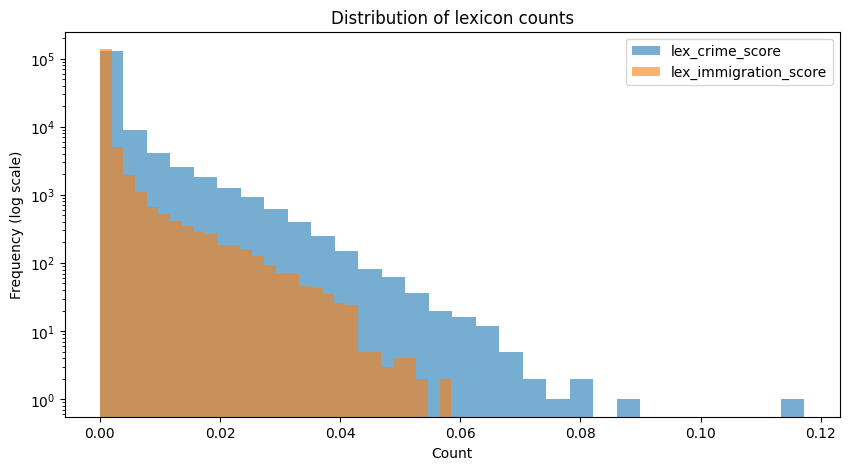

In [ ]:
# Plot the distributions of the initial normalized lexicon scores on a log-scaled frequency axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(articles_clean["lex_crime_score"].dropna(), bins=30, alpha=0.6, label="lex_crime_score")
plt.hist(articles_clean["lex_immigration_score"].dropna(), bins=30, alpha=0.6, label="lex_immigration_score")
plt.yscale("log")
plt.title("Distribution of lexicon scores")
plt.xlabel("Count")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.show()

### 3.2.2 First expansion of lexicons

In [ ]:
# I inspect top criminal articles
top_crime = articles_clean.sort_values("lex_crime_score", ascending=False).head(10)

for _, row in top_crime.iterrows():
    print("=" * 120)
    print(row["webTitle"])
    print(row["bodyContent_lemma"])
    print("\n")

The 19 black radicals who are still in prison after four decades
mumia abu jamal aka wesley cook former black panther age 64 incarcerate since 1981 convict of murder of philadelphia police officer daniel faulkner sentence life without parole current prison sci mahanoy pennsylvania delbert orr africa move organisation age 72 incarcerate since 1978 convict of third degree murder of police officer james ramp during philadelphia siege sentence 30 year to life current prison sci dallas pennsylvania eddie goodman africa move organisation age 68 incarcerate since 1978 convict of third degree murder of police officer james ramp during philadelphia siege sentence 30 year to life current prison sci mahanoy pennsylvania janet holloway africa move organisation age 67 incarcerate since 1978 convict of third degree murder of police officer james ramp during philadelphia siege sentence 30 year to life current prison sci cambridge springs pennsylvania janine phillips africa move organisation age 62 in

In [ ]:
#Based on articles read I expand the lexicon used
lexicon_crime = {
    "crime", "criminal", "offence", "arrest", "police", "prosecution","court", "prison", "violence", "murder", "assault", "robbery",
    "theft", "fraud", "sentence", "incarcerate", "convict", "burglary", "stalking", "harassment", "guilty", "conviction", "perpetrator", "detention"
}

crime_phrases = {
    "without parole", "offence record", "knife crime", "violent crime", "gun crime", "pepper spray", "criminal justice system",
    "domestic violence", "sexual assault", "sexual harassement", "sexual harrassement", "proceeds of crime", "enter a plea",
    "plead guilty", "plead not guilty", "acquitted of", "jury acquittal", "remanded in custody", "held on remand",
}

In [ ]:
# I inspect top immigration articles
top_immigration = articles_clean.sort_values("immigration_score", ascending=False).head(10)

for _, row in top_immigration.iterrows():
    print("=" * 120)
    print(row["webTitle"])
    print(row["bodyContent_lemma"])
    print("\n\n")

Immigrant representation on TV over-emphasizes criminality, study finds
a new study assess the portrayal of immigrant on american television have find improvement in representation but a continue over emphasis of criminality for immigrant character as well as an over proportionate focus on those who be undocumente the study from usc annenberg norman lear center ’s media impact project and define american title change the narrative change the world how immigrant representation on television move audience to action examine depiction of 129 immigrant character from 97 episode of 59 scripted narrative tv show that air between august 2018 and july 2019 a time in which several show include orange be the new black madam secretary and the conners respond to an increase in deportation and viewer awareness of immigration and customs enforcement ice with immigration base storyline the study find an over emphasis on connect immigrant to crime one fourth 22 of immigrant character on tv be associate

In [ ]:
#Based on articles read I expand the lexicon used
lexicon_immigration = set(["immigration", "immigrant", "migration", "migrant", "asylum", "refugee", "deportation", "deport", "border", "visa",
                            "citizenship", "nationality", "naturalisation", "integration", "undocumented"])

immigration_phrases = {
    "undocumented immigrant", "asylum seeker", "immigration authority", "immigration detention center", "asylum claim", "migration program", "immigration policy"
}

In [ ]:
# Sort phrases by length descending so longer phrases are matched before shorter ones
import re
crime_phrases_sorted = sorted(crime_phrases, key=len, reverse=True)
immigration_phrases_sorted = sorted(immigration_phrases, key=len, reverse=True)

# Build regex patterns:
# Regex for phrases
crime_phrase_pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, crime_phrases_sorted))
immigration_phrase_pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, immigration_phrases_sorted))

# Regex for single words
crime_word_pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, sorted(lexicon_crime)))
immigration_word_pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, sorted(lexicon_immigration)))

In [ ]:
# We count phrases before words because phrases like "knife crime" should not later cause "crime" to be counted again
articles_clean["crime_phrase_count"] = articles_clean["bodyContent_lemma"].str.count(crime_phrase_pattern)
articles_clean["immigration_phrase_count"] = articles_clean["bodyContent_lemma"].str.count(immigration_phrase_pattern)

In [ ]:
# Remove phrases from text to avoid double counting when we later count single words
articles_clean["body_no_crime_phrases"] = articles_clean["bodyContent_lemma"].str.replace(
    crime_phrase_pattern, " ", regex=True
)

articles_clean["body_no_immigration_phrases"] = articles_clean["bodyContent_lemma"].str.replace(
    immigration_phrase_pattern, " ", regex=True
)

In [ ]:
# Count remaining single-words mathces
articles_clean["crime_word_count"] = articles_clean["body_no_crime_phrases"].str.count(crime_word_pattern)
articles_clean["immigration_word_count"] = articles_clean["body_no_immigration_phrases"].str.count(immigration_word_pattern)

In [ ]:
# Total counts
articles_clean["crime_count"] = (articles_clean["crime_phrase_count"] + articles_clean["crime_word_count"])
articles_clean["immigration_count"] = (articles_clean["immigration_phrase_count"] + articles_clean["immigration_word_count"])

In [ ]:
# Normalized scores
articles_clean["lex_crime_score"] = (articles_clean["crime_count"] / articles_clean["n_tokens"].replace(0, 1))
articles_clean["lex_immigration_score"] = (articles_clean["immigration_count"] / articles_clean["n_tokens"].replace(0, 1))

In [ ]:
# Inspect highest-scoring crime articles
articles_clean[
    [
        "webTitle","crime_phrase_count", "crime_word_count", "crime_count", "lex_crime_score",
        "immigration_phrase_count", "immigration_word_count", "immigration_count", "immigration_score"
    ]
].sort_values("lex_crime_score", ascending=False).head(2)

,webTitle,crime_phrase_count,crime_word_count,crime_count,lex_crime_score,immigration_phrase_count,immigration_word_count,immigration_count,immigration_score
57754,The 19 black radicals who are still in prison ...,4,114,118,0.177444,0,0,0,0.0
121495,Derek Chauvin was found guilty – how typical i...,2,33,35,0.104167,0,0,0,0.0


In [ ]:
# Inspect highest-scoring immigration articles
articles_clean[
    [
        "webTitle", "crime_phrase_count", "crime_word_count", "crime_count", "lex_crime_score",
        "immigration_phrase_count", "immigration_word_count", "immigration_count", "lex_immigration_score"
    ]
].sort_values("lex_immigration_score", ascending=False).head(2)

,webTitle,crime_phrase_count,crime_word_count,crime_count,lex_crime_score,immigration_phrase_count,immigration_word_count,immigration_count,lex_immigration_score
108520,Immigrant representation on TV over-emphasizes...,0,5,5,0.008361,5,33,38,0.063545
102682,Uganda reopens border to thousands of people f...,0,1,1,0.002045,2,26,28,0.057260


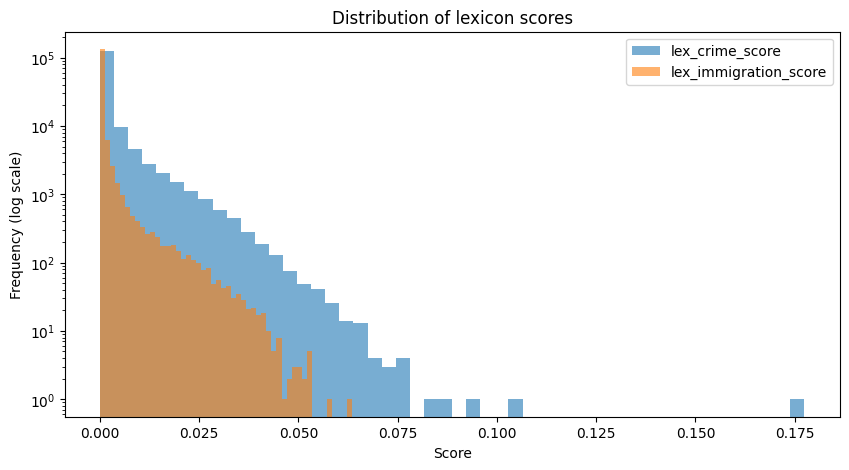

In [ ]:
# Plot distributions of lex_crime_score and lex_immigration_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(articles_clean["lex_crime_score"].dropna(), bins=50, alpha=0.6, label="lex_crime_score")
plt.hist(articles_clean["lex_immigration_score"].dropna(), bins=50, alpha=0.6, label="lex_immigration_score")
plt.yscale("log")
plt.title("Distribution of lexicon scores")
plt.xlabel("Score")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.show()

### 3.2.3 Construction of the first manual annotation set


Now, based on lexicon scores computed so far, we extract ---- 60 articles for manual annotation.

The output of this section is **"manual_annotation_60.xlsx"**. This file will be manually annotated separetly by two annotators. For more details on the execution of this annotation step refer to **section !!!!!!!** and the files in Drive **"Annotation Guidelines.docx"**.

Manual annotation will be useful for two reasons:
1. select the seed articles that will be representative of "crime articles" and "immigration articles" for **section 3.3**
2. use them, together with more articles, as a training and test set to run logistic regression and evaluate the final results of classification

Firstly, we compute two measures for each article: crime_strength and imm_strength. They are the mean of the scores obtaines by zero-shot classification and lexicon scores (where lexicon scores have been normalized, to make them comparable with zs scores).

In [ ]:
import numpy as np
# We create a copy to work on and give new indexes memorizing the old ones under "orig_index"
df = articles_clean.copy().reset_index(drop=False).rename(columns={"index": "orig_index"})

# Keep only columns of interest
df = df[["orig_index", "webTitle", "bodyContent", "Date", "sectionName", "lex_crime_score", "lex_immigration_score", "zs_crime_score", "zs_immigration_score"]].copy()

# Standardize lexicon scores so they are more comparable to zero-shot scores: if above average positive, if not negative
def zsafe(s):
    std = s.std()
    return (s - s.mean()) / std
df["lex_crime_score_standardized"] = zsafe(df["lex_crime_score"])
df["lex_immigration_score_standardized"]   = zsafe(df["lex_immigration_score"])

# Combined topic strengths: average of zero-shot and standardized lexicon evidence
df["crime_strength"] = (df["zs_crime_score"] + df["lex_crime_score_standardized"]) / 2
df["imm_strength"]   = (df["zs_immigration_score"] + df["lex_immigration_score_standardized"]) / 2

df.head(1)

,orig_index,webTitle,bodyContent,Date,sectionName,lex_crime_score,lex_immigration_score,zs_crime_score,zs_immigration_score,lex_crime_score_standardized,lex_immigration_score_standardized,crime_strength,imm_strength
0,0,Iowa underdogs put on brave faces despite all ...,As polling day looms and the cameras turn only...,2016-01-31,US news,0.0,0.0,0.000017,0.000496,-0.398091,-0.230893,-0.199037,-0.115199


Secondly, we compute 4 more scores:
1. **score_both** penalizes imbalance between crime_strength and imm_strength -> signals articles that are likely BOTH crime and immigration
2. **score_crime_only** favors crime over immigration -> signals articles that are likely CRIME_ONLY
3. **score_imm_only** favors immigration over crime -> signals articles that are likely IMMIGRATION_ONLY
4. **score_neither** favors low values of both crime_strength and imm_strength -> signals articles that are likely NEITHER

In [ ]:
# Likely BOTH: high on both, and balanced
df["score_both"] = (df[["crime_strength", "imm_strength"]].min(axis=1) - np.abs(df["crime_strength"] - df["imm_strength"]))

# Likely CRIME ONLY: high crime, low immigration
df["score_crime_only"] = (1.5 * df["crime_strength"] - 1.0 * df["imm_strength"])

# Likely IMMIGRATION ONLY: high immigration, low crime
df["score_imm_only"] = (1.5 * df["imm_strength"] - 1.0 * df["crime_strength"])

# Likely NEITHER: both low
df["score_neither"] = -(df["crime_strength"] + df["imm_strength"])

Thirdly, we use zs_scores and lex_scores to filter articles to create high-confidence pools for each class. SInce from these pool we are gonna select seed articles for phase **3.3**, it's very improtant to ensure clear separation and reduce ambiguity. Thresholds were chosen heuristically.

In [ ]:
both_pool = df[(df["zs_crime_score"] >= 0.30) &
    (df["zs_immigration_score"] >= 0.30) &
    (df["lex_crime_score"] > 0) &
    (df["lex_immigration_score"] > 0)
].copy()

crime_only_pool = df[
    (df["zs_crime_score"] >= 0.40) &
    (df["zs_immigration_score"] <= 0.20)
].copy()

imm_only_pool = df[
    (df["zs_immigration_score"] >= 0.40) &
    (df["zs_crime_score"] <= 0.20)
].copy()

neither_pool = df[
    (df["zs_crime_score"] <= 0.10) &
    (df["zs_immigration_score"] <= 0.10) &
    (df["lex_crime_score"] == 0) &
    (df["lex_immigration_score"] == 0)
].copy()

# If any pool is too small, fall back to full df
if len(both_pool) < 15:
    both_pool = df.copy()
if len(crime_only_pool) < 15:
    crime_only_pool = df.copy()
if len(imm_only_pool) < 15:
    imm_only_pool = df.copy()
if len(neither_pool) < 15:
    neither_pool = df.copy()

Finally, we proceed selecting 15 articles from each of these pools. To do so we create a function pick_top. Applied to each pool, it ranks articles according to the column **"score_col"**; it selects the top **n** articles; it assigns to them the expected **label** creating new column **"manual_target_group"**.

In [ ]:
# Create empty set to memorize what articles have already been selected
used = set()

# Define function that ranks articles in "pool" according to "score_col", with the objective of selecting "n" top articles and assign them "label"
def pick_top(pool, score_col, n, label):
    pool = pool.loc[~pool["orig_index"].isin(used)].copy()
    out = pool.sort_values(score_col, ascending=False).head(n).copy()
    out["manual_target_group"] = label
    used.update(out["orig_index"].tolist())
    return out

# Apply it to each pool
sel_both = pick_top(both_pool, "score_both", 15, "both")
sel_crime = pick_top(crime_only_pool, "score_crime_only", 15, "crime_only")
sel_imm = pick_top(imm_only_pool, "score_imm_only", 15, "immigration_only")
sel_neither = pick_top(neither_pool, "score_neither", 15, "neither")

# Inspect
sel_both.head(2)

,orig_index,webTitle,bodyContent,Date,sectionName,lex_crime_score,lex_immigration_score,zs_crime_score,zs_immigration_score,lex_crime_score_standardized,lex_immigration_score_standardized,crime_strength,imm_strength,score_both,score_crime_only,score_imm_only,score_neither,manual_target_group
125346,125346,Greek police arrest Dutch journalist for helpi...,A Dutch journalist based in Greece has been ar...,2021-06-24,Global development,0.036176,0.018088,0.994860,0.968381,5.636485,5.696781,3.315673,3.332581,3.298765,1.640928,1.683199,-6.648254,both
108624,108624,Coalition minister Alan Tudge engaged in ‘crim...,Alan Tudge unlawfully deprived an asylum seeke...,2020-09-23,Australia news,0.031519,0.014327,0.992244,0.994615,4.859623,4.464174,2.925934,2.729395,2.532856,1.659506,1.168158,-5.655329,both


In [ ]:
# Concatenate DataFrames obtained
manual_label_set = pd.concat([sel_both, sel_crime, sel_imm, sel_neither], ignore_index=True)

# Shuffle within the final set so you don't label all one group in sequence
manual_label_set = manual_label_set.sample(frac=1, random_state=42).reset_index(drop=True)

# Add empty annotation columns for your manual work
manual_label_set["manual_label"] = ""
manual_label_set["manual_notes"] = ""

# Keep only useful columns for annotation
manual_label_set = manual_label_set[
    ["orig_index", "manual_target_group", "manual_label", "manual_notes", "webTitle", "bodyContent", "Date", "sectionName",
        "lex_crime_score", "lex_immigration_score", "zs_crime_score", "zs_immigration_score", "crime_strength", "imm_strength"]
]

manual_label_set.head()

,orig_index,manual_target_group,manual_label,manual_notes,webTitle,bodyContent,Date,sectionName,lex_crime_score,lex_immigration_score,zs_crime_score,zs_immigration_score,crime_strength,imm_strength
0,125346,both,,,Greek police arrest Dutch journalist for helpi...,A Dutch journalist based in Greece has been ar...,2021-06-24,Global development,0.036176,0.018088,9.948604e-01,9.683812e-01,3.315673,3.332581
1,55907,both,,,Senior Ice lawyer sentenced to prison for stea...,A senior lawyer for Immigration and Customs En...,2018-06-28,US news,0.030000,0.018333,9.987934e-01,9.958012e-01,2.802545,3.386515
2,84911,immigration_only,,,Trump sets cap for refugee admission at an all...,The Trump administration will admit no more th...,2019-09-26,US news,0.006342,0.052854,2.840974e-05,9.868788e-01,0.329974,9.038555
3,9898,neither,,,Euro 2016 quarter-finals: who will win?,"Poland v Portugal, Thursday 8pm BST, Marseille...",2016-06-30,Football,0.000000,0.000000,3.466326e-07,7.811483e-07,-0.199046,-0.115446
4,89209,both,,,Wilson Security settles out of court with refu...,Wilson Security has settled out of court with ...,2019-11-25,Australia news,0.020333,0.009242,9.709092e-01,9.870796e-01,1.982289,1.892491


In [ ]:
manual_label_set["manual_target_group"].value_counts()

,count
manual_target_group,
both,15
immigration_only,15
neither,15
crime_only,15


The selected articles were exported to an Excel file for manual annotation.

First, the file was prepared:

```python
to_annotate = manual_label_set[["orig_index", "webTitle", "bodyContent", "Date", "manual_label", "manual_notes"]].copy()
to_annotate = to_annotate.rename(columns={"webTitle": "Title"})
to_annotate.to_excel("manual_annotation_60.xlsx", index=False)
```

Then the export was performed with the following code:
```python
from google.colab import files
files.download("manual_annotation_60.xlsx")
```

In the submitted project materials, the resulting annotation file is already provided separately, so the download step is not repeated in the notebook.

### 3.2.4 Final lexicon refinement


In this section we compute the word embedding of all the lemmas that appear in column body_sent_lemma_tokens, using **Word2Vec** model on sentence-level tokenized text. These embeddings will be used to find words that are vecotrially close to the words in the acutal lexicons.

The embedding computation was perforemd on HPC using the following files:

- `guardian_w2v.py`: trains the Word2Vec model on the lemmatized sentence-level tokens
- `guardian_w2v.sh`: launches that script on the HPC system

The input is:

- `articles_clean_with_sentence_lemma.csv`

The output of that step is:

- `word2vec_model.model`

Now we upload the model, reload the lexicons and create **base_crime_words** and **base_immigration_words**, two pools containing all thw words appearing either in
Then we define the function **creating_semantic_field** that for a given word finds the 10 closest words.

In [ ]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.3 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec
w2v_model = Word2Vec.load(f"/content/drive/MyDrive/NLP_project/hpc_w2v/word2vec_model.model")
print(w2v_model.vector_size)

100


In [ ]:
# We recap what were the words selected in 3.2.2 (even to make section 3.2.4 independently runnable)
lexicon_crime = {
    "crime", "criminal", "offence", "arrest", "police", "prosecution","court", "prison", "violence", "murder", "assault", "robbery",
    "theft", "fraud", "sentence", "incarcerate", "convict", "burglary", "stalking", "harassment", "guilty", "conviction", "perpetrator", "detention"
}

crime_phrases = {
    "without parole", "offence record", "knife crime", "violent crime", "gun crime", "pepper spray", "criminal justice system",
    "domestic violence", "sexual assault", "sexual harassement", "sexual harrassement", "proceeds of crime", "enter a plea",
    "plead guilty", "plead not guilty", "acquitted of", "jury acquittal", "remanded in custody", "held on remand",
}

lexicon_immigration = set(["immigration", "immigrant", "migration", "migrant", "asylum",
                          "refugee", "deportation", "deport", "border", "visa",
                            "citizenship", "nationality", "naturalisation", "integration", "undocumented"])

immigration_phrases = {
    "undocumented immigrant", "asylum seeker", "immigration authority", "immigration detention center",
    "asylum claim", "migration program", "immigration policy"
}


We create:
- **base_crime_words** two pools containing the words in either **lexicon_crime** or

In [ ]:
#Here we first create a set with all the words appearing either in lexicon_crime or in crime_phrases. The same will be done for immigration
crime_phrase_words = set()
to_set = list(word.split() for word in crime_phrases)
for words in to_set:
    for word in words:
        crime_phrase_words.add(word)

base_crime_words = lexicon_crime.union(crime_phrase_words)

In [ ]:
#Here we create the union between lexicon and phrases
immigration_phrase_words = set()
to_set = list(word.split() for word in immigration_phrases)
for words in to_set:
    for word in words:
        immigration_phrase_words.add(word)

base_immigration_words = lexicon_immigration.union(immigration_phrase_words)

In [ ]:
#here instead we create a function that collectes the union of the 10 cosine closest words of each of the words in a given list.
#In this case, we will use first for crime and then for immigration, the list with the union from lexicon and phrases.

def creating_semantic_field (set_of_words, w2v_model_vocab, closest_n):
    neighboors = {w: [] for w in set_of_words}
    for w in set_of_words:
        if w in w2v_model_vocab:
            neighboors[w] = []
            for neigh_position in range(closest_n):
                neighboors[w].append(w2v_model_vocab.most_similar(w, topn=closest_n)[neigh_position][0])
    semantic_candidates = set()
    for word in neighboors.keys():
        new_semantic_words = set(neighboors[word])
        for parola in new_semantic_words:
            semantic_candidates.add(parola)
    return semantic_candidates

In [ ]:
immigration_candidate_sf = creating_semantic_field(base_immigration_words, w2v_model.wv, 10)
crime_candidate_sf = creating_semantic_field(base_crime_words, w2v_model.wv, 10)
print(f"The semantic filed candidate words from top 10 neighboorhood for the field of crime are:\n {crime_candidate_sf}")
print("\n")
print(f"The semantic filed candidate words from top 10 neighboorhood for the field of immigration are:\n {immigration_candidate_sf}")
print("\n")
print(f"The common words are {immigration_candidate_sf.intersection(crime_candidate_sf)}")

The semantic filed candidate words from top 10 neighboorhood for the field of crime are:
 {'policing', 'defraud', 'offence', 'murderer', 'ipp', 'extortion', 'teargas', 'mcmichaels', 'victimless', 'jurors', 'embezzlement', 'simply', 'indictable', 'sectarian', 'homicidal', 'jail', 'cps', 'inquiries', 'retrial', 'scam', 'vinegar', 'harrassment', 'rioting', 'refusal', 'sentencing', 'prisoner', 'criminality', 'hba', 'conviction', 'before', 'saelee', 'incarcerate', 'victim', 'dhrs', 'juror', 'dingemans', 'convict', 'sexual', 'homicide', 'blaming', 'misdemeanor', 'compartmentation', 'rutenburg', 'sulphuric', 'mita', 'officer', 'some', 'upon', 'tasere', 'remand', 'aggravated', 'cwj', 'trafficking', 'kidnap', 'hakea', 'racist', 'discrimination', 'collaery', 'proceeds', 'defendant', '❦', 'actually', 'commutation', 'prosecutions', 'exoneration', 'buryat', 'bail', 'bellfield', 'or', 'forwent', 'mustard', 'so', 'shoplifting', 'maranguka', 'tsilhqot’in', 'detention', 'volobuyev', 'infanticide', 'abh

We manually selected among **crime_candidate_sf** and **immigration_candidate_sf** only the words that we consider representative of **crime** and **immigration**.

In [ ]:
# These are the words that we discarded for crime
crime_semantic_not_use = {
      'grooming', 'itiary', 'cumin', 'multiplicative','supreme', 'tearga', '11:59pm',
      'mcmichaels', 'upon', 'mourad', '41.9c', 'hamblen', 'arraignment', 'devaluing',
      'rejoin','collaery', 'khilnani', 'never', 'contingencies', 'spay', 'hearing', 'wrongful',
      'lemon', 'secessionism', 'during', 'this', 'rutenburg', '314,835', 'where', 'upskirte',
      'increased', 'entry', 'officer', 'capsicum', 'defraud', 'astarita', 'mechanism',
      'vagrancy', 'saelee', 'exit', 'the', '1,029', 'or', 'marketise', 'apparatus', 'not',
      'sieferle', 'open', 'irregularity', 'request', 'pezzola', 'eject', 'yongah', 'sectarian',
      'violent', 'wurxburg', 'screwdriver', 'indict', 'apology', 'dingemans', 'include', 'rifle',
      'volobuyev', 'macur', 'mustard', '38.5c', 'trafficking', 'nor', 'gyeongsang', 'plier',
      'slaying', 'viably', 'racist', 'bamyan', 'simply', 'refusal', 'anyway', 'complaiant',
      'paprika', 'tally', 'saydnaya', "tsihqot'in", 'just', 'structure', 'manus', 'intrastate',
      'bail', 'blaming', 'entreaty', 'hakea', 'chilli', 'exploitation', 'coarsely', 'privatised',
      'confess', 'do', 'holster', 'concurring', 'heinous', 'osayande', '53,135', 'atrocity',
      'in', 'doing', 'doxing', 'maranguka', '49.6c', 'remand','which', 'apprehend', 'reopen',
      'vigilantism', 'of', 'bellfield','paring','scarpulla',
      'forwent', 'unless', 'be', 'for', 'salt', 'sheskey', 'tipples', 'sollecito',
      'qingpu', 'actually', '11,030', 'acetone', 'peppercorn', 'marketised',
      'defilement', 'pooling', 'unhindered', 'holroyde', 'onto', 'and', 'n’t',
      'confinement', 'malmsbury', 'bestiality', 'retry', '119,789', 'falsification',
      'rsdl', 'psni', 'hba', 'asiya', '34,700', '❦', 'ruling', 'another',
      'coriander', 'discrimination', 'tupman', 'off', 'justices', 'return',
      'institutionalist', 'sulphuric', 'vinegar', 'proceeds', 'computerise',
      'quashing', 'reparatory', 'court', 'moraliser', 'preska', 'incapacitant',
      'repeated', 'only', 'silencer', 'indecency', 'that', 'bomana', 'sexual',
      'swathes', 'evin', 'pervert', 'sentence', 'serrate', 'while', 'chegeni',
      'punneo', '32.75', 'sterilize', 'commutation', 'racialize', 'enabling',
      'before', 'lfd', 'arrive', 'compartmentation', 'shrove', 'judge', 'ahmaud',
      'hacking', 'appeals', 'nobody', 'acquittal', 'some', 'vigilante',
      'submachine', 'buryat', 'custody', 'but', 'if', 'magistrate', 'seek', '922',
      'mita', 'writs', 'forewoman', '00.01', 'so'
                      }
# These are the remainging words that we have to expand the lexicon_crime with
crime_semantic_field = crime_candidate_sf.difference(crime_semantic_not_use)

# These are the words that we discarded for immigration
immigration_semantic_not_use = {
    '72.7', 'accommodative', 'accusation', 'advancing', 'afghans', 'agency',
    'airspace', 'allegation', 'allege', 'appleseed', 'apprehend', 'argue',
    'arsht', 'assertion', 'authorities', 'baselessly', 'belfer', 'bengalis',
    'bloomington', 'bn(o', 'bno', 'bomana', 'bridging', 'busybeans',
    'cadetship', 'cce', 'chagossians', 'chaman', 'checkpoint', 'citizenship',
    'cohesion', 'conferral', 'cooperation', 'dadaab', 'densification', 'deny',
    'detain', 'detainee', 'detention', 'economic', 'emancipatory', 'erez',
    'eritreans', 'ethnicity', 'evros', 'farmworker', 'flee', 'glaa',
    'government', 'guatemalans', 'h-1b', 'h-2b', 'haitians', 'hondurans',
    'iaa', 'identity', 'ilr', 'institute', 'j-1', 'kaesong', 'manus',
    'medyka', 'mexicans', 'migration', 'mischaracterize', 'mobility',
    'modernisation', 'mouzalas', 'muxe', 'nationality', 'naturalize',
    'naturalized', 'niskanen', 'nondiscriminatory', 'nonprofit', 'notis',
    'official', 'ozoma', 'parentsnext', 'passport', 'pepfar', 'persecution',
    'policy', 'policymaking', 'pre-1967', 'prison', 'programme', 'proposal',
    'reapplie', 'rebalancing', 'recommitment', 'reentry', 'reform',
    'regulator', 'religion', 'reorientation', 'resettle', 'rethinking',
    'reunification', 'rohingya', 'salvadorans', 'seeker', 'sepa',
    'shantaruban', 'shorenstein', 'strategy', 'suchiate', 'supplemental',
    'syrians', 'tanf', 'tapachula', 'tier-1', 'uani', 'ucla',
    'unaccompanie', 'unaccompanied', 'undemocratically', 'untruthfully',
    'watchdog', 'wic', 'workstream', 'yongah'
}

# These are the remaining words that we have to expand the lexicon_immigration with
immigration_semantic_field = immigration_candidate_sf.difference(immigration_semantic_not_use)

# We expand the roiginal lexicons
lexicon_crime |= crime_semantic_field
lexicon_immigration |= immigration_semantic_field

### 3.2.5 Final lexicon scores

In this section we recompute **lex_crime_score** and **lex_immigration_score** using the expanded lexicon used in section **3.2.6**. The following code closely resembles the one in **section 3.2.2**.

In [ ]:
# Sort phrases by length descending so longer phrases are matched before shorter ones
import re
crime_phrases_sorted = sorted(crime_phrases, key=len, reverse=True)
immigration_phrases_sorted = sorted(immigration_phrases, key=len, reverse=True)

# Build regex patterns:
# Regex for phrases
crime_phrase_pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, crime_phrases_sorted))
immigration_phrase_pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, immigration_phrases_sorted))

# Regex for single words
crime_word_pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, sorted(lexicon_crime)))
immigration_word_pattern = r"\b(?:%s)\b" % "|".join(map(re.escape, sorted(lexicon_immigration)))

In [ ]:
# We count phrases before words because phrases like "knife crime" should not later cause "crime" to be counted again
articles_clean["crime_phrase_count"] = articles_clean["bodyContent_lemma"].str.count(crime_phrase_pattern)
articles_clean["immigration_phrase_count"] = articles_clean["bodyContent_lemma"].str.count(immigration_phrase_pattern)

In [ ]:
# Remove phrases from text to avoid double counting when we later count single words
articles_clean["body_no_crime_phrases"] = articles_clean["bodyContent_lemma"].str.replace(crime_phrase_pattern, " ", regex=True)
articles_clean["body_no_immigration_phrases"] = articles_clean["bodyContent_lemma"].str.replace(immigration_phrase_pattern, " ", regex=True)

In [ ]:
# Count remaining single-words mathces (may take few minutes)
articles_clean["crime_word_count"] = articles_clean["body_no_crime_phrases"].str.count(crime_word_pattern)
articles_clean["immigration_word_count"] = articles_clean["body_no_immigration_phrases"].str.count(immigration_word_pattern)

In [ ]:
# Total counts
articles_clean["crime_count"] = (articles_clean["crime_phrase_count"] + articles_clean["crime_word_count"])
articles_clean["immigration_count"] = (articles_clean["immigration_phrase_count"] + articles_clean["immigration_word_count"])

In [ ]:
if "n_tokens" not in articles_clean.columns:
  articles_clean["n_tokens"] = articles_clean["bodyContent_lemma"].str.split().str.len()

# Normalized scores
articles_clean["crime_score"] = (articles_clean["crime_count"] / articles_clean["n_tokens"].replace(0, 1))
articles_clean["immigration_score"] = (articles_clean["immigration_count"] / articles_clean["n_tokens"].replace(0, 1))

In [ ]:
# Inspect highest-scoring crime articles
articles_clean[
    [
        "webTitle", "crime_phrase_count", "crime_word_count", "crime_count", "crime_score",
        "immigration_phrase_count", "immigration_word_count", "immigration_count", "immigration_score"
    ]
].sort_values("crime_score", ascending=False).head()

,webTitle,crime_phrase_count,crime_word_count,crime_count,crime_score,immigration_phrase_count,immigration_word_count,immigration_count,immigration_score
57754,The 19 black radicals who are still in prison ...,4,117,121,0.181955,0,0,0,0.0
121495,Derek Chauvin was found guilty – how typical i...,2,43,45,0.133929,0,0,0,0.0
10411,Anjem Choudary denies breaking terrorism laws,0,13,13,0.126214,0,0,0,0.0
47639,John Worboys's victims were told his sentence ...,2,73,75,0.119048,0,0,0,0.0
44914,New York City on track to end year with sharp ...,0,27,27,0.114407,0,0,0,0.0


In [ ]:
# Inspect highest-scoring immigration articles
articles_clean[
    [
        "webTitle", "crime_phrase_count", "crime_word_count", "crime_count", "crime_score",
        "immigration_phrase_count", "immigration_word_count", "immigration_count", "immigration_score"
    ]
].sort_values("immigration_score", ascending=False).head()

,webTitle,crime_phrase_count,crime_word_count,crime_count,crime_score,immigration_phrase_count,immigration_word_count,immigration_count,immigration_score
108520,Immigrant representation on TV over-emphasizes...,0,10,10,0.016722,5,33,38,0.063545
102682,Uganda reopens border to thousands of people f...,0,6,6,0.012270,2,27,29,0.059305
84911,Trump sets cap for refugee admission at an all...,0,9,9,0.019027,3,23,26,0.054968
23356,"US travel ban puts 20,000 refugees in 'precari...",0,2,2,0.003534,0,31,31,0.054770
115210,Refugee rights 'under attack' at Europe's bord...,0,13,13,0.025194,1,27,28,0.054264


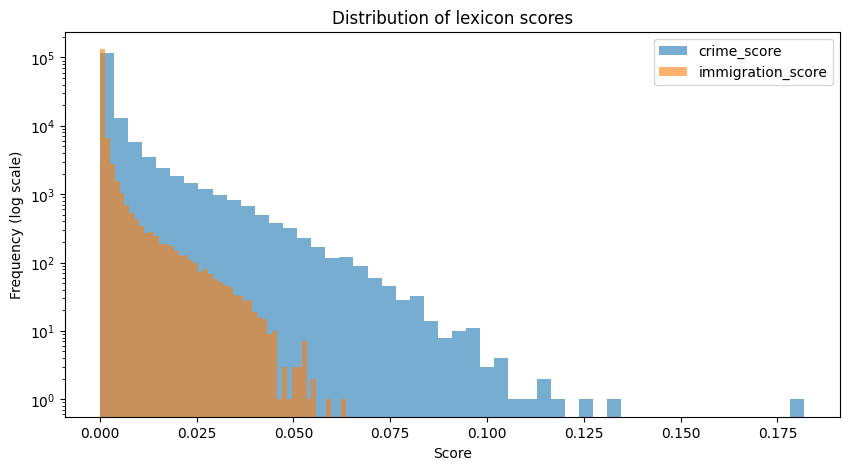

In [ ]:
# Plot distributions of crime_score and immigration_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(articles_clean["crime_score"].dropna(), bins=50, alpha=0.6, label="crime_score")
plt.hist(articles_clean["immigration_score"].dropna(), bins=50, alpha=0.6, label="immigration_score")
plt.yscale("log")
plt.title("Distribution of lexicon scores")
plt.xlabel("Score")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.show()

In [ ]:
articles_clean.head()

,bodyContent,Date,webTitle,sectionName,month_start,year_month,year,month,body_sent_lemma_tokens,bodyContent_lemma,...,crime_score,immigration_score,crime_phrase_count,immigration_phrase_count,body_no_crime_phrases,body_no_immigration_phrases,crime_word_count,immigration_word_count,lex_crime_score,lex_immigration_score
0,As polling day looms and the cameras turn only...,2016-01-31,Iowa underdogs put on brave faces despite all ...,US news,2016-01-01,2016-01,2016,1,"[['as', 'polling', 'day', 'loom', 'and', 'the'...",as polling day loom and the camera turn only t...,...,0.000000,0.0,0,0,as polling day loom and the camera turn only t...,as polling day loom and the camera turn only t...,0,0,0.000000,0.0
1,"In Des Moines on Sunday, the Guardian was give...",2016-01-31,Iowa caucus: hologram eagle and Jesus star on ...,US news,2016-01-01,2016-01,2016,1,"[['in', 'des', 'moines', 'on', 'sunday', 'the'...",in des moines on sunday the guardian be give a...,...,0.000000,0.0,0,0,in des moines on sunday the guardian be give a...,in des moines on sunday the guardian be give a...,0,0,0.000000,0.0
2,A British pilot who was shot dead by an elepha...,2016-01-31,British pilot in Tanzania 'manoeuvred ​to save...,World news,2016-01-01,2016-01,2016,1,"[['a', 'british', 'pilot', 'who', 'be', 'shoot...",a british pilot who be shoot dead by an elepha...,...,0.007622,0.0,0,0,a british pilot who be shoot dead by an elepha...,a british pilot who be shoot dead by an elepha...,10,0,0.005335,0.0
3,USA took a step toward shaking off the ghosts ...,2016-01-31,USA 3-2 Iceland | International friendly match...,Football,2016-01-01,2016-01,2016,1,"[['usa', 'take', 'a', 'step', 'toward', 'shake...",usa take a step toward shake off the ghost of ...,...,0.000000,0.0,0,0,usa take a step toward shake off the ghost of ...,usa take a step toward shake off the ghost of ...,0,0,0.000000,0.0
4,"The clean-shaven, spectacle free and suspiciou...",2016-01-31,Reinvigorated Paul Lambert reflects after impr...,Football,2016-01-01,2016-01,2016,1,"[['the', 'clean', 'shaven', 'spectacle', 'free...",the clean shaven spectacle free and suspicious...,...,0.000000,0.0,0,0,the clean shaven spectacle free and suspicious...,the clean shaven spectacle free and suspicious...,0,0,0.000000,0.0


In [ ]:
articles_clean.columns

Index(['bodyContent', 'Date', 'webTitle', 'sectionName', 'month_start',
       'year_month', 'year', 'month', 'body_sent_lemma_tokens',
       'bodyContent_lemma', 'zs_crime_score', 'zs_immigration_score',
       'n_tokens', 'crime_count', 'immigration_count', 'crime_score',
       'immigration_score', 'crime_phrase_count', 'immigration_phrase_count',
       'body_no_crime_phrases', 'body_no_immigration_phrases',
       'crime_word_count', 'immigration_word_count', 'lex_crime_score',
       'lex_immigration_score'],
      dtype='object')

In [ ]:
# Clean dataset from columns that will not be usefull for next steps
cols_keep = [
    "bodyContent", "Date", "webTitle", "sectionName", "month_start", "year_month", "year", "month", "body_sent_lemma_tokens",
    "bodyContent_lemma", "n_tokens", "crime_score", "immigration_score", "zs_crime_score", "zs_immigration_score"
]

articles_clean_light = articles_clean[cols_keep].copy()

Convert the file to .parquet and download it with the following code:

```python
articles_clean_light.to_parquet("articles_clean_with_main_scores_light.parquet", index=False)

drive_path = "/content/drive/MyDrive/NLP_project/articles_clean_with_lemma_lexicon_zs_scores_light.parquet"
articles_clean_light.to_parquet(drive_path, index=False)
```

The file `articles_clean_with_lemma_lexicon_zs_scores_light.parquet` contains the main columns needed for the next stages of the project, including:

1. zero-shot classification scores
2. lexicon-based scores

## **3.3 Vector similarity**

As a third article-level signal, we compute embedding-based similarity scores. This method complements both zero-shot classification and lexicon scoring. Zero-shot classification depends on the model's interpretation of a label hypothesis, while lexicon scoring depends on explicit word matches. Embedding similarity instead compares articles in a dense semantic space, allowing us to capture topical similarity even when articles use different surface vocabulary. (Reimers and Gurevych, 2019: https://aclanthology.org/D19-1410/)

We manually select representative seed articles for each topic and compute the cosine similarity between every article embedding and the seed-article embeddings. This is related to prototype-based classification, where a class is represented by a small set of examples in embedding space and new examples are scored by their distance or similarity to that class representation. This gives us an additional, example-based measure of whether an article is close to clearly topical articles. (Snell et al., 2017: https://arxiv.org/abs/1703.05175)

### 3.3.1) Preparation of vector data

Article embeddings were computed on HPC and initially stored in chunked `.npy` files.

For this step the files used were:
- `run_embed_articles.sh`
- `embed_articles_bge.py`

The input file was:
- `articles_clean_with_lexicon_and_zs_scores.csv`

The output obtained are:
- `embeddings_full.npy`
- `articles_metadata_small.parquet`

The following cells load these prepared files and verify the alignment between metadata rows and embedding rows.

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

meta_small = pd.read_parquet("/content/drive/MyDrive/NLP_project/output_bge_base/articles_metadata_small.parquet")
embeddings = np.load("/content/drive/MyDrive/NLP_project/output_bge_base/embeddings_full.npy")

print(meta_small.shape)
print(embeddings.shape)

(148719, 7)
(148719, 768)


In [ ]:
# Verify that metadata rows and embedding rows are perfectly aligned
assert len(meta_small) == embeddings.shape[0]
assert (meta_small["embedding_index"].to_numpy() == np.arange(len(meta_small))).all()

print("Alignment OK")

Alignment OK


In [ ]:
# Initialize empty columns that will later store the embedding-based similarity scores
meta_small["crime_embed_score"] = np.nan
meta_small["immigration_embed_score"] = np.nan

### 3.3.2) Selection of seed articles

As reference points for the vector-similarity method, we manually selected a set of seed articles for the **immigration** topic and a set of seed articles for the **crime** topic. The selection was based on manual inspection, with the aim of choosing articles that were clearly representative of the target category. Each seed article is identified by its `orig_index` in the dataset.

**Immigration seed articles** (`orig_index`):  
`84911, 14489, 51398, 105602, 49540, 77085, 139474, 57873, 2665, 100951, 55952`

**Crime seed articles** (`orig_index`):  
`47397, 61060, 47458, 57754, 103496, 75747, 121495, 131007, 44914, 34971, 94375, 29613, 15640, 43826`

For each article embedding, cosine similarity is computed against these seed sets in order to derive the embedding-based crime and immigration scores.

Since the seed articles were originally identified by their `orig_index` in the manually annotated dataset, we first verify that the reduced metadata table used for the embeddings follows the same article order as the scored dataframe loaded earlier. This allows us to reconstruct the `orig_index` field needed to retrieve the corresponding seed embeddings.

In [ ]:
# Inspect the available metadata columns before reconstructing orig_index
meta_small.columns

Index(['webTitle', 'sectionName', 'crime_score', 'immigration_score',
       'zs_crime_score', 'zs_immigration_score', 'embedding_index',
       'crime_embed_score', 'immigration_embed_score'],
      dtype='object')

In [ ]:
# Check whether the embedding metadata preserves the same row order as the scored article dataframe
# articles_scored_check = articles_scored.reset_index(drop=False).rename(columns={"index": "orig_index"})

# print(len(articles_scored_check), len(meta_small))

# for col in ["webTitle", "sectionName", "crime_score", "immigration_score", "zs_crime_score", "zs_immigration_score"]:
#     left = articles_scored_check[col].reset_index(drop=True)
#     right = meta_small[col].reset_index(drop=True)
#     print(col, left.equals(right))

In [ ]:
# Reconstruct orig_index in the embedding metadata from the preserved row order
meta_small = meta_small.reset_index(drop=False).rename(columns={"index": "orig_index"})

In [ ]:
# Compute cosine similarity from every article embedding to the crime and immigration seed sets

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Seed articles identified by orig_index
index_seed_immigration = [84911, 14489, 51398, 105602, 49540, 77085, 139474, 57873, 2665, 100951, 55952]
index_seed_crime = [47397, 61060, 47458, 57754, 103496, 75747, 121495, 131007, 44914, 34971, 94375, 29613, 15640, 43826]

# Verify that the metadata contains the article identifier needed to match the selected seeds
if "orig_index" not in meta_small.columns:
    raise ValueError("meta_small must contain an 'orig_index' column to match seed articles.")

# Retrieve the embedding rows corresponding to the selected seed articles
imm_seed_rows = meta_small.loc[meta_small["orig_index"].isin(index_seed_immigration), "embedding_index"].to_numpy()
crime_seed_rows = meta_small.loc[meta_small["orig_index"].isin(index_seed_crime), "embedding_index"].to_numpy()

print("Immigration seeds found:", len(imm_seed_rows), "/", len(index_seed_immigration))
print("Crime seeds found:", len(crime_seed_rows), "/", len(index_seed_crime))

# Extract the embedding matrices for the two seed sets
imm_seed_embeddings = embeddings[imm_seed_rows]
crime_seed_embeddings = embeddings[crime_seed_rows]

print("Immigration seed embedding matrix:", imm_seed_embeddings.shape)
print("Crime seed embedding matrix:", crime_seed_embeddings.shape)

# Compute cosine similarity between all article embeddings and each seed embedding
sim_to_imm = cosine_similarity(embeddings, imm_seed_embeddings)
sim_to_crime = cosine_similarity(embeddings, crime_seed_embeddings)

print("Similarity matrix to immigration seeds:", sim_to_imm.shape)
print("Similarity matrix to crime seeds:", sim_to_crime.shape)

Immigration seeds found: 11 / 11
Crime seeds found: 14 / 14
Immigration seed embedding matrix: (11, 768)
Crime seed embedding matrix: (14, 768)
Similarity matrix to immigration seeds: (148719, 11)
Similarity matrix to crime seeds: (148719, 14)


To obtain one embedding-based score per topic, we aggregate the similarities across all seed articles using the median. This yields a crime-related similarity score and an immigration-related similarity score for each article.

In [ ]:
# Aggregate seed-level similarities into one embedding-based score per topic using the median
meta_small["immigration_embed_score"] = np.median(sim_to_imm, axis=1)
meta_small["crime_embed_score"] = np.median(sim_to_crime, axis=1)

meta_small[["orig_index","webTitle", "crime_embed_score", "immigration_embed_score"]].head()

,orig_index,webTitle,crime_embed_score,immigration_embed_score
0,0,Iowa underdogs put on brave faces despite all ...,0.711065,0.736091
1,1,Iowa caucus: hologram eagle and Jesus star on ...,0.719503,0.740261
2,2,British pilot in Tanzania 'manoeuvred ​to save...,0.720391,0.728570
3,3,USA 3-2 Iceland | International friendly match...,0.604430,0.651401
4,4,Reinvigorated Paul Lambert reflects after impr...,0.657919,0.640548


The resulting columns `crime_embed_score` and `immigration_embed_score` summarize how strongly each article aligns, in embedding space, with the manually selected seed articles for the two topics.

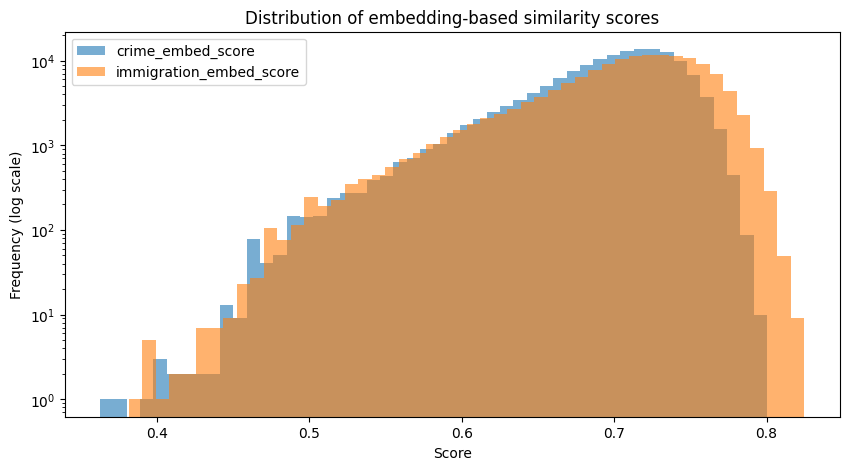

In [ ]:
# Plot the distributions of the embedding-based similarity scores on a log-scaled frequency axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(meta_small["crime_embed_score"].dropna(), bins=50, alpha=0.6, label="crime_embed_score")
plt.hist(meta_small["immigration_embed_score"].dropna(), bins=50, alpha=0.6, label="immigration_embed_score")
plt.yscale("log")
plt.title("Distribution of embedding-based similarity scores")
plt.xlabel("Score")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.show()

The embedding-based scores are concentrated in a relatively narrow range, which is expected because cosine similarity between dense document embeddings tends to vary less sharply than lexicon counts. The two distributions are broadly similar, while still showing some separation in their upper tails, indicating that the seed-based similarity measure captures topic-related variation across articles.

### 3.3.3 Combine all scores in one dataset

In [ ]:
# Load the scored article checkpoint that will be extended with the embedding-based scores
import pandas as pd
articles_scored = pd.read_parquet("/content/drive/MyDrive/NLP_project/articles_clean_with_lemma_lexicon_zs_scores_light.parquet")

In [ ]:
np.median(sim_to_imm, axis=1)[:5], np.median(sim_to_crime, axis=1)[:5]

(array([0.73609066, 0.7402607 , 0.7285695 , 0.65140057, 0.6405483 ],
       dtype=float32),
 array([0.7110647 , 0.7195028 , 0.72039115, 0.60442966, 0.6579191 ],
       dtype=float32))

In [ ]:
articles_scored = articles_scored.reset_index().rename(columns={"index": "orig_index"})

In [ ]:
# Add the embedding-based similarity scores computed
articles_scored["crime_embed_score"] = meta_small["crime_embed_score"].to_numpy()
articles_scored["immigration_embed_score"] = meta_small["immigration_embed_score"].to_numpy()

articles_scored.head()

,orig_index,bodyContent,Date,webTitle,sectionName,month_start,year_month,year,month,body_sent_lemma_tokens,bodyContent_lemma,n_tokens,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score
0,0,As polling day looms and the cameras turn only...,2016-01-31,Iowa underdogs put on brave faces despite all ...,US news,2016-01-01,2016-01,2016,1,"[['as', 'polling', 'day', 'loom', 'and', 'the'...",as polling day loom and the camera turn only t...,1017,0.000000,0.0,0.000017,0.000496,0.711065,0.736091
1,1,"In Des Moines on Sunday, the Guardian was give...",2016-01-31,Iowa caucus: hologram eagle and Jesus star on ...,US news,2016-01-01,2016-01,2016,1,"[['in', 'des', 'moines', 'on', 'sunday', 'the'...",in des moines on sunday the guardian be give a...,402,0.000000,0.0,0.000007,0.000038,0.719503,0.740261
2,2,A British pilot who was shot dead by an elepha...,2016-01-31,British pilot in Tanzania 'manoeuvred ​to save...,World news,2016-01-01,2016-01,2016,1,"[['a', 'british', 'pilot', 'who', 'be', 'shoot...",a british pilot who be shoot dead by an elepha...,1312,0.007622,0.0,0.985608,0.000038,0.720391,0.728570
3,3,USA took a step toward shaking off the ghosts ...,2016-01-31,USA 3-2 Iceland | International friendly match...,Football,2016-01-01,2016-01,2016,1,"[['usa', 'take', 'a', 'step', 'toward', 'shake...",usa take a step toward shake off the ghost of ...,717,0.000000,0.0,0.000006,0.000038,0.604430,0.651401
4,4,"The clean-shaven, spectacle free and suspiciou...",2016-01-31,Reinvigorated Paul Lambert reflects after impr...,Football,2016-01-01,2016-01,2016,1,"[['the', 'clean', 'shaven', 'spectacle', 'free...",the clean shaven spectacle free and suspicious...,396,0.000000,0.0,0.000011,0.000043,0.657919,0.640548


In [ ]:
columns_to_keep = ['Date', 'webTitle', 'bodyContent', 'year_month', 'sectionName', 'crime_score', 'immigration_score', 'zs_crime_score', 'zs_immigration_score', 'crime_embed_score', 'immigration_embed_score']

articles_scored = articles_scored[columns_to_keep]
articles_scored = articles_scored.reset_index(drop=False).rename(columns={"index": "orig_index"})

articles_scored.head()

,orig_index,Date,webTitle,bodyContent,year_month,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score
0,0,2016-01-31,Iowa underdogs put on brave faces despite all ...,As polling day looms and the cameras turn only...,2016-01,US news,0.000000,0.0,0.000017,0.000496,0.711065,0.736091
1,1,2016-01-31,Iowa caucus: hologram eagle and Jesus star on ...,"In Des Moines on Sunday, the Guardian was give...",2016-01,US news,0.000000,0.0,0.000007,0.000038,0.719503,0.740261
2,2,2016-01-31,British pilot in Tanzania 'manoeuvred ​to save...,A British pilot who was shot dead by an elepha...,2016-01,World news,0.007622,0.0,0.985608,0.000038,0.720391,0.728570
3,3,2016-01-31,USA 3-2 Iceland | International friendly match...,USA took a step toward shaking off the ghosts ...,2016-01,Football,0.000000,0.0,0.000006,0.000038,0.604430,0.651401
4,4,2016-01-31,Reinvigorated Paul Lambert reflects after impr...,"The clean-shaven, spectacle free and suspiciou...",2016-01,Football,0.000000,0.0,0.000011,0.000043,0.657919,0.640548


At this stage, we save the dataframe `articles_scored` to Google Drive so that the scored dataset is stored and can be loaded again later without recomputing the scores. We save the file in **Parquet** format, which is efficient and convenient for later use in Python.

The code used is:

```python
output_path = "/content/drive/MyDrive/NLP_project/articles_scored.parquet"
articles_scored.to_parquet(output_path, index=False)
```

## **3.4 Combined score dataset - selection of set to manually label**


In this subsection, we combine the different article-level signals computed so far into a single dataset. Starting from the light checkpoint containing the cleaned text, temporal metadata, zero-shot scores, and lexicon-based scores, we add the embedding-based similarity scores obtained in Section 3.3. The resulting dataframe provides the full set of features used in the subsequent stages of the project.

In [ ]:
import pandas as pd
articles_scored = pd.read_parquet('/content/drive/MyDrive/NLP_project/articles_scored.parquet')

In [ ]:
import numpy as np
import pandas as pd

# Work on a copy so the original dataframe is preserved
sampling_df = articles_scored.copy()

# Define the score columns used for each topic
crime_signal_cols = ["crime_score", "zs_crime_score", "crime_embed_score"]
imm_signal_cols = ["immigration_score", "zs_immigration_score", "immigration_embed_score"]

# Compute mean signal for each topic
sampling_df["crime_mean_signal"] = sampling_df[crime_signal_cols].mean(axis=1)
sampling_df["imm_mean_signal"] = sampling_df[imm_signal_cols].mean(axis=1)

# Compute ambiguity and overall topic strength
sampling_df["margin"] = (sampling_df["crime_mean_signal"] - sampling_df["imm_mean_signal"]).abs()
sampling_df["strength"] = sampling_df["crime_mean_signal"] + sampling_df["imm_mean_signal"]

# Compute disagreement within each topic side
sampling_df["crime_disagreement"] = sampling_df[crime_signal_cols].std(axis=1)
sampling_df["imm_disagreement"] = sampling_df[imm_signal_cols].std(axis=1)

# Optional combined disagreement measures
sampling_df["mean_disagreement"] = sampling_df[["crime_disagreement", "imm_disagreement"]].mean(axis=1)
sampling_df["max_disagreement"] = sampling_df[["crime_disagreement", "imm_disagreement"]].max(axis=1)

# Inspect the new columns
sampling_df[["webTitle", "crime_mean_signal", "imm_mean_signal", "margin", "strength", "crime_disagreement", "imm_disagreement", "mean_disagreement", "max_disagreement"]].head()

,webTitle,crime_mean_signal,imm_mean_signal,margin,strength,crime_disagreement,imm_disagreement,mean_disagreement,max_disagreement
0,Iowa underdogs put on brave faces despite all ...,0.237027,0.245529,0.008502,0.482556,0.410529,0.424839,0.417684,0.424839
1,Iowa caucus: hologram eagle and Jesus star on ...,0.239837,0.246766,0.006930,0.486603,0.415403,0.427379,0.421391,0.427379
2,British pilot in Tanzania 'manoeuvred ​to save...,0.571207,0.242869,0.328338,0.814076,0.505773,0.420629,0.463201,0.505773
3,USA 3-2 Iceland | International friendly match...,0.201479,0.217146,0.015667,0.418625,0.348966,0.376075,0.362521,0.376075
4,Reinvigorated Paul Lambert reflects after impr...,0.219310,0.213530,0.005780,0.432840,0.379847,0.369808,0.374828,0.379847


Quello che segue è un'idea di chat per prendere i gli articoli da laberllare:
Hybrid sampling scheme:
Take 100 articles divided into 3 categories:
1) coverage set: take articles of all types, so that scores about crime and immigration are: both high, both low, high crime-low immigration, low crime-high immigration, mixed...
2) Boundary set: edge cases, scores that disagree
3) Diversity filter: in each bucket avoid almost duplicates, so prefer if possible articles that have different sectionName, different dates, different embeddings

To do so for each article we compute three things:
1) crime_mean_signal = mean(crime_score, zs_crime_score, crime_embed_score)
2) imm_mean_signal = mean(immigration_score, zs_immigration_score, immigration_embed_score)
That combine into:
margin = |crime_mean_signal - imm_mean_signal| (ambiguity)
strength = crime_mean_signal + imm_mean_signal
3)
crime_disagreement = std(crime_score, zs_crime_score, crime_embed_score)
imm_disagreement = std(immigration_score, zs_immigration_score, imm_embed_score)

Then we randomly split these 100 articles (in a stratified way to mantain same ratio between buckets) in 60 for trianing and 40 for evaluation.

E poi alla fine dice una cosa tipo che dovviamo scegliere la threshold finale to maximize a metric like macro F1. Bho

In [ ]:
# @title Large balanced manual annotation sample

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ============================================================
# Large balanced manual annotation sample
# ============================================================

N_TRAIN = 6000
N_TEST = 2000
N_TOTAL = N_TRAIN + N_TEST
RANDOM_STATE = 42

df = sampling_df.copy()

# Safety check
required_cols = [
    "orig_index", "webTitle", "bodyContent", "Date", "sectionName", "year_month",
    "crime_score", "immigration_score",
    "zs_crime_score", "zs_immigration_score",
    "crime_embed_score", "immigration_embed_score",
    "crime_mean_signal", "imm_mean_signal", "margin", "strength",
    "crime_disagreement", "imm_disagreement", "mean_disagreement"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in sampling_df: {missing}")

if len(df) < N_TOTAL:
    raise ValueError(f"The dataset has only {len(df)} articles, but {N_TOTAL} are requested.")

# ---------- 1) Define broad baskets in the score space ----------

high_q = 0.80
low_q = 0.20

crime_high = df["crime_mean_signal"] >= df["crime_mean_signal"].quantile(high_q)
crime_low = df["crime_mean_signal"] <= df["crime_mean_signal"].quantile(low_q)
imm_high = df["imm_mean_signal"] >= df["imm_mean_signal"].quantile(high_q)
imm_low = df["imm_mean_signal"] <= df["imm_mean_signal"].quantile(low_q)

df["bucket"] = "mixed"
df.loc[crime_high & imm_low, "bucket"] = "crime_only"
df.loc[crime_low & imm_high, "bucket"] = "immigration_only"
df.loc[crime_high & imm_high, "bucket"] = "both"
df.loc[crime_low & imm_low, "bucket"] = "neither"

# ---------- 2) Define ranking variables ----------

df["coverage_priority"] = df["strength"]
df["boundary_priority"] = -df["margin"] + 0.25 * df["strength"]
df["disagreement_priority"] = df["mean_disagreement"]

# ---------- 3) Diversity-aware picker ----------

def diverse_pick(pool, score_col, n, used_idx, random_state=42):
    pool = pool.loc[~pool.index.isin(used_idx)].copy()

    if len(pool) == 0:
        return []

    rng = np.random.default_rng(random_state)
    pool["_tie_breaker"] = rng.normal(0, 1e-9, size=len(pool))

    pool = pool.sort_values([score_col, "_tie_breaker"], ascending=[False, False])

    max_per_section = max(20, int(np.ceil(n * 0.20)))
    max_per_month = max(20, int(np.ceil(n * 0.08)))

    chosen = []
    section_counts = {}
    month_counts = {}

    for idx, row in pool.iterrows():
        sec = row.get("sectionName", "UNKNOWN")
        ym = row.get("year_month", "UNKNOWN")

        if section_counts.get(sec, 0) >= max_per_section:
            continue
        if month_counts.get(ym, 0) >= max_per_month:
            continue

        chosen.append(idx)
        section_counts[sec] = section_counts.get(sec, 0) + 1
        month_counts[ym] = month_counts.get(ym, 0) + 1

        if len(chosen) == n:
            break

    if len(chosen) < n:
        remaining = pool.loc[~pool.index.isin(chosen)].index.tolist()
        chosen.extend(remaining[: n - len(chosen)])

    return chosen[:n]

used = set()
selected_parts = []

# ============================================================
# 4) Coverage set: 50% of total = 4000 articles
# ============================================================

coverage_total = int(N_TOTAL * 0.50)

coverage_buckets = ["crime_only", "immigration_only", "both", "neither", "mixed"]

coverage_per_bucket = coverage_total // len(coverage_buckets)

for bucket_name in coverage_buckets:
    pool = df[df["bucket"] == bucket_name].copy()

    picked = diverse_pick(
        pool=pool,
        score_col="coverage_priority",
        n=coverage_per_bucket,
        used_idx=used,
        random_state=RANDOM_STATE
    )

    used.update(picked)

    tmp = df.loc[picked].copy()
    tmp["selection_reason"] = f"coverage_{bucket_name}"
    selected_parts.append(tmp)

# ============================================================
# 5) Boundary set: 25% of total = 2000 articles
# ============================================================

boundary_total = int(N_TOTAL * 0.25)

boundary_pool = df[
    df["strength"] >= df["strength"].quantile(0.40)
].copy()

picked = diverse_pick(
    pool=boundary_pool,
    score_col="boundary_priority",
    n=boundary_total,
    used_idx=used,
    random_state=RANDOM_STATE
)

used.update(picked)

tmp = df.loc[picked].copy()
tmp["selection_reason"] = "boundary"
selected_parts.append(tmp)

# ============================================================
# 6) Disagreement set: 25% of total = 2000 articles
# ============================================================

current_n = sum(len(part) for part in selected_parts)
remaining_n = N_TOTAL - current_n

disagreement_pool = df.copy()

picked = diverse_pick(
    pool=disagreement_pool,
    score_col="disagreement_priority",
    n=remaining_n,
    used_idx=used,
    random_state=RANDOM_STATE
)

used.update(picked)

tmp = df.loc[picked].copy()
tmp["selection_reason"] = "disagreement"
selected_parts.append(tmp)

# ============================================================
# 7) Combine final annotation pool
# ============================================================

manual_pool = pd.concat(selected_parts, ignore_index=True)

manual_pool = manual_pool.drop_duplicates(subset=["orig_index", "webTitle"]).copy()

if len(manual_pool) < N_TOTAL:
    missing_n = N_TOTAL - len(manual_pool)

    filler_pool = df.loc[~df["orig_index"].isin(manual_pool["orig_index"])].copy()
    filler_pool = filler_pool.sort_values("strength", ascending=False)

    filler = filler_pool.head(missing_n).copy()
    filler["selection_reason"] = "filler_high_strength"

    manual_pool = pd.concat([manual_pool, filler], ignore_index=True)

manual_pool = manual_pool.drop_duplicates(subset=["orig_index", "webTitle"]).copy()

if len(manual_pool) < N_TOTAL:
    raise ValueError(f"Could only extract {len(manual_pool)} unique articles, but {N_TOTAL} are required.")

manual_pool = manual_pool.head(N_TOTAL).copy()

manual_pool = manual_pool[[
    "orig_index", "webTitle", "bodyContent", "Date",  "sectionName", "year_month", "crime_score", "immigration_score",
    "zs_crime_score", "zs_immigration_score", "crime_embed_score", "immigration_embed_score", "crime_mean_signal",
    "imm_mean_signal", "margin","strength", "crime_disagreement", "imm_disagreement", "mean_disagreement", "bucket", "selection_reason"
]].copy()

print("Pool shape:", manual_pool.shape)

print("\nSelection reason counts:")
print(manual_pool["selection_reason"].value_counts())

print("\nBucket counts:")
print(manual_pool["bucket"].value_counts(dropna=False))

# ============================================================
# 8) Stratified split: 6000 train / 2000 test
# ============================================================

manual_pool["stratum"] = manual_pool["bucket"] + " | " + manual_pool["selection_reason"]

try:
    manual_train, manual_test = train_test_split(
        manual_pool,
        train_size=N_TRAIN,
        test_size=N_TEST,
        random_state=RANDOM_STATE,
        stratify=manual_pool["stratum"]
    )
except ValueError:
    manual_train, manual_test = train_test_split(
        manual_pool,
        train_size=N_TRAIN,
        test_size=N_TEST,
        random_state=RANDOM_STATE,
        stratify=manual_pool["bucket"]
    )

manual_train = manual_train.copy()
manual_test = manual_test.copy()

manual_train["split"] = "train"
manual_test["split"] = "test"

manual_annot = pd.concat([manual_train, manual_test], ignore_index=True)

# ---------- 9) Add empty manual annotation columns ----------

manual_annot["manual_label"] = ""
manual_annot["manual_notes"] = ""

# ---------- 10) Inspect result ----------

print("Final annotation pool:", manual_annot.shape)

print("\nSplit counts:")
print(manual_annot["split"].value_counts())

print("\nBucket x split:")
print(pd.crosstab(manual_annot["bucket"], manual_annot["split"]))

print("\nSelection reason x split:")
print(pd.crosstab(manual_annot["selection_reason"], manual_annot["split"]))

manual_annot.head()

Pool shape: (8000, 21)

Selection reason counts:
selection_reason
disagreement                 2203
boundary                     2000
coverage_crime_only           800
coverage_mixed                800
coverage_both                 800
coverage_neither              800
coverage_immigration_only     597
Name: count, dtype: int64

Bucket counts:
bucket
both                4018
mixed               1785
crime_only           800
neither              800
immigration_only     597
Name: count, dtype: int64
Final annotation pool: (8000, 25)

Split counts:
split
train    6000
test     2000
Name: count, dtype: int64

Bucket x split:
split             test  train
bucket                       
both              1005   3013
crime_only         200    600
immigration_only   149    448
mixed              446   1339
neither            200    600

Selection reason x split:
split                      test  train
selection_reason                      
boundary                    500   1500
coverage_both   

,orig_index,webTitle,bodyContent,Date,sectionName,year_month,crime_score,immigration_score,zs_crime_score,zs_immigration_score,...,strength,crime_disagreement,imm_disagreement,mean_disagreement,bucket,selection_reason,stratum,split,manual_label,manual_notes
0,130044,EU seeks to tighten Belarus visa rules amid gr...,The European Commission has said it wants to s...,2021-09-29,World news,2021-09,0.000000,0.042003,0.000261,0.988313,...,0.844507,0.418499,0.496886,0.457692,mixed,coverage_mixed,mixed | coverage_mixed,train,,
1,12184,Judge compares offensive Facebook posts to foo...,A judge has convicted a Sydney man of making s...,2016-07-29,Australia news,2016-07,0.046543,0.000000,0.996777,0.000023,...,0.839022,0.490212,0.428958,0.459585,mixed,coverage_mixed,mixed | coverage_mixed,train,,
2,67922,Tales of Christmas past and present | Letters,Helen Cullen urges us to keep sending Christma...,2018-12-23,Life and style,2018-12,0.002625,0.005249,0.000016,0.001367,...,0.518087,0.444640,0.444702,0.444671,both,boundary,both | boundary,train,,
3,24269,Kehlani: SweetSexySavage review – music to do ...,The title of this interminable 19-track debut ...,2017-01-26,Music,2017-01,0.000000,0.000000,0.000553,0.000767,...,0.442674,0.381193,0.384398,0.382795,neither,coverage_neither,neither | coverage_neither,train,,
4,125664,A Home Office visa blunder is breaking my heart,I fear I will never be able to see my family a...,2021-06-23,Money,2021-06,0.000000,0.005764,0.000005,0.991554,...,0.768808,0.377620,0.501097,0.439358,immigration_only,coverage_immigration_only,immigration_only | coverage_immigration_only,train,,


In [ ]:
manual_annot.columns

Index(['orig_index', 'webTitle', 'bodyContent', 'Date', 'sectionName',
       'year_month', 'crime_score', 'immigration_score', 'zs_crime_score',
       'zs_immigration_score', 'crime_embed_score', 'immigration_embed_score',
       'crime_mean_signal', 'imm_mean_signal', 'margin', 'strength',
       'crime_disagreement', 'imm_disagreement', 'mean_disagreement', 'bucket',
       'selection_reason', 'stratum', 'split', 'manual_label', 'manual_notes'],
      dtype='object')

In [ ]:
# Export large manual annotation file
import re

to_annotate = manual_annot[["orig_index", "split", "bucket", "selection_reason", "webTitle", "bodyContent", "Date", "sectionName", "manual_label", "manual_notes"]].copy()

# Remove illegal Excel characters from text columns
def clean_excel_text(x):
    if pd.isna(x):
        return x
    if not isinstance(x, str):
        return x

    # Remove characters not allowed in Excel XML files
    x = re.sub(r"[\x00-\x08\x0B-\x0C\x0E-\x1F]", "", x)

    # Optional: shorten very long article text because Excel cells have a limit
    # Excel maximum cell length is 32,767 characters
    x = x[:32000]

    return x

text_cols = ["webTitle", "bodyContent", "sectionName", "manual_label", "manual_notes"]

for col in text_cols:
    to_annotate[col] = to_annotate[col].apply(clean_excel_text)

to_annotate.to_excel("manual_annotation_8000.xlsx", index=False)

The train/test annotation file was exported for manual labeling.
First, it was downloaded from the notebook:

```python
from google.colab import files
files.download("manual_annotation_8000.xlsx")
```

After the manual annotation was completed, the final annotated file was loaded back into the notebook and matched to the original article records:

```python
manual_annotation_train_test_final = pd.read_csv("/content/drive/MyDrive/NLP_project")
manual_annotation_final_orig_index = manual_annotation_train_test_final.merge(
    right=article_clean.reset_index(),
    how="inner",
    on="webTitle"
)
```

In the submitted project materials, the final annotated file is already provided separately, so the download and re-upload steps do not need to be repeated in the notebook.

## **3.5 Logistic Regression**


### 3.5.1) Training set

In [ ]:
import pandas as pd
articles_scored = pd.read_parquet("/content/drive/MyDrive/NLP_project/articles_scored.parquet")
articles_scored.head()

,orig_index,Date,webTitle,bodyContent,year_month,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score
0,0,2016-01-31,Iowa underdogs put on brave faces despite all ...,As polling day looms and the cameras turn only...,2016-01,US news,0.000000,0.0,0.000017,0.000496,0.711065,0.736091
1,1,2016-01-31,Iowa caucus: hologram eagle and Jesus star on ...,"In Des Moines on Sunday, the Guardian was give...",2016-01,US news,0.000000,0.0,0.000007,0.000038,0.719503,0.740261
2,2,2016-01-31,British pilot in Tanzania 'manoeuvred ​to save...,A British pilot who was shot dead by an elepha...,2016-01,World news,0.007622,0.0,0.985608,0.000038,0.720391,0.728570
3,3,2016-01-31,USA 3-2 Iceland | International friendly match...,USA took a step toward shaking off the ghosts ...,2016-01,Football,0.000000,0.0,0.000006,0.000038,0.604430,0.651401
4,4,2016-01-31,Reinvigorated Paul Lambert reflects after impr...,"The clean-shaven, spectacle free and suspiciou...",2016-01,Football,0.000000,0.0,0.000011,0.000043,0.657919,0.640548


In [ ]:
#Now here we rw-write the immigration and crime words and phrases that we used for lexicon score.--
#--We will create a unique list for each of the topics in order to create two dummies that will serve us as additional regressors:--
#--crime_in_title and immigration_in_title


In [ ]:
# @title
# Reload phrases and lexicons obtained in section 3.2.3
crime_phrases = {
    "without parole", "offence record", "knife crime", "violent crime", "gun crime", "pepper spray", "criminal justice system",
    "domestic violence", "sexual assault", "sexual harassement", "sexual harrassement", "proceeds of crime", "enter a plea",
    "plead guilty", "plead not guilty", "acquitted of", "jury acquittal", "remanded in custody", "held on remand",
}

immigration_phrases = {
    "undocumented immigrant", "asylum seeker", "immigration authority", "immigration detention center",
    "asylum claim", "migration program", "immigration policy"
}

lexicon_crime = {
    '.50', 'abduction', 'abh', 'abuse', 'abuser', 'acquit', 'affray',
    'aggravated', 'airsoft', 'apods', 'appellate', 'apprehended',
    'arrest', 'arrestable', 'arson', 'assault', 'asylum', 'bahá’í',
    'blackmailing', 'bribery', 'brutalisation', 'brutality', 'bullying',
    'burglary', 'btp', 'carjacking', 'cdpp', 'complainant', 'convict',
    'convicted', 'conviction', 'coronial', 'court', 'cps', 'crime',
    'criminal', 'criminalisation', 'criminality', 'criminalization',
    'cse', 'custodial', 'cwj', 'cyberbullying', 'defendant', 'detain',
    'detainee', 'detention', 'dhrs', 'embezzlement', 'exoneration',
    'extinguisher', 'extortion', 'felon', 'felony', 'firearm', 'forgery',
    'fosta', 'fraud', 'fraudulent', 'gatling', 'gbh', 'glock', 'gmp',
    'guilty', 'handgun', 'harrassment', 'harassment', 'homicidal',
    'homicide', 'incarcerate', 'incarcerated', 'indictable',
    'infanticide', 'inmate', 'inquiries', 'intimidation',
    'intimidatory', 'ipp', 'jail', 'jury', 'juror', 'jurors', 'kidnap',
    'kidnapping', 'killing', 'knuckleduster', 'larceny', 'laundering',
    'lfr', 'lmpd', 'manslaughter', 'machete', 'misdemeanor',
    'misdemeanours', 'misconduct', 'misogyny', 'mistrial', 'molestation',
    'mouraud', 'mugging', 'murder', 'nonconsensual', 'nor', 'offence',
    'parole', 'perpetrator', 'perjury', 'plainclothe', 'police',
    'policing', 'premeditated', 'prison', 'prosecution', 'prosecute',
    'prosecutions', 'prosecutor', 'rape', 'racketeering', 'rcmp',
    'rearreste', 'retrial', 'rioting', 'robbery', 'sentence', 'scam',
    'semiautomatic', 'sexting', 'sextortion', 'shoplifting', 'síochána',
    'stabbing', 'stalking', 'stealing', 'tasere', 'tasers', 'teargas',
    'teargassing', 'terrorism', 'theft', 'truncheon', 'tsilhqot’in',
    'uncharged', 'unconvicted', 'verdict', 'vicious', 'victim',
    'victimless', 'villawood', 'violence', 'watchhouse', 'worboy',
    'worboys', 'wurzburg'
}

lexicon_immigration = {
    'apods', 'asylum', 'avr', 'border', 'citizenship', 'deport',
    'deportation', 'deported', 'emigration', 'euss', 'extradite',
    'extradition', 'foreigner', 'immigrant', 'immigrate',
    'immigration', 'integration', 'ldnpa', 'migrant', 'migration',
    'mita', 'nationality', 'naturalisation', 'overstayer', 'refugee',
    'repatriation', 'resettlement', 'statelessness', 'tps',
    'ukvi', 'unhcr', 'undocumented', 'villawood', 'visa', 'visas'
}

immigration_list = list(lexicon_immigration)+list(immigration_phrases)
crime_list = list(lexicon_crime)+list(crime_phrases)

In [ ]:
#here we add two more dummies that will be used for training our logistic classifier: crime_title and immigration_title.

In [ ]:
articles_scored['crime_in_title'] = (articles_scored['webTitle'].str.lower().apply(lambda title: any(word in title for word in crime_list)).astype(int))

In [ ]:
articles_scored['immigration_in_title'] = (articles_scored['webTitle'].str.lower().apply(lambda title: any(word in title for word in immigration_list)).astype(int))

In [ ]:
#now we downlead as a dataframe the file Excel containing the labelled data
#We called training_set_scores_dates as such because the final training_set_scores will not contain the dates of the articles
#Note also that we call training_set_scores like this as the full training_set is momentarily missing other important variables
# training_set_old = pd.read_csv("/content/drive/MyDrive/NLP_project/logistic_regression_data/manual_annotation_logistic_training_set.csv")
training_set_new = pd.read_excel("/content/drive/MyDrive/NLP_project/logistic_regression_data/manual_annotation_8000.xlsx", usecols=["orig_index", "webTitle", "final_label"])
training_test_set = training_set_new.merge(right = articles_scored, on = ['orig_index', 'webTitle'] )


In [ ]:
training_test_set.shape

(7993, 15)

In [ ]:

training_test_set.head()

,orig_index,webTitle,final_label,Date,bodyContent,year_month,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score,crime_in_title,immigration_in_title
0,130044,EU seeks to tighten Belarus visa rules amid gr...,immigration_only,2021-09-29,The European Commission has said it wants to s...,2021-09,World news,0.000000,0.042003,0.000261,0.988313,0.724991,0.777953,0,1
1,12184,Judge compares offensive Facebook posts to foo...,crime_only,2016-07-29,A judge has convicted a Sydney man of making s...,2016-07,Australia news,0.046543,0.000000,0.996777,0.000023,0.730736,0.742988,0,0
2,67922,Tales of Christmas past and present | Letters,neither,2018-12-23,Helen Cullen urges us to keep sending Christma...,2018-12,Life and style,0.002625,0.005249,0.000016,0.001367,0.771456,0.773548,0,0
3,24269,Kehlani: SweetSexySavage review – music to do ...,neither,2017-01-26,The title of this interminable 19-track debut ...,2017-01,Music,0.000000,0.000000,0.000553,0.000767,0.660522,0.666180,0,0
4,125664,A Home Office visa blunder is breaking my heart,immigration_only,2021-06-23,I fear I will never be able to see my family a...,2021-06,Money,0.000000,0.005764,0.000005,0.991554,0.654060,0.655043,0,1


In [ ]:
test_set = training_test_set.iloc[-2000:]
training_set = training_test_set.iloc[0:5993]

######### JACOPO, AFTER HERE CONTINUE

In [ ]:
#THIS CELL IS TO BE RUN ONLY ON A SET THAT WAS LABELLED USING QUALITIATIVE LABELS
def dummy_topic_label (labels_to_recode:list, topic:str, labelled_data:pd.DataFrame):
    if "final_label" not in labelled_data.columns:
        raise IndexError("The DataFrame should have a column named 'final_label'")

    labelled_data_recoded = labelled_data.copy()

    labelled_data_recoded[f"{topic}_dummy"] = labelled_data_recoded['final_label'].isin(labels_to_recode).astype(int)

    return labelled_data_recoded

In [ ]:
#here I am creating a dummy for crime label: a new variable called "crime_only" that takes 1 when the final_label is either "both" or "crime_only"--
#-- and 0 otherwise
training_set_recoded_crime = dummy_topic_label (labels_to_recode = ['both', 'crime_only'], topic = 'crime', labelled_data = training_set)

In [ ]:
#now the dummy is created for immigration label
training_set_recoded = dummy_topic_label (labels_to_recode = ['both', 'immigration_only'], topic = 'immigration',
                                                 labelled_data = training_set_recoded_crime)

In [ ]:
#here we retrieve y_1, that is the labels that we will use to train the model for predicting whether an article talks is about crime or not
Training_labels_crime = training_set_recoded[['crime_dummy']]

In [ ]:
#here instead we retrieve y_2, that is the labels that we will use to train the model for predicting whether an article talks is about immigration or not
Training_labels_immigration = training_set_recoded[['immigration_dummy']]

In [ ]:
#With this line we retrive our X matrix, namely the variables that we deem relevant in order to predict both the crime label and the immigration label
Explanatory_variables = training_set_recoded[[
       'crime_score', 'immigration_score', 'zs_crime_score',
       'zs_immigration_score', 'crime_embed_score', 'immigration_embed_score', 'crime_in_title', 'immigration_in_title']]

In [ ]:
#checking for missing values
Explanatory_variables.isnull().sum()

,0
crime_score,3
immigration_score,3
zs_crime_score,0
zs_immigration_score,0
crime_embed_score,0
immigration_embed_score,0
crime_in_title,0
immigration_in_title,0


In [ ]:
#erasing the rows containing any null value

In [ ]:
import numpy as np

np.argwhere(Explanatory_variables.isnull().values)

array([[ 408,    0],
       [ 408,    1],
       [1735,    0],
       [1735,    1],
       [4643,    0],
       [4643,    1]])

In [ ]:
#we drop row 408, 1735, 4643 as a consequence
Explanatory_variables = Explanatory_variables.drop(index=[408, 1735,4643])
Training_labels_crime = Training_labels_crime.drop(index=[408,1735,4643])


In [ ]:
Training_labels_immigration = Training_labels_immigration.drop(index=[408,1735,4643])

In [ ]:
#Since scikit expects 1d arrays, we reduce the dimensionality
Training_labels_crime = Training_labels_crime.squeeze()


In [ ]:
Training_labels_immigration = Training_labels_immigration.squeeze()

###3.5.2) Fitting

In [ ]:
#Now we train the model:
from sklearn.linear_model import LogisticRegression

crime_classifier = LogisticRegression()

In [ ]:
crime_classifier.fit(Explanatory_variables,Training_labels_crime)

LogisticRegression()

In [ ]:
immigration_classifier = LogisticRegression()

In [ ]:
immigration_classifier.fit(Explanatory_variables,Training_labels_immigration)

LogisticRegression()

In [ ]:
#Now we classify all our articles thorugh our model, so first of all we only take the explanatory variables of our dataset

In [ ]:
regressors_article_scored = articles_scored[['crime_score', 'immigration_score', 'zs_crime_score',
       'zs_immigration_score', 'crime_embed_score', 'immigration_embed_score', 'crime_in_title', 'immigration_in_title']]

In [ ]:
np.argwhere(regressors_article_scored.isnull().values)

array([[ 15584,      0],
       [ 15584,      1],
       [ 84414,      0],
       [ 84414,      1],
       [113824,      0],
       [113824,      1],
       [136490,      0],
       [136490,      1]])

In [ ]:
#here we can build a function where we generalize the drop to any index might be encountered
articles_scored = articles_scored.drop(index=[15584, 84414,113824, 136490])

In [ ]:
regressors_article_scored = regressors_article_scored.drop(index=[15584, 84414,113824, 136490])

In [ ]:
#prediction column for crime
crime_dummy_articles_scored = pd.Series(crime_classifier.predict(regressors_article_scored ), index = articles_scored.index, name = 'crime_dummy')

In [ ]:
#prediction column for immigration
immigration_dummy_articles_scored = pd.Series(immigration_classifier.predict(regressors_article_scored), index = articles_scored.index, name = 'immigration_dummy' )

In [ ]:
#adding prediction column for crime to the whole set of articles
articles_classified_crime = articles_scored.join(crime_dummy_articles_scored)

In [ ]:
#adding prediction column for immigration to the whole set of articles
articles_classified = articles_classified_crime.join(immigration_dummy_articles_scored)

In [ ]:
#uploading on drive
articles_classified.to_csv('/content/drive/MyDrive/NLP_project/articles_classified_csv', index = False)

### 3.5.3) Evaluation

**WARNING:** The following cells cannot be run if the cells in the whole 3.5 sub-section where not run before

In [ ]:
X_test_set = test_set[['crime_score', 'immigration_score', 'zs_crime_score',
       'zs_immigration_score', 'crime_embed_score', 'immigration_embed_score', 'crime_in_title', 'immigration_in_title']]

In [ ]:
#as usual, we proceed with NaN checks:
np.argwhere(X_test_set.isnull().values)

array([[683,   0],
       [683,   1]])

In [ ]:
np.argwhere(test_set.isnull().values)

array([[683,   7],
       [683,   8]])

In [ ]:
#and erase them accordingly:
X_test_set = X_test_set.dropna()
test_set = test_set.dropna()

In [ ]:
#for evaluation, we use the test set as labelled before using only the X matrix and adding the "predicted_crime" and "predicted_immigration" column
crime_prediction = pd.Series(crime_classifier.predict(X_test_set), index = X_test_set.index, name = 'predicted_crime' )
immigration_prediction = pd.Series(immigration_classifier.predict(X_test_set), index = X_test_set.index, name = 'predicted_immigration' )


In [ ]:
#Now we attach the columns to the whole datasets:
test_set = test_set.merge(right = immigration_prediction, left_index=True, right_index = True)
test_set = test_set.merge(right = crime_prediction, left_index=True, right_index = True)


In [ ]:
#we still have to recode the final_labels for the test_set in order to compute all the metrics as well as the various measures of error
test_set_recoded_crime = dummy_topic_label (labels_to_recode= ['both', 'crime_only'], topic="crime", labelled_data=test_set)
test_set_recoded = dummy_topic_label (labels_to_recode= ['both', 'immigration_only'], topic="immigration", labelled_data=test_set_recoded_crime)
test_set_recoded.head()

,orig_index,webTitle,final_label,Date,bodyContent,year_month,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score,crime_in_title,immigration_in_title,predicted_immigration,predicted_crime,crime_dummy,immigration_dummy
5993,12290,Angela Merkel defends Germany's refugee policy...,immigration_only,2016-07-28,Angela Merkel has delivered a staunch defence ...,2016-07,World news,0.006452,0.018280,0.006488,0.991489,0.753343,0.791598,0,1,1,0,0,1
5994,52641,Nearly every mass killer is a man. We should a...,crime_only,2018-04-26,From the Oklahoma bombing to the massacre in N...,2018-04,Opinion,0.014876,0.000000,0.990366,0.000744,0.724943,0.737615,0,0,0,1,1,0
5995,25463,'I'd do it again': Kate Sheahan's AFLW debut m...,neither,2017-02-27,Injury has likely ended her AFLW career after ...,2017-02,Sport,0.000000,0.000000,0.000026,0.000147,0.761243,0.764795,0,0,0,0,0,0
5996,28722,Iraqi refugee is too weak from hunger strike t...,immigration_only,2017-03-24,Activists are trying to prevent the deportatio...,2017-03,Australia news,0.035176,0.045226,0.001410,0.560734,0.459928,0.439466,0,1,1,0,0,1
5997,90895,Jamal Khashoggi murder: timeline of key events,crime_only,2019-12-23,2 October 2018 Jamal Khashoggi disappears afte...,2019-12,World news,0.021739,0.000000,0.997285,0.002323,0.755211,0.780282,1,0,0,1,1,0


In [ ]:
#NOW WE ARE JUST LEFT WITH COMPUTING THE METRICS AND THE ERROR

In [ ]:
import numpy as np
import pandas as pd

def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


crime_metrics = classification_metrics(
    y_true=test_set_recoded["crime_dummy"],
    y_pred=test_set_recoded["predicted_crime"]
)

immigration_metrics = classification_metrics(
    y_true=test_set_recoded["immigration_dummy"],
    y_pred=test_set_recoded["predicted_immigration"]
)

metrics_df = pd.DataFrame(
    {
        "crime": crime_metrics,
        "immigration": immigration_metrics,
    }
).T

metrics_df

,accuracy,recall,precision,f1,tp,tn,fp,fn
crime,0.876938,0.908475,0.829721,0.867314,804.0,949.0,165.0,81.0
immigration,0.962481,0.881356,0.904348,0.892704,312.0,1612.0,33.0,42.0


In [ ]:
test_set.head()

,orig_index,webTitle,final_label,Date,bodyContent,year_month,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score,crime_in_title,immigration_in_title,predicted_immigration,predicted_crime
5993,12290,Angela Merkel defends Germany's refugee policy...,immigration_only,2016-07-28,Angela Merkel has delivered a staunch defence ...,2016-07,World news,0.006452,0.018280,0.006488,0.991489,0.753343,0.791598,0,1,1,0
5994,52641,Nearly every mass killer is a man. We should a...,crime_only,2018-04-26,From the Oklahoma bombing to the massacre in N...,2018-04,Opinion,0.014876,0.000000,0.990366,0.000744,0.724943,0.737615,0,0,0,1
5995,25463,'I'd do it again': Kate Sheahan's AFLW debut m...,neither,2017-02-27,Injury has likely ended her AFLW career after ...,2017-02,Sport,0.000000,0.000000,0.000026,0.000147,0.761243,0.764795,0,0,0,0
5996,28722,Iraqi refugee is too weak from hunger strike t...,immigration_only,2017-03-24,Activists are trying to prevent the deportatio...,2017-03,Australia news,0.035176,0.045226,0.001410,0.560734,0.459928,0.439466,0,1,1,0
5997,90895,Jamal Khashoggi murder: timeline of key events,crime_only,2019-12-23,2 October 2018 Jamal Khashoggi disappears afte...,2019-12,World news,0.021739,0.000000,0.997285,0.002323,0.755211,0.780282,1,0,0,1


### 3.5.4) Observations

In [ ]:
import pandas as pd
articles_classified = pd.read_csv('/content/drive/MyDrive/NLP_project/articles_classified_csv')

In [ ]:
articles_crime_only = articles_classified[(articles_classified['crime_dummy'] == 1) & (articles_classified['immigration_dummy']==0)]
articles_immigration_only = articles_classified[(articles_classified['immigration_dummy']==1) & (articles_classified['crime_dummy']==0)]
articles_crime = articles_classified[articles_classified['crime_dummy']==1]
articles_immigration = articles_classified[articles_classified['immigration_dummy']==1]
articles_both = articles_classified[(articles_classified['crime_dummy']==1) & (articles_classified['immigration_dummy']==1)]

In [ ]:
articles_crime.head()

,orig_index,Date,webTitle,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score,crime_in_title,immigration_in_title,crime_dummy,immigration_dummy
2,2,2016-01-31,British pilot in Tanzania 'manoeuvred ​to save...,World news,0.007622,0.000000,0.985608,0.000038,0.720391,0.728569,0,0,1,0
31,31,2016-01-31,Barclays and Credit Suisse pay biggest ever fi...,Business,0.001961,0.000000,0.977197,0.000017,0.686059,0.685925,0,0,1,0
40,40,2016-01-31,The curious case of Comrade Bala | Letters,UK news,0.029801,0.000000,0.985718,0.000075,0.717062,0.729674,0,0,1,0
86,86,2016-01-31,Teenage girl admits making up migrant rape cla...,World news,0.018692,0.006231,0.995318,0.950411,0.727875,0.768543,1,1,1,1
93,93,2016-01-31,Milly Dowler killer Levi Bellfield's ex regret...,UK news,0.036965,0.000000,0.999256,0.000029,0.711619,0.708090,1,0,1,0


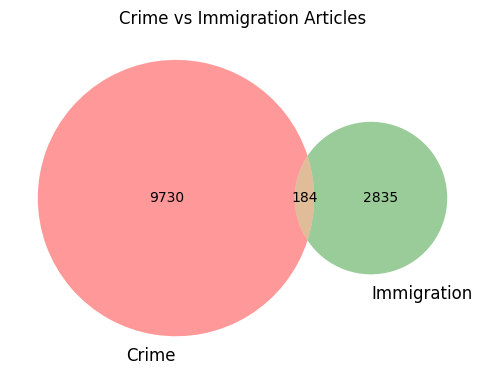

crime = 9914
immigration = 3019
crime only = 9730
immigration only = 2835
both = 184


In [ ]:
# @title
#
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

plt.figure(figsize=(6, 6))
venn2(
    subsets=(len(articles_crime_only), len(articles_immigration_only), len(articles_both)),
    set_labels=("Crime", "Immigration")
)

plt.title("Crime vs Immigration Articles")
plt.show()

print(f"crime = {len(articles_crime)}")
print(f"immigration = {len(articles_immigration)}")
print(f"crime only = {len(articles_crime_only)}")
print(f"immigration only = {len(articles_immigration_only)}")
print(f"both = {len(articles_both)}")

/tmp/ipykernel_49993/31848108.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  crime_only_monthly = crime_only.set_index("Date").resample("M").size()
/tmp/ipykernel_49993/31848108.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  immigration_only_monthly = immigration_only.set_index("Date").resample("M").size()
/tmp/ipykernel_49993/31848108.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  both_monthly = both.set_index("Date").resample("M").size()


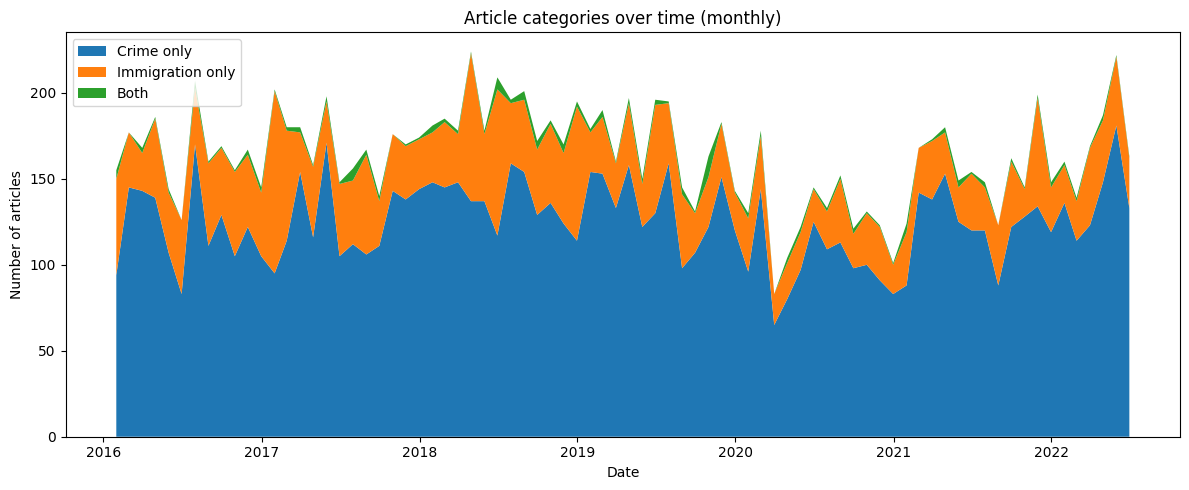

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

articles_classified["Date"] = pd.to_datetime(articles_classified["Date"], errors="coerce")
df = articles_classified.dropna(subset=["Date"]).copy()

crime_only = df[(df["crime_dummy"] == 1) & (df["immigration_dummy"] == 0)]
immigration_only = df[(df["crime_dummy"] == 0) & (df["immigration_dummy"] == 1)]
both = df[(df["crime_dummy"] == 1) & (df["immigration_dummy"] == 1)]

crime_only_monthly = crime_only.set_index("Date").resample("M").size()
immigration_only_monthly = immigration_only.set_index("Date").resample("M").size()
both_monthly = both.set_index("Date").resample("M").size()

plot_df = pd.concat(
    [crime_only_monthly, immigration_only_monthly, both_monthly],
    axis=1
)
plot_df.columns = ["Crime only", "Immigration only", "Both"]
plot_df = plot_df.fillna(0)

plt.figure(figsize=(12, 5))
plt.stackplot(
    plot_df.index,
    plot_df["Crime only"],
    plot_df["Immigration only"],
    plot_df["Both"],
    labels=plot_df.columns
)
plt.xlabel("Date")
plt.ylabel("Number of articles")
plt.title("Article categories over time (monthly)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# **4. BIAS DETECTION**

In [ ]:
import pandas as pd
articles_classified = pd.read_csv('/content/drive/MyDrive/NLP_project/articles_classified_csv')

In [ ]:
articles_crime_only = articles_classified[(articles_classified['crime_dummy'] == 1) & (articles_classified['immigration_dummy']==0)]
articles_immigration_only = articles_classified[(articles_classified['immigration_dummy']==1) & (articles_classified['crime_dummy']==0)]
articles_crime = articles_classified[articles_classified['crime_dummy']==1]
articles_immigration = articles_classified[articles_classified['immigration_dummy']==1]
articles_both = articles_classified[(articles_classified['crime_dummy']==1) & (articles_classified['immigration_dummy']==1)]

In [ ]:
momentary = pd.read_csv("/content/drive/MyDrive/NLP_project/hpc_lemmatization/articles_clean.csv")
momentary = momentary.reset_index().rename(columns={"index": "orig_index"})

In [ ]:
articles_crime_only = articles_crime_only.merge(momentary[["orig_index", "bodyContent"]], on="orig_index", how="left")
articles_immigration_only = articles_immigration_only.merge(momentary[["orig_index", "bodyContent"]], on="orig_index", how="left")
articles_crime = articles_crime.merge(momentary[["orig_index", "bodyContent"]], on="orig_index", how="left")
articles_immigration = articles_immigration.merge(momentary[["orig_index", "bodyContent"]], on="orig_index", how="left")
articles_both = articles_both.merge(momentary[["orig_index", "bodyContent"]], on="orig_index", how="left")


## 1. Jacopo

In [ ]:
import pandas as pd

Articles_for_Electra = pd.read_csv("/content/drive/MyDrive/NLP_project/hpc_lemmatization/articles_clean.csv")


In [ ]:
Articles_16_19 = Articles_for_Electra[Articles_for_Electra['year']<=2019]

In [ ]:

Articles_16_19.to_parquet("/content/drive/MyDrive/NLP_project/ELECTRA_NLI/articles_16_19.parquet", index = False)

In [ ]:
Articles_16_19.columns


Index(['bodyContent', 'Date', 'webTitle', 'sectionName', 'month_start',
       'year_month', 'year', 'month'],
      dtype='object')

In [ ]:
!pip install transformers datasets pandas torch tqdm

In [ ]:
!python /content/drive/MyDrive/NLP_project/ELECTRA_NLI/evaluate_bias_probe.py \
  --model_dir /content/drive/MyDrive/guardian_electra_mnli \
  --input_csv /content/drive/MyDrive/electra_nli_nationality_bias_probe_revised_finnish.csv \
  --output_predictions_csv /content/drive/MyDrive/electra_nli_nationality_bias_probe_predictions.csv \
  --output_metrics_csv /content/drive/MyDrive/electra_nli_nationality_bias_probe_group_metrics.csv \
  --max_length 256 \
  --batch_size 64

In [ ]:
#After observing that the model seldom predicts neutrality, we try to capture absence of bias through a measure of distance between --
#-- the probability that the pair is labelled as entailment and the probability that the pair is labelled as contradiction, namely: --
#-- the group average of the absolute difference between the two probabilities. The lower the distance, the lower the bias.

import pandas as pd

base_path = "/content/drive/MyDrive/NLP_project/ELECTRA_NLI"

pred_path = f"{base_path}/electra_nli_nationality_bias_probe_predictions.csv"
metrics_path = f"{base_path}/electra_nli_nationality_bias_probe_group_metrics.csv"

pred_df = pd.read_csv(pred_path)
metrics_df = pd.read_csv(metrics_path)

avg_dist = (
    pred_df
    .assign(avg_dist_ent_cont_row=(pred_df["p_entailment"] - pred_df["p_contradiction"]).abs())
    .groupby("group", as_index=False)["avg_dist_ent_cont_row"]
    .mean()
    .rename(columns={"avg_dist_ent_cont_row": "avg_dist_ent_cont"})
)

metrics_df = metrics_df.merge(avg_dist, on="group", how="left")

metrics_df.to_csv(metrics_path, index=False)

metrics_df

,group,n_pairs,net_neutral,fraction_neutral,fraction_entailment,fraction_contradiction,threshold_0_5_neutral,threshold_0_7_neutral,threshold_0_5_entailment,threshold_0_7_entailment,avg_dist_ent_cont
0,Balkan,300,0.112487,0.000000,0.676667,0.323333,0.000000,0.0,0.626667,0.156667,0.381426
1,Baltic,150,0.100720,0.000000,0.366667,0.633333,0.000000,0.0,0.253333,0.020000,0.225521
2,Central-Africa,550,0.156820,0.000000,0.409091,0.590909,0.000000,0.0,0.312727,0.067273,0.314665
3,Centre-South-America,850,0.149265,0.005882,0.371765,0.622353,0.000000,0.0,0.290588,0.107059,0.370765
4,East-Asia,250,0.209571,0.000000,0.164000,0.836000,0.000000,0.0,0.112000,0.020000,0.426792
5,East-Europe,450,0.144506,0.020000,0.406667,0.573333,0.000000,0.0,0.364444,0.157778,0.424096
6,MDW,900,0.182231,0.095556,0.528889,0.375556,0.021111,0.0,0.425556,0.148889,0.337688
7,North-Africa,200,0.133730,0.000000,0.160000,0.840000,0.000000,0.0,0.105000,0.040000,0.401880
8,South-Asia,200,0.167837,0.030000,0.515000,0.455000,0.000000,0.0,0.470000,0.350000,0.437423
9,South-West-Asia,450,0.279642,0.064444,0.133333,0.802222,0.008889,0.0,0.044444,0.011111,0.372218


## 2. Federico

In [ ]:
# 1) Install / load spaCy
import re
import numpy as np
import pandas as pd
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
# 2) Example input dataframe
# df = your_dataframe.copy()

In [ ]:
# @title
NATIONALITY_WORDS = {
    "afghan", "albanian", "algerian", "american", "argentine", "armenian",
    "australian", "austrian", "azerbaijani", "bangladeshi", "belgian",
    "bolivian", "bosnian", "brazilian", "british", "bulgarian",
    "cambodian", "cameroonian", "canadian", "chilean", "chinese",
    "colombian", "croatian", "cuban", "czech", "danish", "dominican",
    "dutch", "ecuadorean", "egyptian", "english", "eritrean", "estonian",
    "ethiopian", "european", "filipino", "finnish", "flemish", "french",
    "georgian", "german", "ghanaian", "greek", "guatemalan", "haitian",
    "hungarian", "icelandic", "indian", "indonesian", "iranian", "iraqi",
    "irish", "israeli", "italian", "jamaican", "japanese", "jordanian",
    "kazakh", "kenyan", "korean", "kurdish", "kuwaiti", "latvian",
    "lebanese", "liberian", "libyan", "lithuanian", "macedonian",
    "malaysian", "malian", "mexican", "moldovan", "mongolian",
    "moroccan", "nepali", "nigerian", "norwegian", "pakistani",
    "palestinian", "peruvian", "polish", "portuguese", "romanian",
    "russian", "rwandan", "saudi", "scottish", "senegalese", "serbian",
    "sierra leonean", "singaporean", "slovak", "slovenian", "somali",
    "south african", "spanish", "sri lankan", "sudanese", "swedish",
    "swiss", "syrian", "taiwanese", "tajik", "tanzanian", "thai",
    "tunisian", "turkish", "ugandan", "ukrainian", "uruguayan",
    "uzbek", "venezuelan", "vietnamese", "welsh", "yemeni", "zambian",
    "zimbabwean"
}

COUNTRY_OR_REGION_WORDS = {
    "afghanistan", "africa", "albania", "algeria", "america", "argentina",
    "armenia", "asia", "australia", "austria", "azerbaijan", "bangladesh",
    "belgium", "bolivia", "bosnia", "brazil", "britain", "bulgaria",
    "cambodia", "cameroon", "canada", "caribbean", "chile", "china",
    "colombia", "croatia", "cuba", "czech republic", "denmark",
    "dominican republic", "dutchland", "ecuador", "egypt", "england",
    "eritrea", "estonia", "ethiopia", "europe", "finland", "france",
    "gambia", "georgia", "germany", "ghana", "greece", "guatemala",
    "haiti", "holland", "hungary", "iceland", "india", "indonesia",
    "iran", "iraq", "ireland", "israel", "italy", "jamaica", "japan",
    "jordan", "kazakhstan", "kenya", "kosovo", "korea", "kurdistan",
    "kuwait", "latvia", "lebanon", "liberia", "libya", "lithuania",
    "macedonia", "malaysia", "mali", "mexico", "middle east", "moldova",
    "mongolia", "morocco", "nepal", "netherlands", "nigeria", "norway",
    "pakistan", "palestine", "peru", "poland", "portugal", "romania",
    "russia", "rwanda", "saudi arabia", "scotland", "senegal", "serbia",
    "sierra leone", "singapore", "slovakia", "slovenia", "somalia",
    "south africa", "south america", "south asia", "spain", "sri lanka",
    "sudan", "sweden", "switzerland", "syria", "taiwan", "tajikistan",
    "tanzania", "thailand", "tunisia", "turkey", "uganda", "uk",
    "ukraine", "united kingdom", "united states", "usa", "uruguay",
    "uzbekistan", "venezuela", "vietnam", "wales", "yemen", "zambia",
    "zimbabwe"
}

In [ ]:
# @title
SUSPECT_TERMS = {"suspect", "attacker", "assailant", "perpetrator", "offender", "criminal", "culprit",
                 "killer", "murderer", "rapist", "abuser", "gunman", "shooter", "stabber", "robber",
                 "burglar", "thief", "mugger", "kidnapper", "abductor", "arsonist", "fraudster", "dealer",
                 "smuggler", "accused", "defendant", "convict", "prisoner", "inmate", "fugitive"}

VICTIM_TERMS = {"victim", "target", "survivor", "casualty", "deceased", "dead", "injured", "wounded", "hostage"}

In [ ]:
# @title
# 4) Helper functions
def sentence_boundaries_from_doc(doc):
    # Return sentence boundaries as token index pairs: (start_token, end_token).
    return [(sent.start, sent.end) for sent in doc.sents]

def find_nationality_mentions(doc):
    # Find mentions of nationality /origin. We use:
    # 1) spaCy entities: NORP (Nationalities, Religious groups or Political groups) and GPE (Geo-Political Entity);
    # 2) other 2 sets of words as safety in case some entities are not recognised
    # For each article we return a list, with a dictionary for every entity or word of interested detected.
    mentions = []

    PERSON_LINK_WORDS = {"man", "woman", "boy", "girl", "person", "people", "suspect", "victim", "attacker", "assailant", "defendant", "migrant", "immigrant", "refugee", "national"}

    # Entity-based matches
    for ent in doc.ents:
        if ent.label_ == "NORP":
            mentions.append({
                "start": ent.start,
                "end": ent.end,
                "text": ent.text,
                "label": ent.label_
            })

        elif ent.label_ == "GPE":
            keep_gpe = False

            if ent.end < len(doc):
                next_token = doc[ent.end]
                if next_token.lemma_.lower() in PERSON_LINK_WORDS or next_token.text.lower() in PERSON_LINK_WORDS:
                    keep_gpe = True

            if keep_gpe:
                mentions.append({
                    "start": ent.start,
                    "end": ent.end,
                    "text": ent.text,
                    "label": ent.label_
                })

    # Lexicon-based matches
    for token in doc:
        low = token.text.lower()
        if low in NATIONALITY_WORDS or low in COUNTRY_OR_REGION_WORDS:
            mentions.append({
                "start": token.i,
                "end": token.i + 1,
                "text": token.text,
                "label": "LEXICON_NATIONALITY"
            })

    # Remove exact duplicates
    seen = set()
    uniq = []
    for m in mentions:
        key = (m["start"], m["end"], m["text"].lower(), m["label"])
        if key not in seen:
            seen.add(key)
            uniq.append(m)
    return uniq

def expand_np_head(token):
    # Helper:expand one token to its rough noun phrase using the subtree.
    # Example: "suspect" -> "the main suspect"
    subtree = list(token.subtree)
    if not subtree:
        return (token.i, token.i + 1)
    return (min(t.i for t in subtree), max(t.i for t in subtree) + 1)

def get_np_span_dict(doc, token, label):
    # Helper: take a token, expand it to a noun phrase, and return it as a dictionary.
    start, end = expand_np_head(token)
    span = doc[start:end]
    return {
        "start": start,
        "end": end,
        "text": span.text,
        "label": label
    }

def guess_suspect_mentions(doc):
    # Find suspect mentions with two simple rules:
    # 1) explicit suspect words
    # 2) nouns / names / pronouns linked to crime verbs,
    #    with verb-specific dependency roles
    mentions = []

    SUSPECT_DEP_RULES = {
        "kill": {"nsubj"},
        "stab": {"nsubj"},
        "shoot": {"nsubj"},
        "rob": {"nsubj"},
        "assault": {"nsubj"},
        "abduct": {"nsubj"},
        "kidnap": {"nsubj"},
        "injure": {"nsubj"},
        "strangle": {"nsubj"},
        "rape": {"nsubj"},
        "attack": {"nsubj"},
        "murder": {"nsubj"},
        "burgle": {"nsubj"},
        "steal": {"nsubj"},
        "arrest": {"dobj", "nsubjpass"},
        "charge": {"dobj", "nsubjpass"},
        "accuse": {"dobj", "nsubjpass"},
        "convict": {"dobj", "nsubjpass"},
        "detain": {"dobj", "nsubjpass"},
        "sentence": {"dobj", "nsubjpass"},
        "prosecute": {"dobj", "nsubjpass"},
    }

    for token in doc:
        low_lemma = token.lemma_.lower()
        low_text = token.text.lower()

        # Explicit suspect words
        if low_lemma in SUSPECT_TERMS or low_text in SUSPECT_TERMS:
            mentions.append(get_np_span_dict(doc, token, "suspect_explicit"))
            continue

        # Syntactic guess based on crime-related verbs
        if token.pos_ in {"NOUN", "PROPN", "PRON"}:
            head_lemma = token.head.lemma_.lower()

            if (head_lemma in SUSPECT_DEP_RULES and token.dep_ in SUSPECT_DEP_RULES[head_lemma]):
                mentions.append(get_np_span_dict(doc, token, "suspect_syntactic"))

    # Remove exact duplicates
    seen = set()
    uniq = []
    for m in mentions:
        key = (m["start"], m["end"], m["text"].lower(), m["label"])
        if key not in seen:
            seen.add(key)
            uniq.append(m)
    return uniq

def guess_victim_mentions(doc):
    # Find victim mentions with two simple rules:
    # 1) explicit victim words
    # 2) nouns / names / pronouns linked to crime verbs
    mentions = []

    VICTIM_DEP_RULES = {
        "kill": {"dobj", "nsubjpass"},
        "stab": {"dobj", "nsubjpass"},
        "shoot": {"dobj", "nsubjpass"},
        "rob": {"dobj", "nsubjpass"},
        "assault": {"dobj", "nsubjpass"},
        "rape": {"dobj", "nsubjpass"},
        "attack": {"dobj", "nsubjpass"},
        "injure": {"dobj", "nsubjpass"},
        "murder": {"dobj", "nsubjpass"},
        "target": {"dobj", "nsubjpass"},
        "strangle": {"dobj", "nsubjpass"},
        "abduct": {"dobj", "nsubjpass"},
        "kidnap": {"dobj", "nsubjpass"}
    }

    for token in doc:
        low_lemma = token.lemma_.lower()
        low_text = token.text.lower()

        # Explicit victim words
        if low_lemma in VICTIM_TERMS or low_text in VICTIM_TERMS:
            mentions.append(get_np_span_dict(doc, token, "victim_explicit"))
            continue

        # Syntactic guess based on crime-related verbs
        if token.pos_ in {"NOUN", "PROPN", "PRON"}:
            head_lemma = token.head.lemma_.lower()

            if (head_lemma in VICTIM_DEP_RULES and token.dep_ in VICTIM_DEP_RULES[head_lemma]):
                mentions.append(get_np_span_dict(doc, token, "victim_syntactic"))

    # Remove exact duplicates
    seen = set()
    uniq = []
    for m in mentions:
        key = (m["start"], m["end"], m["text"].lower(), m["label"])
        if key not in seen:
            seen.add(key)
            uniq.append(m)
    return uniq

def spans_overlap(a_start, a_end, b_start, b_end):
    # Helper:
    # check whether two token spans overlap.
    return max(a_start, b_start) < min(a_end, b_end)

def same_sentence(doc, a_start, b_start):
    # Helper:
    # check whether two tokens are in the same sentence.
    return doc[a_start].sent.start == doc[b_start].sent.start

def nationality_attached_count(doc, nationality_mentions, role_mentions, window=6):
    # Count nationality mentions that seem attached
    # to a suspect or victim mention.
    #
    # A match is counted if the two mentions:
    # 1) are in the same sentence, and
    # 2) are in the same noun phrase span, or have a close modifier/apposition relation
    count = 0
    matched_pairs = []

    for nat in nationality_mentions:
        nat_root = doc[nat["start"]]
        matched = False

        for role in role_mentions:
            role_root = doc[role["start"]]

            # Only compare mentions in the same sentence
            if not same_sentence(doc, nat["start"], role["start"]):
                continue

            # Nationality mention inside role mention span
            nat_inside_role = role["start"] <= nat["start"] and nat["end"] <= role["end"]

            # Same span area
            overlap = spans_overlap(nat["start"], nat["end"], role["start"], role["end"])

            # Nationality directly modifies the role head
            direct_modifier = nat_root.head == role_root and nat_root.dep_ in {"amod", "compound", "appos"}

            # Role head directly depends on nationality token in apposition
            reverse_link = role_root.head == nat_root and role_root.dep_ == "appos"

            # Shared head in apposition-like structure
            shared_appos_head = nat_root.head == role_root.head and nat_root.dep_ == "appos"

            # If one strong rule is true, count the match
            if nat_inside_role or overlap or direct_modifier or reverse_link or shared_appos_head:
                matched = True
                matched_pairs.append({
                    "nationality_text": nat["text"],
                    "role_text": role["text"],
                    "sentence": nat_root.sent.text
                })
                break

        # Count each nationality mention at most once
        if matched:
            count += 1

    return count, matched_pairs

In [ ]:
# @title
# 5) Per-article feature extraction

def extract_article_bias_features(row):
  text = row["bodyContent"]
  if not text.strip():
        return {
            "sentence_boundaries": [],
            "nationality_mentions": [],
            "suspect_mentions": [],
            "victim_mentions": [],
            "num_suspect_mentions": 0,
            "num_victim_mentions": 0,
            "nationality_attached_to_suspect_count": 0,
            "nationality_attached_to_victim_count": 0,
            "nationality_attached_to_suspect_score": np.nan,
            "nationality_attached_to_victim_score": np.nan,
            "has_nat_on_suspect": 0,
            "has_nat_on_victim": 0,
        }
  doc = nlp(text)

  sentence_boundaries = sentence_boundaries_from_doc(doc) # Returns list of tuples with beginning and end of each sentence
  nationality_mentions = find_nationality_mentions(doc)   # Returns list of dictionaries with basic info about each nationality detected
  suspect_mentions = guess_suspect_mentions(doc)          # Returns list of dictionaries with basic info about each suspect detected
  victim_mentions = guess_victim_mentions(doc)            # Returns list of dictionaries with basic info about each victim detected

  num_suspect_mentions = len(suspect_mentions)
  num_victim_mentions = len(victim_mentions)

  nationality_attached_to_suspect_count, suspect_pairs = nationality_attached_count(
      doc, nationality_mentions, suspect_mentions, window=6
  )

  nationality_attached_to_victim_count, victim_pairs = nationality_attached_count(
      doc, nationality_mentions, victim_mentions, window=6
  )

  has_nat_on_suspect = 1 if nationality_attached_to_suspect_count > 0 else 0
  has_nat_on_victim = 1 if nationality_attached_to_victim_count > 0 else 0

  nationality_attached_to_suspect_score = (
      nationality_attached_to_suspect_count / num_suspect_mentions
      if num_suspect_mentions > 0 else np.nan
  )
  nationality_attached_to_victim_score = (
      nationality_attached_to_victim_count / num_victim_mentions
      if num_victim_mentions > 0 else np.nan
  )

  return {
      "sentence_boundaries": sentence_boundaries,
      "nationality_mentions": nationality_mentions,
      "suspect_mentions": suspect_mentions,
      "victim_mentions": victim_mentions,
      "num_suspect_mentions": num_suspect_mentions,
      "num_victim_mentions": num_victim_mentions,
      "nationality_attached_to_suspect_count": nationality_attached_to_suspect_count,
      "nationality_attached_to_victim_count": nationality_attached_to_victim_count,
      "nationality_attached_to_suspect_score": nationality_attached_to_suspect_score,
      "nationality_attached_to_victim_score": nationality_attached_to_victim_score,
      "has_nat_on_suspect": has_nat_on_suspect,
      "has_nat_on_victim": has_nat_on_victim,
      "suspect_pairs_debug": suspect_pairs,
      "victim_pairs_debug": victim_pairs,
  }

This cell would take more than 10 minutes to run, so, to avoid unecessary waiting, we ran the

In [ ]:
# 6) Run on dataframe
# Optional: first restrict to crime articles only
# crime_df = df[df["crime"] == 1].copy()


feature_rows = []
for _, row in articles_both.iterrows():
    feats = extract_article_bias_features(row)
    feature_rows.append(feats)

feature_df = pd.DataFrame(feature_rows)
articles_crime_bias = pd.concat([articles_both.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

articles_crime_bias.head()

,orig_index,Date,webTitle,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score,...,num_suspect_mentions,num_victim_mentions,nationality_attached_to_suspect_count,nationality_attached_to_victim_count,nationality_attached_to_suspect_score,nationality_attached_to_victim_score,has_nat_on_suspect,has_nat_on_victim,suspect_pairs_debug,victim_pairs_debug
0,86,2016-01-31,Teenage girl admits making up migrant rape cla...,World news,0.018692,0.006231,0.995318,0.950411,0.727875,0.768543,...,1,1,0,0,0.0,0.0,0,0,[],[]
1,279,2016-01-30,"10,000 refugee children are missing, says Europol",World news,0.019563,0.025316,0.691289,0.989511,0.737625,0.766466,...,9,5,0,2,0.0,0.4,0,1,[],"[{'nationality_text': 'pan-European', 'role_te..."
2,333,2016-01-30,Masked men in Stockholm threaten to 'punish' r...,World news,0.040816,0.020408,0.979668,0.674426,0.712080,0.735806,...,3,5,0,0,0.0,0.0,0,0,[],[]
3,835,2016-01-28,Guatemalan migrant sent to same US detention f...,US news,0.015538,0.013319,0.824179,0.998633,0.721075,0.749716,...,5,0,0,0,0.0,NaN,0,0,[],[]
4,962,2016-01-28,'Affluenza' teenager Ethan Couch flown back to...,US news,0.034602,0.013841,0.970465,0.971347,0.682163,0.708753,...,4,1,0,0,0.0,0.0,0,0,[],[]


In [ ]:
# @title
# 7) Aggregate comparisons

# A) Among crime articles, compare articles with immigration=1 vs immigration=0
summary_by_immigration = (
    articles_crime_bias
    .groupby("immigration_dummy")
    .agg(
        n_articles=("orig_index", "count"),
        mean_suspect_score=("nationality_attached_to_suspect_score", "mean"),
        mean_victim_score=("nationality_attached_to_victim_score", "mean"),
        mean_suspect_count=("nationality_attached_to_suspect_count", "mean"),
        mean_victim_count=("nationality_attached_to_victim_count", "mean"),
        share_with_nat_on_suspect=("has_nat_on_suspect", "mean"),
        share_with_nat_on_victim=("has_nat_on_victim", "mean"),
    )
    .reset_index()
)

summary_by_immigration

,immigration_dummy,n_articles,mean_suspect_score,mean_victim_score,mean_suspect_count,mean_victim_count,share_with_nat_on_suspect,share_with_nat_on_victim
0,1,184,0.174533,0.081671,0.755435,0.179348,0.288043,0.081522


In [ ]:
# B) Simple article-level difference: suspect score minus victim score
articles_crime_bias["suspect_minus_victim_score"] = (                         ####
    articles_crime_bias["nationality_attached_to_suspect_score"]              ####
    - articles_crime_bias["nationality_attached_to_victim_score"]             ###
)

bias_gap_summary = (
    articles_crime_bias
    .groupby("immigration_dummy")
    .agg(
        n_articles=("orig_index", "count"),
        mean_gap=("suspect_minus_victim_score", "mean"),
        median_gap=("suspect_minus_victim_score", "median")
    )
    .reset_index()
)

bias_gap_summary

,immigration_dummy,n_articles,mean_gap,median_gap
0,1,184,0.081619,0.0


It doesnt finish in Collab, so we have run it on HPC and these are the results

In [ ]:
import pandas as pd
summary_by_immigration = pd.read_csv('/content/drive/MyDrive/NLP_project/summary_by_immigration.csv')
summary_by_immigration

,immigration_dummy,n_articles,mean_suspect_score,mean_victim_score,mean_suspect_count,mean_victim_count,share_with_nat_on_suspect,share_with_nat_on_victim
0,1,184,0.174533,0.081671,0.755435,0.179348,0.288043,0.081522


In [ ]:
bias_gap_summary = pd.read_csv('/content/drive/MyDrive/NLP_project/bias_gap_summary.csv')
bias_gap_summary

,immigration_dummy,n_articles,mean_gap,median_gap
0,1,184,0.081619,0.0


In [ ]:
articles_crime_bias = pd.read_parquet('/content/drive/MyDrive/NLP_project/articles_crime_bias.parquet')
articles_crime_bias.head()

,orig_index,Date,webTitle,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score,...,num_victim_mentions,nationality_attached_to_suspect_count,nationality_attached_to_victim_count,nationality_attached_to_suspect_score,nationality_attached_to_victim_score,has_nat_on_suspect,has_nat_on_victim,suspect_pairs_debug,victim_pairs_debug,suspect_minus_victim_score
0,86,2016-01-31,Teenage girl admits making up migrant rape cla...,World news,0.018692,0.006231,0.995318,0.950411,0.727875,0.768543,...,1,0,0,0.0,0.0,0,0,[],[],0.0
1,279,2016-01-30,"10,000 refugee children are missing, says Europol",World news,0.019563,0.025316,0.691289,0.989511,0.737625,0.766466,...,5,0,2,0.0,0.4,0,1,[],"[{'nationality_text': 'pan-European', 'role_te...",-0.4
2,333,2016-01-30,Masked men in Stockholm threaten to 'punish' r...,World news,0.040816,0.020408,0.979668,0.674426,0.712080,0.735806,...,5,0,0,0.0,0.0,0,0,[],[],0.0
3,835,2016-01-28,Guatemalan migrant sent to same US detention f...,US news,0.015538,0.013319,0.824179,0.998633,0.721075,0.749716,...,0,0,0,0.0,NaN,0,0,[],[],NaN
4,962,2016-01-28,'Affluenza' teenager Ethan Couch flown back to...,US news,0.034602,0.013841,0.970465,0.971347,0.682163,0.708753,...,1,0,0,0.0,0.0,0,0,[],[],0.0


_______________________________________________________________________________

In [ ]:
# @title
# 8) Optional: inspect a few rows manually

cols_to_show = [
    "orig_index", "webTitle", "crime", "immigration",
    "num_suspect_mentions", "num_victim_mentions",
    "nationality_attached_to_suspect_count",
    "nationality_attached_to_victim_count",
    "nationality_attached_to_suspect_score",
    "nationality_attached_to_victim_score",
    "suspect_pairs_debug", "victim_pairs_debug"
]

crime_bias_df[cols_to_show].head(10)

KeyError: "['crime', 'immigration'] not in index"

In [ ]:
# 9) Save results

output_path = "/content/drive/MyDrive/NLP_project/crime_bias_features.parquet"
crime_bias_df.to_parquet(output_path, index=False)
print(f"Saved to: {output_path}")

# Old version

In [ ]:
# 1) Install / load spaCy
import re
import numpy as np
import pandas as pd
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
# 2) Example input dataframe
# df = your_dataframe.copy()

In [ ]:
# @title
NATIONALITY_WORDS = {
    "afghan", "albanian", "algerian", "american", "argentine", "armenian",
    "australian", "austrian", "azerbaijani", "bangladeshi", "belgian",
    "bolivian", "bosnian", "brazilian", "british", "bulgarian",
    "cambodian", "cameroonian", "canadian", "chilean", "chinese",
    "colombian", "croatian", "cuban", "czech", "danish", "dominican",
    "dutch", "ecuadorean", "egyptian", "english", "eritrean", "estonian",
    "ethiopian", "european", "filipino", "finnish", "flemish", "french",
    "georgian", "german", "ghanaian", "greek", "guatemalan", "haitian",
    "hungarian", "icelandic", "indian", "indonesian", "iranian", "iraqi",
    "irish", "israeli", "italian", "jamaican", "japanese", "jordanian",
    "kazakh", "kenyan", "korean", "kurdish", "kuwaiti", "latvian",
    "lebanese", "liberian", "libyan", "lithuanian", "macedonian",
    "malaysian", "malian", "mexican", "moldovan", "mongolian",
    "moroccan", "nepali", "nigerian", "norwegian", "pakistani",
    "palestinian", "peruvian", "polish", "portuguese", "romanian",
    "russian", "rwandan", "saudi", "scottish", "senegalese", "serbian",
    "sierra leonean", "singaporean", "slovak", "slovenian", "somali",
    "south african", "spanish", "sri lankan", "sudanese", "swedish",
    "swiss", "syrian", "taiwanese", "tajik", "tanzanian", "thai",
    "tunisian", "turkish", "ugandan", "ukrainian", "uruguayan",
    "uzbek", "venezuelan", "vietnamese", "welsh", "yemeni", "zambian",
    "zimbabwean"
}

COUNTRY_OR_REGION_WORDS = {
    "afghanistan", "africa", "albania", "algeria", "america", "argentina",
    "armenia", "asia", "australia", "austria", "azerbaijan", "bangladesh",
    "belgium", "bolivia", "bosnia", "brazil", "britain", "bulgaria",
    "cambodia", "cameroon", "canada", "caribbean", "chile", "china",
    "colombia", "croatia", "cuba", "czech republic", "denmark",
    "dominican republic", "dutchland", "ecuador", "egypt", "england",
    "eritrea", "estonia", "ethiopia", "europe", "finland", "france",
    "gambia", "georgia", "germany", "ghana", "greece", "guatemala",
    "haiti", "holland", "hungary", "iceland", "india", "indonesia",
    "iran", "iraq", "ireland", "israel", "italy", "jamaica", "japan",
    "jordan", "kazakhstan", "kenya", "kosovo", "korea", "kurdistan",
    "kuwait", "latvia", "lebanon", "liberia", "libya", "lithuania",
    "macedonia", "malaysia", "mali", "mexico", "middle east", "moldova",
    "mongolia", "morocco", "nepal", "netherlands", "nigeria", "norway",
    "pakistan", "palestine", "peru", "poland", "portugal", "romania",
    "russia", "rwanda", "saudi arabia", "scotland", "senegal", "serbia",
    "sierra leone", "singapore", "slovakia", "slovenia", "somalia",
    "south africa", "south america", "south asia", "spain", "sri lanka",
    "sudan", "sweden", "switzerland", "syria", "taiwan", "tajikistan",
    "tanzania", "thailand", "tunisia", "turkey", "uganda", "uk",
    "ukraine", "united kingdom", "united states", "usa", "uruguay",
    "uzbekistan", "venezuela", "vietnam", "wales", "yemen", "zambia",
    "zimbabwe"
}

In [ ]:
# @title
SUSPECT_TERMS = {"suspect", "attacker", "assailant", "perpetrator", "offender", "criminal", "culprit",
                 "killer", "murderer", "rapist", "abuser", "gunman", "shooter", "stabber", "robber",
                 "burglar", "thief", "mugger", "kidnapper", "abductor", "arsonist", "fraudster", "dealer",
                 "smuggler", "accused", "defendant", "convict", "prisoner", "inmate", "fugitive"}

VICTIM_TERMS = {"victim", "target", "survivor", "casualty", "deceased", "dead", "injured", "wounded", "hostage"}

In [ ]:
# @title
# 4) Helper functions
def sentence_boundaries_from_doc(doc):
    # Return sentence boundaries as token index pairs: (start_token, end_token).
    return [(sent.start, sent.end) for sent in doc.sents]

def find_nationality_mentions(doc):
    # Find mentions of nationality /origin. We use:
    # 1) spaCy entities: NORP (Nationalities, Religious groups or Political groups) and GPE (Geo-Political Entity);
    # 2) other 2 sets of words as safety in case some entities are not recognised
    # For each article we return a list, with a dictionary for every entity or word of itnerested detected.
    mentions = []

    # Entity-based matches
    for ent in doc.ents:
        if ent.label_ in {"NORP", "GPE"}:
            mentions.append({
                "start": ent.start,
                "end": ent.end,
                "text": ent.text,
                "label": ent.label_
            })

    # Lexicon-based matches
    for token in doc:
        low = token.text.lower()
        if low in NATIONALITY_WORDS or low in COUNTRY_OR_REGION_WORDS:
            mentions.append({
                "start": token.i,
                "end": token.i + 1,
                "text": token.text,
                "label": "LEXICON_NATIONALITY"
            })

    # Remove exact duplicates
    seen = set()
    uniq = []
    for m in mentions:
        key = (m["start"], m["end"], m["text"].lower(), m["label"])
        if key not in seen:
            seen.add(key)
            uniq.append(m)
    return uniq

def expand_np_head(token):
    # Helper:expand one token to its rough noun phrase using the subtree.
    # Example: "suspect" -> "the main suspect"
    subtree = list(token.subtree)
    if not subtree:
        return (token.i, token.i + 1)
    return (min(t.i for t in subtree), max(t.i for t in subtree) + 1)

def get_np_span_dict(doc, token, label):
    # Helper: take a token, expand it to a noun phrase, and return it as a dictionary.
    start, end = expand_np_head(token)
    span = doc[start:end]
    return {
        "start": start,
        "end": end,
        "text": span.text,
        "label": label
    }

def guess_suspect_mentions(doc):
    # Find suspect mentions with two simple rules:
    # 1) explicit suspect words
    # 2) nouns / names / pronouns linked to crime verbs,
    #    with verb-specific dependency roles
    mentions = []

    SUSPECT_DEP_RULES = {
        "kill": {"nsubj"},
        "stab": {"nsubj"},
        "shoot": {"nsubj"},
        "rob": {"nsubj"},
        "assault": {"nsubj"},
        "abduct": {"nsubj"},
        "kidnap": {"nsubj"},
        "injure": {"nsubj"},
        "strangle": {"nsubj"},
        "rape": {"nsubj"},
        "attack": {"nsubj"},
        "murder": {"nsubj"},
        "burgle": {"nsubj"},
        "steal": {"nsubj"},
        "arrest": {"dobj", "nsubjpass"},
        "charge": {"dobj", "nsubjpass"},
        "accuse": {"dobj", "nsubjpass"},
        "convict": {"dobj", "nsubjpass"},
        "detain": {"dobj", "nsubjpass"},
        "sentence": {"dobj", "nsubjpass"},
        "prosecute": {"dobj", "nsubjpass"},
    }

    for token in doc:
        low_lemma = token.lemma_.lower()
        low_text = token.text.lower()

        # Explicit suspect words
        if low_lemma in SUSPECT_TERMS or low_text in SUSPECT_TERMS:
            mentions.append(get_np_span_dict(doc, token, "suspect_explicit"))
            continue

        # Syntactic guess based on crime-related verbs
        if token.pos_ in {"NOUN", "PROPN", "PRON"}:
            head_lemma = token.head.lemma_.lower()

            if (head_lemma in SUSPECT_DEP_RULES and token.dep_ in SUSPECT_DEP_RULES[head_lemma]):
                mentions.append(get_np_span_dict(doc, token, "suspect_syntactic"))

    # Remove exact duplicates
    seen = set()
    uniq = []
    for m in mentions:
        key = (m["start"], m["end"], m["text"].lower(), m["label"])
        if key not in seen:
            seen.add(key)
            uniq.append(m)
    return uniq

def guess_victim_mentions(doc):
    # Find victim mentions with two simple rules:
    # 1) explicit victim words
    # 2) nouns / names / pronouns linked to crime verbs
    mentions = []

    for token in doc:
        low_lemma = token.lemma_.lower()
        low_text = token.text.lower()

        # Explicit victim words
        if low_lemma in VICTIM_TERMS or low_text in VICTIM_TERMS:
            mentions.append(get_np_span_dict(doc, token, "victim_explicit"))
            continue

        # Syntactic guess based on crime-related verbs
        if token.pos_ in {"NOUN", "PROPN", "PRON"}:
            crimey_head = token.head.lemma_.lower() in {
                "kill", "stab", "shoot", "rob", "assault", "rape",
                "attack", "injure", "murder", "target", "strangle", "abduct", "kidnap"
            }
            if crimey_head and token.dep_ in {"dobj", "nsubjpass"}:
                mentions.append(get_np_span_dict(doc, token, "victim_syntactic"))

    # Remove exact duplicates
    seen = set()
    uniq = []
    for m in mentions:
        key = (m["start"], m["end"], m["text"].lower(), m["label"])
        if key not in seen:
            seen.add(key)
            uniq.append(m)
    return uniq

def spans_overlap(a_start, a_end, b_start, b_end):
    # Helper:
    # check whether two token spans overlap.
    return max(a_start, b_start) < min(a_end, b_end)

def same_sentence(doc, a_start, b_start):
    # Helper:
    # check whether two tokens are in the same sentence.
    return doc[a_start].sent.start == doc[b_start].sent.start

def nationality_attached_count(doc, nationality_mentions, role_mentions, window=6):
    # Count nationality mentions that seem attached
    # to a suspect or victim mention.
    #
    # A match is counted if the two mentions:
    # 1) are in the same sentence, and
    # 2) overlap, or are close, or are close in the dependency tree
    count = 0
    matched_pairs = []

    for nat in nationality_mentions:
        nat_root = doc[nat["start"]]
        matched = False

        for role in role_mentions:
            role_root = doc[role["start"]]

            # Only compare mentions in the same sentence
            if not same_sentence(doc, nat["start"], role["start"]):
                continue

            # Same span area
            overlap = spans_overlap(nat["start"], nat["end"], role["start"], role["end"])

            # Close in surface distance
            near = abs(nat_root.i - role_root.i) <= window

            # Close in dependency structure
            dep_close = (
                nat_root.head == role_root
                or role_root.head == nat_root
                or nat_root.head == role_root.head
            )

            # If one rule is true, count the match
            if overlap or near or dep_close:
                matched = True
                matched_pairs.append({
                    "nationality_text": nat["text"],
                    "role_text": role["text"],
                    "sentence": nat_root.sent.text
                })
                break

        # Count each nationality mention at most once
        if matched:
            count += 1

    return count, matched_pairs

In [ ]:
# @title
# 5) Per-article feature extraction

def extract_article_bias_features(row):
  text = row["bodyContent"]
  if not text.strip():
        return {
            "sentence_boundaries": [],
            "nationality_mentions": [],
            "suspect_mentions": [],
            "victim_mentions": [],
            "num_suspect_mentions": 0,
            "num_victim_mentions": 0,
            "nationality_attached_to_suspect_count": 0,
            "nationality_attached_to_victim_count": 0,
            "nationality_attached_to_suspect_score": 0.0,
            "nationality_attached_to_victim_score": 0.0,
        }
  doc = nlp(text)

  sentence_boundaries = sentence_boundaries_from_doc(doc) # Returns list of tuples with beginning and end of each sentence
  nationality_mentions = find_nationality_mentions(doc)   # Returns list of dictionaries with basic info about each nationality detected
  suspect_mentions = guess_suspect_mentions(doc)          # Returns list of dictionaries with basic info about each suspect detected
  victim_mentions = guess_victim_mentions(doc)            # Returns list of dictionaries with basic info about each victim detected

  num_suspect_mentions = len(suspect_mentions)
  num_victim_mentions = len(victim_mentions)

  nationality_attached_to_suspect_count, suspect_pairs = nationality_attached_count(
      doc, nationality_mentions, suspect_mentions, window=6
  )

  nationality_attached_to_victim_count, victim_pairs = nationality_attached_count(
      doc, nationality_mentions, victim_mentions, window=6
  )

  nationality_attached_to_suspect_score = nationality_attached_to_suspect_count / max(1, num_suspect_mentions)
  nationality_attached_to_victim_score = nationality_attached_to_victim_count / max(1, num_victim_mentions)

  return {
      "sentence_boundaries": sentence_boundaries,
      "nationality_mentions": nationality_mentions,
      "suspect_mentions": suspect_mentions,
      "victim_mentions": victim_mentions,
      "num_suspect_mentions": num_suspect_mentions,
      "num_victim_mentions": num_victim_mentions,
      "nationality_attached_to_suspect_count": nationality_attached_to_suspect_count,
      "nationality_attached_to_victim_count": nationality_attached_to_victim_count,
      "nationality_attached_to_suspect_score": nationality_attached_to_suspect_score,
      "nationality_attached_to_victim_score": nationality_attached_to_victim_score,
      "suspect_pairs_debug": suspect_pairs,
      "victim_pairs_debug": victim_pairs,
  }

This cell would take more than 10 minutes to run, so, to avoid unecessary waiting, we ran the

In [ ]:
# 6) Run on dataframe
# Optional: first restrict to crime articles only
# crime_df = df[df["crime"] == 1].copy()


feature_rows = []
for _, row in articles_crime.iterrows():
    feats = extract_article_bias_features(row)
    feature_rows.append(feats)

feature_df = pd.DataFrame(feature_rows)
articles_crime_bias = pd.concat([articles_crime.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

articles_crime_bias.head()

,orig_index,Date,webTitle,sectionName,crime_score,immigration_score,zs_crime_score,zs_immigration_score,crime_embed_score,immigration_embed_score,...,suspect_mentions,victim_mentions,num_suspect_mentions,num_victim_mentions,nationality_attached_to_suspect_count,nationality_attached_to_victim_count,nationality_attached_to_suspect_score,nationality_attached_to_victim_score,suspect_pairs_debug,victim_pairs_debug
0,2,2016-01-31,British pilot in Tanzania 'manoeuvred ​to save...,World news,0.007622,0.000000,0.985608,0.000038,0.720391,0.728569,...,"[{'start': 90, 'end': 115, 'text': 'gunmen who...","[{'start': 3, 'end': 4, 'text': 'who', 'label'...",8,17,3,2,0.375,0.117647,"[{'nationality_text': 'Tanzanian', 'role_text'...","[{'nationality_text': 'British', 'role_text': ..."
1,31,2016-01-31,Barclays and Credit Suisse pay biggest ever fi...,Business,0.001961,0.000000,0.977197,0.000017,0.686059,0.685925,...,[],[],0,0,0,0,0.000,0.000000,[],[]
2,40,2016-01-31,The curious case of Comrade Bala | Letters,UK news,0.029801,0.000000,0.985718,0.000075,0.717062,0.729674,...,"[{'start': 193, 'end': 199, 'text': 'a multipl...",[],3,0,0,0,0.000,0.000000,[],[]
3,86,2016-01-31,Teenage girl admits making up migrant rape cla...,World news,0.018692,0.006231,0.995318,0.950411,0.727875,0.768543,...,"[{'start': 337, 'end': 339, 'text': 'a suspect...","[{'start': 95, 'end': 96, 'text': 'she', 'labe...",1,1,0,0,0.000,0.000000,[],[]
4,93,2016-01-31,Milly Dowler killer Levi Bellfield's ex regret...,UK news,0.036965,0.000000,0.999256,0.000029,0.711619,0.708090,...,"[{'start': 5, 'end': 6, 'text': 'convicted', '...","[{'start': 44, 'end': 46, 'text': 'his victims...",7,5,0,1,0.000,0.200000,[],"[{'nationality_text': 'Megan', 'role_text': 'L..."


In [ ]:
# 7) Aggregate comparisons

# A) Among crime articles, compare articles with immigration=1 vs immigration=0
summary_by_immigration = (
    articles_crime_bias
    .groupby("immigration_dummy")
    .agg(
        n_articles=("orig_index", "count"),
        mean_suspect_score=("nationality_attached_to_suspect_score", "mean"),
        mean_victim_score=("nationality_attached_to_victim_score", "mean"),
        mean_suspect_count=("nationality_attached_to_suspect_count", "mean"),
        mean_victim_count=("nationality_attached_to_victim_count", "mean"),
    )
    .reset_index()
)

summary_by_immigration

,immigration_dummy,n_articles,mean_suspect_score,mean_victim_score,mean_suspect_count,mean_victim_count
0,1,184,0.393581,0.237346,1.934783,0.728261


In [ ]:
# B) Simple article-level difference: suspect score minus victim score
articles_crime_bias["suspect_minus_victim_score"] = (                         ####
    articles_crime_bias["nationality_attached_to_suspect_score"]              ####
    - articles_crime_bias["nationality_attached_to_victim_score"]             ###
)

bias_gap_summary = (
    articles_both_bias
    .groupby("immigration_dummy")
    .agg(
        n_articles=("orig_index", "count"),
        mean_gap=("suspect_minus_victim_score", "mean"),
        median_gap=("suspect_minus_victim_score", "median")
    )
    .reset_index()
)

bias_gap_summary

,immigration_dummy,n_articles,mean_gap,median_gap
0,1,184,0.156235,0.0


In [ ]:
# 8) Optional: inspect a few rows manually

cols_to_show = [
    "orig_index", "webTitle", "crime", "immigration",
    "num_suspect_mentions", "num_victim_mentions",
    "nationality_attached_to_suspect_count",
    "nationality_attached_to_victim_count",
    "nationality_attached_to_suspect_score",
    "nationality_attached_to_victim_score",
    "suspect_pairs_debug", "victim_pairs_debug"
]

crime_bias_df[cols_to_show].head(10)

KeyError: "['crime', 'immigration'] not in index"

In [ ]:
# 9) Save results

output_path = "/content/drive/MyDrive/NLP_project/crime_bias_features.parquet"
crime_bias_df.to_parquet(output_path, index=False)
print(f"Saved to: {output_path}")

# **5. GENERATION**

In this section, we build a Retrieval-Augmented Generation (RAG) pipeline to answer user questions using the Guardian article corpus as external evidence. The goal is not to let the language model answer only from its internal knowledge, but to first retrieve relevant Guardian chunks and then generate an answer grounded in those retrieved texts.

The pipeline follows the general RAG idea introduced by Lewis et al. (2020): a retrieval component selects relevant documents or passages from an external knowledge source, and a generation component uses that retrieved evidence to produce the final answer: https://arxiv.org/abs/2005.11401

In our implementation, the pipeline is organized as follows:

1. **Creation of a knowledge base** (section 5.0): articles are split into chunks and embedded.
2. **Retrieval** (section 5.1): relevant chunks are retrieved using a hybrid retrieval based on metadata filtering, BM25, and embedding-based retrieval
3. **Re-ranking** (section 5.2): retrieved chunks are re-ordered with a cross-encoder
4. **Augmentation** (section 5.3): selected chunks are deduplicated, compressed, and packed with metadata.
5. **Generation** (section 5.2): a language model generates the final answer using only the retrieved evidence.

## 5.0. Knowledge base

### Chunking and chunk-embedding preprocessing executed on HPC

The chunking and chunk-embedding preprocessing was executed on the **Bocconi HPC cluster**, rather than locally in Colab, because this step is computationally expensive on the full article-level dataset.

More specifically, the HPC preprocessing was run on:

- **`articles_clean_with_both_lemma_columns.parquet`**

The HPC preprocessing:
- loads the article-level parquet file
- adds an `orig_index` column equal to the original row index
- removes columns not needed for retrieval: `month`, `month_start`, `bodyContent_lemma`, and `body_sent_lemma_tokens`
- splits each article into overlapping sentence-based chunks, constrained by the tokenizer limit of the embedding model
- computes one embedding vector for each chunk using `BAAI/bge-base-en-v1.5`
- saves the chunk-level text and metadata as `chunked_df_small_light.parquet`
- saves the corresponding chunk embedding matrix as `chunk_embeddings_small.npy`

For chunk dimension we chose 512 tokens with a 15% overlap.
Prior work does not appear to provide a single universally optimal chunk size specifically for newspaper articles. However, chunk-size studies on long-document retrieval, including news-style datasets such as NewsQA, show that retrieval behavior depends on how much context the task requires: smaller chunks (64-128 tokens) help pinpoint short factual answers, while larger chunks (512-1024 tokens) help when broader context is needed. Since our system must answer both factual and context-sensitive questions over newspaper text, we adopt medium-sized sentence-based chunks.
(https://arxiv.org/abs/2505.21700)

The HPC execution was done with:

- **`chunks_embedding_full_pipeline.py`**: Python batch script implementing the chunking and embedding computation
- **`chunks_embedding_full_pipeline.sh`**: SLURM batch script used to submit the Python job on the HPC cluster

The output obtained from this HPC step is:

- **`chunked_df_small_light.parquet`**: chunk-level dataset used in the retrieval pipeline
- **`chunk_embeddings_small.npy`**: NumPy matrix containing one dense embedding vector for each chunk in **chunked_df_small_light.parquet**

We chose `BAAI/bge-base-en-v1.5` for 3 main reasons:
1. built for retrieval/similarity 
2. *base* vestion is cheaper than *large*, given the huge amount of data we are dealing with
3. it outputs 768-dimensional vectors
4. v1.5 “enhance retrieval ability without instruction” comapred to older BGE models (https://huggingface.co/BAAI/bge-base-en-v1.5)

## 5.1. Retrieval

### 5.1.0 Load chunked_df.parquet


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [3]:
# Import garbage collector to manually free memory after deleting large objects
import pandas as pd
import gc
chunked_df = pd.read_parquet("/content/drive/MyDrive/NLP_project/hpc_generation/chunks/chunked_df_small_light.parquet")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/NLP_project/hpc_generation/chunks/chunked_df_small_light.parquet'

In [ ]:
# Reduce memory usage by converting numeric columns to smaller integer types and repeated string columns to categorical variableschunked_df["year"] = pd.to_numeric(chunked_df["year"], errors="coerce")
chunked_df["year"] = chunked_df["year"].astype("int16")
chunked_df["chunk_num"] = chunked_df["chunk_num"].astype("int16")
chunked_df["chunk_tokens"] = chunked_df["chunk_tokens"].astype("int16")
chunked_df["start_sentence_idx"] = chunked_df["start_sentence_idx"].astype("int16")
chunked_df["end_sentence_idx"] = chunked_df["end_sentence_idx"].astype("int16")

for col in ["sectionName", "year_month"]:
    chunked_df[col] = chunked_df[col].astype("category")

In [ ]:
chunked_df.head(1)

,orig_index,webTitle,Date,sectionName,year,year_month,chunk_id,chunk_num,chunk_text,chunk_tokens,start_sentence_idx,end_sentence_idx
0,0,Iowa underdogs put on brave faces despite all ...,2016-01-31,US news,2016,2016-01,0_0,0,Iowa underdogs put on brave faces despite all ...,487,0,14


### 5.1.1 MetaData Filtering

Since our corpus is a dated and sectioned news archive, we use metadata-aware filtering over publication time and newspaper section before hybrid retrieval. 

That means that using formulas such as 'articles from 2008', 'published in Jan 2020', 'in 2019 articles' or in articles of June '18', or "from 2018 to 2020", only articles published in those months or years are gonna retreived. 

Same thing with sections, using formulas like: 'In Music section' or 'in World News'.

This is consistent with recent metadata-driven RAG work showing that structured metadata can usefully narrow the candidate pool prior to retrieval and improve final relevance (https://arxiv.org/abs/2510.24402?utm_source=chatgpt.com)

In [ ]:
# HELPER FUNCTIONS
import re

#######################################################################################################
# Takes a 2-digit year like 16 and converts it to 4-digit corresponding (2016)
def normalize_two_digit_year(y):
    y = int(y)
    if 16 <= y <= 22:
        return 2000 + y
    return None

#######################################################################################################
# Extract Section mentions like "World News"
def extract_section(query, available_sections):
    query_lower = query.lower()
    for section in sorted(available_sections, key=len, reverse=True):  # sort sections to avoid partial matches (shorter section contained in longer)
        if section.lower() in query_lower:
            return section
    return None

#######################################################################################################
# Extract month-years mentions like ("month_year, "2018-02")
def extract_publication_month_year_filter(query):
    # Make query lowercase
    q = query.lower()

    # normalize apostrophe years like '16, ’16
    q = re.sub(r"[’']", "'", q)

    # Map each month name or abbreviation to 2-digit number
    month_map = {
        "january": "01", "jan": "01",
        "february": "02", "feb": "02",
        "march": "03", "mar": "03",
        "april": "04", "apr": "04",
        "may": "05",
        "june": "06", "jun": "06",
        "july": "07", "jul": "07",
        "august": "08", "aug": "08",
        "september": "09", "sep": "09", "sept": "09",
        "october": "10", "oct": "10",
        "november": "11", "nov": "11",
        "december": "12", "dec": "12"
    }

    # Regex pattern that detects any month name or abbreviation
    month_regex = r"(january|jan|february|feb|march|mar|april|apr|may|june|jun|july|jul|august|aug|september|sep|sept|october|oct|november|nov|december|dec)"

    # Define the pattern that will be considered for filtering (next to them examples)
    patterns = [
        rf"\barticles?\s+(?:in|from)\s+{month_regex}\s+(?:'(\d{{2}})|(\d{{4}}))\b",   # article in Jan 2020, articles from March '18
        rf"\bpublished\s+in\s+{month_regex}\s+(?:'(\d{{2}})|(\d{{4}}))\b",            # published in Jan 2021
        rf"\b(?:in|from)\s+{month_regex}\s+(?:'(\d{{2}})|(\d{{4}}))\s+articles?\b",   # in Jan 2020 articles, from March 2019 articles
        rf"\b(?:in\s+)?(?:the\s+)?articles?\s+of\s+{month_regex}\s+(?:'(\d{{2}})|(\d{{4}}))\b",       # in articles of May 2020
    ]

    # Try each pattern on query
    # If there is a match, it extracts month and year (even abbreviated years, but in the corpus range) and returns something like ("month_year", "2018-02")
    # If nothing matches it returns None
    for pattern in patterns:
        m = re.search(pattern, q)
        if m:
            month = month_map[m.group(1)]
            year = 2000 + int(m.group(2)) if m.group(2) else int(m.group(3))
            if 2016 <= year <= 2022:
                return ("month_year", f"{year}-{month}")
    return None


#######################################################################################################
# Extract years mentions like ("exact, 2020") or ("range", 2018, 2020)
def extract_publication_year_filter(query):
    # Make query lowercase
    q = query.lower()

    # normalize apostrophe years like '16, ’16
    q = re.sub(r"[’']", "'", q)

    # range patterns: "between 2018 and 2020" / "between '18 and '20"
    m = re.search(r"\bbetween\s+(?:'(\d{2})|(\d{4}))\s+and\s+(?:'(\d{2})|(\d{4}))\b", q)
    if m:
        y1 = normalize_two_digit_year(m.group(1)) if m.group(1) else int(m.group(2))
        y2 = normalize_two_digit_year(m.group(3)) if m.group(3) else int(m.group(4))
        if y1 and y2:
            return ("range", min(y1, y2), max(y1, y2))

    # range patterns: "from 2018 to 2020" / "from '18 to '20"
    m = re.search(r"\bfrom\s+(?:'(\d{2})|(\d{4}))\s+to\s+(?:'(\d{2})|(\d{4}))\b", q)
    if m:
        y1 = normalize_two_digit_year(m.group(1)) if m.group(1) else int(m.group(2))
        y2 = normalize_two_digit_year(m.group(3)) if m.group(3) else int(m.group(4))
        if y1 and y2:
            return ("range", min(y1, y2), max(y1, y2))

    # range pattern: "2018-2020"
    m = re.search(r"\b(2016|2017|2018|2019|2020|2021|2022)\s*-\s*(2016|2017|2018|2019|2020|2021|2022)\b", q)
    if m:
        y1, y2 = int(m.group(1)), int(m.group(2))
        return ("range", min(y1, y2), max(y1, y2))

    # exact publication-year patterns only
    patterns = [
        r"\barticles?\s+(?:in|from)\s+(?:'(\d{2})|(\d{4}))\b",   # articles from 2019, article in '18
        r"\bpublished\s+in\s+(?:'(\d{2})|(\d{4}))\b",   # published in 2020
        r"\b(?:in\s+)?(?:the\s+)?articles?\s+of\s+(?:'(\d{2})|(\d{4}))\b", # In articles of 2018
    ]

    # Try each pattern
    # If it matches returns ("exact", 2018)
    for pattern in patterns:
        m = re.search(pattern, q)
        if m:
            year = normalize_two_digit_year(m.group(1)) if m.group(1) else int(m.group(2))
            if year:
                return ("exact", year)

    return None

In [ ]:
# Main function that filters metadata
def metadata_filter(query, chunked_df):
    mask = pd.Series(True, index=chunked_df.index)

    # extracts Sections cited in query
    section = extract_section(query, chunked_df["sectionName"].dropna().unique())

    # extracts month-year or year cited in query
    month_year_filter = extract_publication_month_year_filter(query)
    year_filter = extract_publication_year_filter(query)

    # Filters sections found in query
    if section is not None:
        mask &= (chunked_df["sectionName"] == section)

    # Filters month-year mentions found in query
    if month_year_filter is not None:
        if "year_month" in chunked_df.columns:
            mask &= (chunked_df["year_month"] == month_year_filter[1])
        elif "Date" in chunked_df.columns:
            date_series = pd.to_datetime(chunked_df["Date"], errors="coerce")
            mask &= (date_series.dt.strftime("%Y-%m") == month_year_filter[1])

    # Filters year mentions found in query
    elif year_filter is not None:
        if "year" in chunked_df.columns:
            if year_filter[0] == "exact":
                mask &= (chunked_df["year"] == year_filter[1])
            elif year_filter[0] == "range":
                mask &= (
                    (chunked_df["year"] >= year_filter[1]) &
                    (chunked_df["year"] <= year_filter[2])
                )
        elif "Date" in chunked_df.columns:
            date_series = pd.to_datetime(chunked_df["Date"], errors="coerce")
            if year_filter[0] == "exact":
                mask &= (date_series.dt.year == year_filter[1])
            elif year_filter[0] == "range":
                mask &= (
                    (date_series.dt.year >= year_filter[1]) &
                    (date_series.dt.year <= year_filter[2])
                )

    filtered_df = chunked_df[mask].copy()

    # Returns the dataset filtered, the mask, and a dictionary with the info of what has been filtered
    return None, mask, {
        "section": section,
        "month_year_filter": month_year_filter,
        "year_filter": year_filter,
        "n_selected": int(mask.sum())
    }

In [ ]:
# Try a query to see what's detected
query = "Donald Trump's 2020 election campaign in articles from 2020"
filtered_df, mask, info = metadata_filter(query, chunked_df)
print(info)
print(mask.sum())

{'section': None, 'month_year_filter': None, 'year_filter': ('exact', 2020), 'n_selected': 64767}
64767


### 5.1.2 BM25

As second method for retrieval we used a keyword-based retrieval algorithm, that is an algorithm that ranks document by how well their words match the query, giving more importance to rare words and less importance to very common words.
We used this retireval method because:
1. it's a standard choice for keyword-based information
1. it's quite interpretable

In particular the Okapi version balances three elements:
1. how often query terms appear in a chunk
2. how rare those terms are in the corpus
3. how long the chunk is.

In [ ]:
# !pip install rank-bm25
import re
import numpy as np
from rank_bm25 import BM25Okapi

In [ ]:
# HELPER FUNCTION
# Given a text, lowercase it and return a list of words (tokens)
def bm25_tokenize(text):
    text = str(text).lower()
    return re.findall(r"\b\w+\b", text)

The following BM25 preprocessing step was **not run in Colab**, because on the full chunk-level dataset it is computationally expensive:

```python
# use previous function to create a new column bm25_tokens where you store chunk_text divided into tokens (words) (to be run once)
chunked_df = chunked_df.copy()
chunked_df["bm25_tokens"] = chunked_df["chunk_text"].apply(bm25_tokenize)

# use previous column to build BM25 index object, a object of the class BM25Okapi
bm25 = BM25Okapi(chunked_df["bm25_tokens"].tolist())
```

In our case, the dataset contains about **400,000 chunks**, so tokenizing all `chunk_text` values and building the full BM25 index would take too long in Colab. For this reason, we ran this preprocessing step on the **Bocconi HPC cluster** in batch mode, and then reused the produced outputs in the notebook.

The HPC execution takes as input:
- **`chunked_df_small.parquet`**

Uses the files:
- **`bm25_assets_parallel.py`**: Python script that
  - loads `chunked_df_small.parquet`
  - tokenizes `chunk_text`
  - creates the `bm25_tokens` column
  - builds the `BM25Okapi` object
  - saves the enriched parquet file and the serialized BM25 index

- **`bm25_assets.sh`**: SLURM batch script used to submit the Python job on HPC

It gives as outputs:
- **`chunked_df_small_bm25.parquet`**: a chunk-level dataframe that contains chunks, their metadata, and an added bm25_tokens column (list of lowercase tokens)
- **`bm25_index_small.pkl`**: BM25 index object, it contains all the statistics need to score queries (the 3 cited above)

So, in this notebook, BM25 retrieval is based on the **precomputed assets generated on HPC**, rather than recomputing tokenization and BM25 indexing locally each time.



In [ ]:
# Upload BM25 index object generated on HPC
import pickle
with open("/content/drive/MyDrive/NLP_project/hpc_generation/BM25/bm25_index_small.pkl", "rb") as f:
    bm25 = pickle.load(f)

Create a function that divides query into tokens; compute a score for each chunk; eventually keep filtering from metadata; find the indeces of the top k chunks (highest BM25 score).

In [ ]:
# Function to retrieve articles with best BM25 score
def bm25_retrieve(query, chunked_df, bm25, top_k=10, mask=None):
    # divide query into tokens
    query_tokens = bm25_tokenize(query)

    # get for every chunk a score based on the words in the query
    scores = np.asarray(bm25.get_scores(query_tokens), dtype=np.float32)

    # if metadata filtering exists, keep only rows allowed by the mask
    if mask is not None:
        scores = np.where(mask.to_numpy(), scores, -np.inf)

    # find the indices of the top_k chunks with highest BM25 scores
    top_idx = np.argsort(scores)[::-1][:top_k]

    # remove rows that got -inf because of metadata filtering
    top_idx = top_idx[np.isfinite(scores[top_idx])]

    # Save only the top-k rows in DataFrame "results"
    results = chunked_df.iloc[top_idx].copy()

    # Save the corresponding scores in a column "bm25_score" of DataFrame "results"
    results["bm25_score"] = scores[top_idx]

    return results.sort_values("bm25_score", ascending=False)

In [ ]:
# Try a query to check what's been retrieved
query = "Donald Trump's 2020 election campaign in articles from 2020"
bm25_results = bm25_retrieve(query, chunked_df, bm25, top_k=10)
bm25_results.head()

,orig_index,webTitle,Date,sectionName,year,year_month,chunk_id,chunk_num,chunk_text,chunk_tokens,start_sentence_idx,end_sentence_idx,bm25_score
225530,80735,"Trump re-election campaign raises $460,000 fro...",2019-07-29,US news,2019,2019-07,80735_0,0,"Trump re-election campaign raises $460,000 fro...",495,0,14,44.192677
204429,73098,'Things are swinging his way': Trump takes Mue...,2019-03-29,US news,2019,2019-03,73098_0,0,'Things are swinging his way': Trump takes Mue...,489,0,10,42.744236
333056,118677,Donald Trump uses new website to rewrite histo...,2021-03-30,US news,2021,2021-03,118677_1,1,Donald Trump uses new website to rewrite histo...,302,10,17,42.093193
251081,89923,Voter purges: are Republicans trying to rig th...,2019-12-31,US news,2019,2019-12,89923_0,0,Voter purges: are Republicans trying to rig th...,503,0,16,41.994183
255990,91556,Impeaching Donald Trump is not enough. The cas...,2019-12-19,Opinion,2019,2019-12,91556_0,0,Impeaching Donald Trump is not enough. The cas...,508,0,11,41.972252


Print the top 10 chunks retrieved (with highest BM25 score)

In [ ]:
for i in range(10):
  print(bm25_results.iloc[i]['chunk_text'] + "\n")

Trump re-election campaign raises $460,000 from selling plastic straws. In the race to raise as much cash as possible ahead of the 2020 election, Donald Trump’s campaign has hit on a novel, and successful, idea: selling plastic straws. Trump’s campaign manager, Brad Parscale, said last week that his team has raked in almost $500,000 in one week from selling Trump branded, “laser engraved”, nine-inch long straws. It’s a tidy sum and, given Trump’s six corporate bankruptcies, string of failed companies, and ability to lose more than $1bn between 1985 and 1994, the straw selling may rank as one of the president’s most successful business ventures. The idea for the straws, however, actually came from Brad Parscale, Trump’s 2020 campaign manager. According to Politico, Parscale was irked when a paper straw he was using ripped in half. He tweeted about his experience, declaring: “I’m so over paper straws”, and the notion of Trump straws grew from there. “Prodded by his wife not to leave it a

In [ ]:
# Free BM25 after the standalone BM25 test section
if "bm25" in globals():
    del bm25

if "bm25_results" in globals():
    del bm25_results

gc.collect()

0

### 5.1.3 Embedding-based retrieval

As third retrieval method we used embedding-based retrieval, that is a semantic retrieval method. Instead of ranking chunks only by exact word overlap, we represent both the user query and each Guardian chunk as dense vectors and compare them using cosine similarity, obtaining **embedding_score**.(Chunks were already embedded in section **5.0**)

We used this retrieval method because:
1. it can retrieve semantically related chunks even when they do not contain exactly the same words as the query
2. it is especially useful for natural-language questions, where the user's wording may differ from the wording used in the articles
3. it complements BM25: BM25 captures lexical overlap, while embeddings capture semantic similarity

This approach is consistent with previous work on sentence embeddings, which shows that texts can be represented as dense vectors and compared through cosine similarity (Reimers and Gurevych, 2019: https://aclanthology.org/D19-1410/). It is also consistent with dense retrieval work, where query and passage embeddings are compared to retrieve relevant text passages (Karpukhin et al., 2020: https://aclanthology.org/2020.emnlp-main.550/).

In [ ]:
!pip install -q sentence-transformers
import numpy as np
from sentence_transformers import SentenceTransformer

# Load embedding model (to be run once)
embedding_model = SentenceTransformer("BAAI/bge-base-en-v1.5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Load embedding of chunks computed on HPC as explained in section 5.0
chunk_embeddings = np.load("/content/drive/MyDrive/NLP_project/hpc_generation/chunks/chunk_embeddings_small.npy", mmap_mode="r")
print(chunk_embeddings.shape)

(419502, 768)


In [ ]:
# Function to retrieve articles with best embedding similarity score
def embedding_retrieve(query, chunked_df, chunk_embeddings, embedding_model, top_k=10, mask=None):
    # embed the query with the same model used for chunk embeddings
    query_embedding = embedding_model.encode(query, convert_to_numpy=True)

    # normalize query embedding so that dot product = cosine similarity
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    # get for every chunk a score based on cosine similarity with the query
    scores = chunk_embeddings @ query_embedding

    # if metadata filtering exists, keep only rows allowed by the mask
    if mask is not None:
        scores = np.where(mask.to_numpy(), scores, -np.inf)

    # find the indices of the top_k chunks with highest embedding scores
    top_idx = np.argsort(scores)[::-1][:top_k]

    # remove rows that got -inf because of metadata filtering
    top_idx = top_idx[np.isfinite(scores[top_idx])]

    # Save only the top-k rows in DataFrame "results"
    results = chunked_df.iloc[top_idx].copy()

    # Save the corresponding scores in a column "embedding_score" of DataFrame "results"
    results["embedding_score"] = scores[top_idx]

    return results.sort_values("embedding_score", ascending=False)

In [ ]:
# Try a query with embedding-based retrieval
query = "Donald Trump's 2020 election campaign in articles from 2020"
embedding_results = embedding_retrieve(query, chunked_df, chunk_embeddings, embedding_model, top_k=10)
embedding_results.head()

,orig_index,webTitle,Date,sectionName,year,year_month,chunk_id,chunk_num,chunk_text,chunk_tokens,start_sentence_idx,end_sentence_idx,embedding_score
351169,124903,Donald Trump returns to campaign trail with ra...,2021-06-26,US news,2021,2021-06,124903_3,3,Donald Trump returns to campaign trail with ra...,150,38,43,0.715002
258254,92407,One year inside Trump's monumental Facebook ca...,2020-01-29,US news,2020,2020-01,92407_0,0,One year inside Trump's monumental Facebook ca...,488,0,14,0.707985
258260,92407,One year inside Trump's monumental Facebook ca...,2020-01-29,US news,2020,2020-01,92407_6,6,One year inside Trump's monumental Facebook ca...,492,74,91,0.695139
257438,92096,'We want to know who you are’: Trump’s campaig...,2020-01-30,US news,2020,2020-01,92096_2,2,'We want to know who you are’: Trump’s campaig...,454,27,45,0.694546
251133,89938,The Trump 2020 impact report: from environment...,2019-12-31,US news,2019,2019-12,89938_2,2,The Trump 2020 impact report: from environment...,176,36,43,0.688950


In [ ]:
# Inspect the top 10 scoring articles
for i in range(10):
  print(embedding_results.iloc[i]['chunk_text'] + "\n")

Donald Trump returns to campaign trail with rally targeting Ohio Republican. He also told Newsmax he was “working very hard not only for 2024, but we’re working very hard to show the corruption of what took place in 2020, and then we see what happens”. Trump’s rallies have been an instrumental part of his brand since he launched his 2016 campaign. The former reality star often test-drives new material and talking points to see how they resonate with crowds. His political operation uses the events to collect critical voter contact information and as fundraising tools. The rallies have spawned hardcore fans who traveled the country, often camping out overnight to snag prime spots. Some such supporters began lining up outside the Ohio venue days early this week.

One year inside Trump's monumental Facebook campaign. As the Democratic candidates for president spent 2019 battling each other in early voting states, Donald Trump’s re-election campaign built a sophisticated social media machin

In [ ]:
del embedding_results
gc.collect()

132

### 5.1.4 Conclusion: hybrid retrieval

To conclude, we merge the three methods introduced in the previous sections into one pipeline. They query of the user is:
1. filtered through metadata, if any metadata are detected
To each of the remaining chunks:
2. A BM25 score is assigned (this part may take a couple of minutes): **`bm25_score`** [0, +inf]
3. A cosine similarity score is assigned: **`embedding_score`** [-1, +1]

Since the two scores have different ranges, they are min-max normalized to make them comparable: 
``score = (score-min)/(max-min)``

On these normalized scores we do a weighted average (right now alfa is set to 0.5) obtaining **`hybrid_score`**

This final score is used to extract the top scoring articles, that are the final result of all the Retrieval process.

In [ ]:
# Function to retrieve chunks with hybrid retrieval
def hybrid_retrieve(query, chunked_df, bm25, chunk_embeddings, embedding_model, top_k=10, alpha=0.5):
    # apply metadata filtering
    filtered_df, mask, info = metadata_filter(query, chunked_df)

    # if no rows survive metadata filtering, return empty results
    if mask.sum() == 0:
        empty_results = chunked_df.iloc[0:0].copy()
        return empty_results, info

    # -------------------------
    # BM25 scores
    # -------------------------
    query_tokens = bm25_tokenize(query)
    bm25_scores = np.asarray(bm25.get_scores(query_tokens), dtype=np.float32)

    # keep only rows allowed by metadata filtering
    bm25_scores = np.where(mask.to_numpy(), bm25_scores, -np.inf)

    # min-max normalize BM25 scores only on valid rows
    valid_bm25 = np.isfinite(bm25_scores)
    if valid_bm25.sum() > 0:
        bm25_min = bm25_scores[valid_bm25].min()
        bm25_max = bm25_scores[valid_bm25].max()
        if bm25_max > bm25_min:
            bm25_scores[valid_bm25] = (bm25_scores[valid_bm25] - bm25_min) / (bm25_max - bm25_min)
        else:
            bm25_scores[valid_bm25] = 0.0

    # -------------------------
    # Embedding scores
    # -------------------------
    query_embedding = embedding_model.encode(query, convert_to_numpy=True).astype(np.float32)
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    embedding_scores = chunk_embeddings @ query_embedding

    # keep only rows allowed by metadata filtering
    embedding_scores = np.where(mask.to_numpy(), embedding_scores, -np.inf)

    # min-max normalize embedding scores only on valid rows
    valid_emb = np.isfinite(embedding_scores)
    if valid_emb.sum() > 0:
        emb_min = embedding_scores[valid_emb].min()
        emb_max = embedding_scores[valid_emb].max()
        if emb_max > emb_min:
            embedding_scores[valid_emb] = (embedding_scores[valid_emb] - emb_min) / (emb_max - emb_min)
        else:
            embedding_scores[valid_emb] = 0.0

    # -------------------------
    # Hybrid score
    # -------------------------
    hybrid_scores = alpha * bm25_scores + (1 - alpha) * embedding_scores

    # get top_k rows
    top_idx = np.argsort(hybrid_scores)[::-1][:top_k]
    top_idx = top_idx[np.isfinite(hybrid_scores[top_idx])]

    results = chunked_df.iloc[top_idx].copy()
    results["bm25_score"] = bm25_scores[top_idx]
    results["embedding_score"] = embedding_scores[top_idx]
    results["hybrid_score"] = hybrid_scores[top_idx]

    results = results.sort_values("hybrid_score", ascending=False)

    return results, info

In [ ]:
import pickle
import gc

BM25_PATH = "/content/drive/MyDrive/NLP_project/hpc_generation/BM25/bm25_index_small.pkl"

def hybrid_retrieve_memory_safe(
    query,
    chunked_df,
    chunk_embeddings,
    embedding_model,
    top_k=20,
    alpha=0.5
):
    # Load BM25 only for this query
    with open(BM25_PATH, "rb") as f:
        bm25 = pickle.load(f)

    try:
        hybrid_results, info = hybrid_retrieve(
            query=query,
            chunked_df=chunked_df,
            bm25=bm25,
            chunk_embeddings=chunk_embeddings,
            embedding_model=embedding_model,
            top_k=top_k,
            alpha=alpha
        )
    finally:
        # Always delete BM25 after retrieval, even if something errors
        del bm25
        gc.collect()

    return hybrid_results, info

In [ ]:
# Write the query here
query = "Donald Trump's 2020 election campaign in articles from 2020"

hybrid_results, info = hybrid_retrieve_memory_safe(
    query=query,
    chunked_df=chunked_df,
    chunk_embeddings=chunk_embeddings,
    embedding_model=embedding_model,
    top_k=10,
    alpha=0.5
)

print(info)

hybrid_results[["chunk_id", "orig_index", "webTitle", "Date", "sectionName", "chunk_num", "chunk_text", "bm25_score", "embedding_score", "hybrid_score"]].head(10)

{'section': None, 'month_year_filter': None, 'year_filter': ('exact', 2020), 'n_selected': 64767}


,chunk_id,orig_index,webTitle,Date,sectionName,chunk_num,chunk_text,bm25_score,embedding_score,hybrid_score
258254,92407_0,92407,One year inside Trump's monumental Facebook ca...,2020-01-29,US news,0,One year inside Trump's monumental Facebook ca...,0.901657,1.000000,0.950828
256971,91924_0,91924,'We can lose this election': what top Democrat...,2020-01-31,US news,0,'We can lose this election': what top Democrat...,0.986136,0.861804,0.923970
295362,105538_2,105538,What lies ahead as the US election enters the ...,2020-08-29,US news,2,What lies ahead as the US election enters the ...,0.940997,0.883273,0.912135
301795,107815_2,107815,Biden reaches out to Latino voters with plan t...,2020-09-26,US news,2,Biden reaches out to Latino voters with plan t...,0.956959,0.855373,0.906166
310590,110890_1,110890,Five factors that helped US democracy resist T...,2020-11-30,US news,1,Five factors that helped US democracy resist T...,1.000000,0.811084,0.905542
303071,108255_0,108255,Trevor Noah: 'Donald Trump is the blacklight o...,2020-09-24,Culture,0,Trevor Noah: 'Donald Trump is the blacklight o...,0.987193,0.815950,0.901572
275301,98462_4,98462,Donald Trump set to fall back on xenophobia wi...,2020-04-26,US news,4,Donald Trump set to fall back on xenophobia wi...,0.878563,0.922902,0.900732
288090,102950_0,102950,Trump attacks mail-in voting with new series o...,2020-06-22,US news,0,Trump attacks mail-in voting with new series o...,0.880352,0.901046,0.890699
305572,109145_2,109145,First Thing election special: could 2020 be 20...,2020-10-30,US news,2,First Thing election special: could 2020 be 20...,0.895312,0.884386,0.889849
306943,109622_1,109622,How the UFC became the sports arm of Donald Tr...,2020-10-28,Sport,1,How the UFC became the sports arm of Donald Tr...,0.874956,0.893764,0.884360


In [ ]:
for i in range(10):
  print(hybrid_results.iloc[i]['chunk_text'] + "\n")

One year inside Trump's monumental Facebook campaign. As the Democratic candidates for president spent 2019 battling each other in early voting states, Donald Trump’s re-election campaign built a sophisticated social media machine to communicate with conservative voters, grow its email list and fine-tune its messaging. Over the course of 2019, the Trump campaign spent nearly $20m on more than 218,000 different Facebook ads, a new Guardian analysis shows. Among the ads were some of the images and videos that made front-page news for their xenophobic, fear-mongering, vitriolic and outright false rhetoric. But the campaign also ran a decidedly mundane social media campaign featuring classic marketing ploys designed to harvest user data. Considering the fact that the campaign has run these ads – which are largely substance-free and appear designed to maximize engagement with simple requests – over and over again, they were probably very effective. Trump’s prowess on Facebook has struck fea

In [ ]:
import gc

# Delete big objects that are no longer needed
for name in [
    "articles_df",
    "df",
    "guardian_df",
    "raw_df",
    "tokenized_corpus",
    "bm25_corpus",
    "documents",
    "texts",
    "chunks",
]:
    if name in globals():
        del globals()[name]

gc.collect()

0

## 5.2. Re-Ranking

In this section, after hybrid retrieval, we use the model `cross-encoder/ms-marco-MiniLM-L-12-v2` for re-ranking. The idea is that BM25 and embedding retrieval are used first to collect a small set of candidate chunks, and then a stronger model re-orders these candidates by directly comparing each query–chunk pair.

We use re-ranking because the first retrieval stage is optimized for speed and recall, while the re-ranker is optimized for precision. A cross-encoder reads the query and the candidate chunk together, so it can model their interaction more directly than embedding similarity alone.

We chose `cross-encoder/ms-marco-MiniLM-L-12-v2` because it is a cross-encoder trained on MS MARCO, a large information-retrieval dataset built from real search queries. It is specifically intended for information retrieval and perfectly matches our task: given a user question and a set of retrieved Guardian chunks, the model assigns a relevance score to each query–chunk pair. (SentenceTransformers documentation: https://www.sbert.net/docs/pretrained-models/ce-msmarco.html; Hugging Face model card: https://huggingface.co/cross-encoder/ms-marco-MiniLM-L12-v2).

In [ ]:
# Install necessary library
!pip install -q sentence-transformers
from sentence_transformers import CrossEncoder

In [ ]:
# Load reranker model (to be run once)
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-12-v2")

config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

This is the core function of the section: it creates pairs lie [query, chunk_text] and send each pair to the ranker, getting a relevance score per chank. It adds these scores in **rerank_score* and take the top k scoring chunks.

In [ ]:
# Function to rerank retrieved chunks
def rerank_results(query, results_df, reranker, top_k=10):
    # create (query, chunk_text) pairs
    pairs = [[query, chunk_text] for chunk_text in results_df["chunk_text"].tolist()]

    # compute reranking scores
    rerank_scores = reranker.predict(pairs)

    # save scores and sort
    reranked_df = results_df.copy()
    reranked_df["rerank_score"] = rerank_scores
    reranked_df = reranked_df.sort_values("rerank_score", ascending=False).head(top_k)

    return reranked_df

It is possible to run the next cell changing **query**, to try different ones.

In [ ]:
# Write the query here
query = "Donald Trump's 2020 election campaign in articles from 2020"

hybrid_results, info = hybrid_retrieve_memory_safe(
    query=query,
    chunked_df=chunked_df,
    chunk_embeddings=chunk_embeddings,
    embedding_model=embedding_model,
    top_k=20,   # retrieve more first
    alpha=0.5
)

reranked_results = rerank_results(query, hybrid_results, reranker, top_k=10)

print(info)

reranked_results[["chunk_id", "orig_index", "webTitle", "Date", "sectionName", "chunk_num", "chunk_text", "hybrid_score", "rerank_score"]].head(10)

{'section': None, 'month_year_filter': None, 'year_filter': ('exact', 2020), 'n_selected': 64767}


,chunk_id,orig_index,webTitle,Date,sectionName,chunk_num,chunk_text,hybrid_score,rerank_score
258254,92407_0,92407,One year inside Trump's monumental Facebook ca...,2020-01-29,US news,0,One year inside Trump's monumental Facebook ca...,0.950828,5.042513
256971,91924_0,91924,'We can lose this election': what top Democrat...,2020-01-31,US news,0,'We can lose this election': what top Democrat...,0.923970,4.779669
257436,92096_0,92096,'We want to know who you are’: Trump’s campaig...,2020-01-30,US news,0,'We want to know who you are’: Trump’s campaig...,0.864584,4.154555
288090,102950_0,102950,Trump attacks mail-in voting with new series o...,2020-06-22,US news,0,Trump attacks mail-in voting with new series o...,0.890699,3.918241
310590,110890_1,110890,Five factors that helped US democracy resist T...,2020-11-30,US news,1,Five factors that helped US democracy resist T...,0.905542,3.550934
305572,109145_2,109145,First Thing election special: could 2020 be 20...,2020-10-30,US news,2,First Thing election special: could 2020 be 20...,0.889849,3.540940
305570,109145_0,109145,First Thing election special: could 2020 be 20...,2020-10-30,US news,0,First Thing election special: could 2020 be 20...,0.880706,3.318610
301289,107644_0,107644,Six key findings from the New York Times' Trum...,2020-09-27,US news,0,Six key findings from the New York Times' Trum...,0.863474,3.287162
275301,98462_4,98462,Donald Trump set to fall back on xenophobia wi...,2020-04-26,US news,4,Donald Trump set to fall back on xenophobia wi...,0.900732,3.276117
301795,107815_2,107815,Biden reaches out to Latino voters with plan t...,2020-09-26,US news,2,Biden reaches out to Latino voters with plan t...,0.906166,3.011341


In [ ]:
# Check how the chunks retrieved are ordered
for i in range(10):
  print(reranked_results.iloc[i]['chunk_text'] + "\n")

One year inside Trump's monumental Facebook campaign. As the Democratic candidates for president spent 2019 battling each other in early voting states, Donald Trump’s re-election campaign built a sophisticated social media machine to communicate with conservative voters, grow its email list and fine-tune its messaging. Over the course of 2019, the Trump campaign spent nearly $20m on more than 218,000 different Facebook ads, a new Guardian analysis shows. Among the ads were some of the images and videos that made front-page news for their xenophobic, fear-mongering, vitriolic and outright false rhetoric. But the campaign also ran a decidedly mundane social media campaign featuring classic marketing ploys designed to harvest user data. Considering the fact that the campaign has run these ads – which are largely substance-free and appear designed to maximize engagement with simple requests – over and over again, they were probably very effective. Trump’s prowess on Facebook has struck fea

## 5.3. Augmentation

After retrieval and re-ranking, we prepare the selected chunks before passing them to the generation model. This step is called augmentation because it transforms the user query into a richer prompt by adding relevant evidence from the Guardian corpus.

The goal is not to pass all retrieved text directly to the generator. Instead, we do the following steps first:
1. remove redundant chunks **[section 5.3.1]**
2. compress the remaining chunks to their most relevant sentences **[section 5.3.2]**
3. organize the evidence with metadata such as article title, date, section, and chunk ID. **[section 5.3.3]**

### 5.3.1. Redundancy removal

The re-ranked results can still contain overlapping or near-duplicate chunks, especially because the original articles were split using overlapping windows. To avoid giving the generator repeated information, we remove chunks that are too similar to chunks already selected.

We compare chunk embeddings using cosine similarity. If a candidate chunk is very close to a previously selected chunk, it is treated as redundant and skipped. This keeps the final evidence set more diverse.

Redundancy removal is motivated by the broader information-retrieval principle that selected evidence should be relevant but not repetitive. This principle is formalized in methods such as Maximal Marginal Relevance (MMR), which aims to reduce redundancy while preserving relevance when selecting documents or passages (Carbonell and Goldstein, 1998: https://www.cs.cmu.edu/~jgc/publication/The_Use_MMR_Diversity_Based_LTMIR_1998.pdf).

In [ ]:
# Function to remove redundant chunks based on embedding similarity
def remove_redundant_chunks(results_df, chunk_embeddings, similarity_threshold=0.85, max_chunks=5):
    selected_rows = []
    selected_embeddings = []

    for idx, row in results_df.iterrows():
        current_embedding = np.asarray(chunk_embeddings[idx], dtype=np.float32)
        current_embedding = current_embedding / np.linalg.norm(current_embedding)

        is_redundant = False

        for prev_embedding in selected_embeddings:
            similarity = np.dot(current_embedding, prev_embedding)

            if similarity >= similarity_threshold:
                is_redundant = True
                break

        if not is_redundant:
            selected_rows.append(row)
            selected_embeddings.append(current_embedding)

        if len(selected_rows) >= max_chunks:
            break

    return pd.DataFrame(selected_rows).reset_index(drop=True)

In [ ]:
# Remove redundant chunks from reranked results
dedup_results = remove_redundant_chunks(
    reranked_results,
    chunk_embeddings=chunk_embeddings,
    similarity_threshold=0.85,
    max_chunks=3
)

dedup_results[["chunk_id", "orig_index", "webTitle", "Date", "sectionName", "chunk_num", "chunk_text", "rerank_score"]].head()

,chunk_id,orig_index,webTitle,Date,sectionName,chunk_num,chunk_text,rerank_score
0,92407_0,92407,One year inside Trump's monumental Facebook ca...,2020-01-29,US news,0,One year inside Trump's monumental Facebook ca...,5.042513
1,91924_0,91924,'We can lose this election': what top Democrat...,2020-01-31,US news,0,'We can lose this election': what top Democrat...,4.779669
2,92096_0,92096,'We want to know who you are’: Trump’s campaig...,2020-01-30,US news,0,'We want to know who you are’: Trump’s campaig...,4.154555
3,102950_0,102950,Trump attacks mail-in voting with new series o...,2020-06-22,US news,0,Trump attacks mail-in voting with new series o...,3.918241


In [4]:
# I inspect the new order of the chunks
for i in range(4):
  print(dedup_results.iloc[i]['chunk_text'] +"\n")

NameError: name 'dedup_results' is not defined

### 5.3.2 Context compression

Even after retrieval and re-ranking, each chunk can contain sentences that are not directly useful for answering the query. Therefore, we compress each selected chunk by keeping only the sentences most similar to the user query.

We embed the query and all sentences in the chunk using the same embedding model, then compute cosine similarity between the query and each sentence. The most relevant sentences are kept and placed back in their original order.

Context compression is motivated by the fact that retrieved chunks may contain both relevant and irrelevant sentences. Instead of passing the whole chunk to the generator, we keep only the sentences most related to the user query. This reduces noise and makes the final prompt more focused.

This is consistent with work on contextual compression in RAG, where retrieved context is filtered or compressed before generation to keep the most useful information (Contextual Compression in Retrieval-Augmented Generation, 2024: https://arxiv.org/abs/2409.13385). It is also motivated by evidence that language models do not always use long contexts reliably, especially when relevant information is buried inside longer inputs (Liu et al., 2024: https://aclanthology.org/2024.tacl-1.9/).

**Note**: for the embeddings we use again "BAAI/bge-base-en-v1.5" that was uploaded in **section 5.1.3**.

In [ ]:
# Function to split text into sentences
def split_into_sentences(text):
    text = str(text).strip()
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

In [ ]:
# Function to compress chunk_text by keeping only the most relevant sentences
def compress_context(query, results_df, embedding_model, max_sentences=3):
    compressed_rows = []

    # embed the query once
    query_embedding = embedding_model.encode(query, convert_to_numpy=True)
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    for _, row in results_df.iterrows():
        sentences = split_into_sentences(row["chunk_text"])

        # if the chunk is already very short, keep it as it is
        if len(sentences) <= max_sentences:
            new_row = row.copy()
            new_row["compressed_chunk_text"] = row["chunk_text"]
            compressed_rows.append(new_row)
            continue

        # embed all sentences
        sentence_embeddings = embedding_model.encode(sentences, convert_to_numpy=True)
        sentence_embeddings = sentence_embeddings / np.linalg.norm(sentence_embeddings, axis=1, keepdims=True)

        # compute similarity between each sentence and the query
        scores = sentence_embeddings @ query_embedding

        # select the indices of the best sentences
        top_idx = np.argsort(scores)[::-1][:max_sentences]

        # restore original order of selected sentences
        top_idx = sorted(top_idx)

        compressed_text = " ".join([sentences[i] for i in top_idx])

        new_row = row.copy()
        new_row["compressed_chunk_text"] = compressed_text
        compressed_rows.append(new_row)

    compressed_results = pd.DataFrame(compressed_rows).reset_index(drop=True)
    return compressed_results

In [ ]:
# Compress the non-redundant retrieved chunks
compressed_results = compress_context(
    query=query,
    results_df=dedup_results,
    embedding_model=embedding_model,
    max_sentences=3
)

compressed_results[["chunk_id", "orig_index", "webTitle", "Date", "sectionName", "chunk_num", "compressed_chunk_text", "rerank_score"]].head()

,chunk_id,orig_index,webTitle,Date,sectionName,chunk_num,compressed_chunk_text,rerank_score
0,92407_0,92407,One year inside Trump's monumental Facebook ca...,2020-01-29,US news,0,As the Democratic candidates for president spe...,5.042513
1,91924_0,91924,'We can lose this election': what top Democrat...,2020-01-31,US news,0,'We can lose this election': what top Democrat...,4.779669
2,92096_0,92096,'We want to know who you are’: Trump’s campaig...,2020-01-30,US news,0,'We want to know who you are’: Trump’s campaig...,4.154555
3,102950_0,102950,Trump attacks mail-in voting with new series o...,2020-06-22,US news,0,Donald Trump launched a fresh attack on mail-i...,3.918241


In [ ]:
# I inspect the obtained compressed chunks
for i in range(4):
  print(compressed_results.iloc[i]['compressed_chunk_text'] + "\n")

As the Democratic candidates for president spent 2019 battling each other in early voting states, Donald Trump’s re-election campaign built a sophisticated social media machine to communicate with conservative voters, grow its email list and fine-tune its messaging. Over the course of 2019, the Trump campaign spent nearly $20m on more than 218,000 different Facebook ads, a new Guardian analysis shows. “If we touch you digitally, we want to know who you are and how you think and get you into our databases so that we can model off it and relearn and understand what’s happening.” In order to understand how Trump is communicating with Americans on Facebook in the 2020 election cycle, the Guardian built a database of all 218,100 campaign ads launched by the Trump campaign in 2019, using the Facebook political ad archive application programming interface, or API.

'We can lose this election': what top Democrats fear could go wrong in 2020. Donald Trump has a huge campaign war chest and a vas

### 5.3.3. Metadata-aware evidence packing

Finally, we build structured evidence blocks. Each block contains the compressed chunk text together with metadata: chunk ID, article ID, title, date, and section.

This makes the final prompt more grounded because the generator receives both the relevant text and information about where that text comes from in the Guardian corpus.

In [ ]:
# Function to build metadata-aware evidence blocks
def build_evidence_blocks(results_df, max_chunks=5):
    evidence_blocks = []

    top_results = results_df.head(max_chunks)

    for _, row in top_results.iterrows():
        block = f"""
[CHUNK_ID: {row['chunk_id']}]
[ARTICLE_ID: {row['orig_index']}]
[TITLE: {row['webTitle']}]
[DATE: {row['Date']}]
[SECTION: {row['sectionName']}]

{row['compressed_chunk_text']}
""".strip()

        evidence_blocks.append(block)

    return evidence_blocks


# Function to build one final evidence context for the prompt
def build_evidence_context(results_df, max_chunks=5):
    evidence_blocks = build_evidence_blocks(results_df, max_chunks=max_chunks)
    return "\n\n====================\n\n".join(evidence_blocks)

Output: evidence_blocks
It's a list of strings. Each string is an evidence block. Each block contains:
- chunk_id
- orig_index
- webTitle
- Date
- sectionName
- chunk_text

of that chunk

In [ ]:
# Build metadata-aware evidence packing from the compressed non-redundant retrieved chunks
evidence_blocks = build_evidence_blocks(compressed_results, max_chunks=5)
evidence_context = build_evidence_context(compressed_results, max_chunks=3)

print(evidence_context)

[CHUNK_ID: 92407_0]
[ARTICLE_ID: 92407]
[TITLE: One year inside Trump's monumental Facebook campaign]
[DATE: 2020-01-29]
[SECTION: US news]

As the Democratic candidates for president spent 2019 battling each other in early voting states, Donald Trump’s re-election campaign built a sophisticated social media machine to communicate with conservative voters, grow its email list and fine-tune its messaging. Over the course of 2019, the Trump campaign spent nearly $20m on more than 218,000 different Facebook ads, a new Guardian analysis shows. “If we touch you digitally, we want to know who you are and how you think and get you into our databases so that we can model off it and relearn and understand what’s happening.” In order to understand how Trump is communicating with Americans on Facebook in the 2020 election cycle, the Guardian built a database of all 218,100 campaign ads launched by the Trump campaign in 2019, using the Facebook political ad archive application programming interfac

Output:  evidence_context. It's one single string built by joining the evidence blocks together



## 5.4 Generation

This is the final part of the RAG pipeline. In this final step, we use the retrieved and augmented evidence to generate the final answer. The model does not answer directly from its own internal knowledge: instead, it receives the user question together with the evidence blocks **evidence_context** obtained from the last section, **section 5.3.3**.

We use `Qwen/Qwen2.5-1.5B-Instruct` as the generation model. This is an instruction-tuned language model, so it is designed to follow natural-language prompts and generate answers from provided instructions.

We chose the 1.5B version because it is lightweight enough to run in Colab while still being a modern instruction-tuned model. This makes it suitable for the final generation step of the notebook, where the model only has to synthesize an answer from already retrieved evidence rather than search the whole corpus by itself.
(https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct)

In [ ]:
# Install libraries needed to load and run the generation model
!pip install -q transformers accelerate

import torch
from transformers import pipeline

# Select the instruction-tuned language model used for answer generation
model_id = "Qwen/Qwen2.5-1.5B-Instruct"

# Use GPU if available, otherwise use CPU
device = 0 if torch.cuda.is_available() else -1

# Load the text-generation pipeline
generator = pipeline(
    "text-generation",
    model=model_id,
    torch_dtype=torch.float16,
    device=device,
    return_full_text=False
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Function that generates the final answer using the user query and the retrieved evidence context
def generate_answer(query, evidence_context, generator):
    # Build the final RAG prompt: instructions + question + retrieved evidence
    prompt = f"""
You are a RAG answer generator.
You must answer using ONLY the evidence below.

Instructions:
- Start directly with the answer, do not repeat my prompt
- Summarize as better as possible all the evidences porvided, taken from each the most relevant elements
- Try to include some piece of information from each evidence chunk
- Do not use outside knowledge.
- Do not mention facts not present in the evidence.
- Do not say that the evidence is insufficient unless the evidence is completely unrelated.

Question:
{query}

Evidence:
{evidence_context}

Answer:
""".strip()

    # Generate the answer from the prompt using the selected language model
    response = generator(
        prompt,
        max_new_tokens=200,
        do_sample=False,
        temperature = 0.9,
        return_full_text=False,
        pad_token_id=generator.tokenizer.eos_token_id
    )

    # Return only the generated text, removing extra spaces
    return response[0]["generated_text"].strip()

In [ ]:
# Let's double check our original query, to confront it directly with the obtained output
query

"Donald Trump's 2020 election campaign in articles from 2020"

In [ ]:
# Generate the final RAG answer from the query and the prepared evidence context
final_answer = generate_answer(
    query=query,
    evidence_context=evidence_context,
    generator=generator
)

# Add the IDs of the chunks actually used as evidence
chunk_ids = ", ".join(reranked_results["chunk_id"].tolist())

final_answer = final_answer + f"\nCHUNK_IDs: [{chunk_ids}]"
print(final_answer)

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id', 'temperature', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


## 5.5 Evaluation

**Prompt:** "Donald Trump's 2020 election campaign in articles from 2020"

**Output:** "In 2020, Donald Trump's re-election campaign utilized a sophisticated social media strategy to engage conservative voters, expand its email base, and refine its messaging through extensive Facebook ad campaigns. The campaign invested over $20 million across approximately 218,000 unique ads, employing advanced analytics to gather detailed personal information about supporters. This approach aimed to create a comprehensive database capable of understanding voter behavior and preferences, enabling future targeting efforts. Additionally, the campaign emphasized the importance of knowing individual users' identities and thoughts, reflecting a shift towards personalized communication strategies. These tactics were part of a broader effort to maintain Trump's influence and secure victory in the upcoming presidential election."

This is an example of a prompt and the corresponding generated output. By checking the chunks used as evidence and reading their content, we can verify that the model's answer is accurate and does not introduce unsupported information, but relies only on details actually present in the retrieved articles.

A quantitative evaluation was not possible in this section because we did not have an already labelled reference dataset for question-answering. For this reason, we relied on a qualitative evaluation: we ran the pipeline several times to obtain multiple query-answer pairs, then manually checked the generated answers against the retrieved chunks.

# Appendix

### Reconstruction of the full embedding matrix from chunk files (3.3)


In [ ]:
# This code loads all chunked embedding files produced on HPC, sorts them in row order,
# concatenates them vertically, and saves the resulting full matrix as embeddings_full.npy.
# Each row of the final matrix corresponds to one article, and each column corresponds
# to one embedding dimension.

import os
import numpy as np

# Base folder containing the HPC outputs
BASE_DIR = "/content/drive/MyDrive/NLP_project/output_bge_base"
CHUNK_DIR = os.path.join(BASE_DIR, "embedding_chunks")
OUTPUT_PATH = os.path.join(BASE_DIR, "embeddings_full.npy")

# List all embedding chunk files and sort them by filename
chunk_files = sorted(
    f for f in os.listdir(CHUNK_DIR)
    if f.startswith("embeddings_") and f.endswith(".npy")
)

print("Number of chunk files found:", len(chunk_files))
print("First 3 chunk files:", chunk_files[:3])
print("Last 3 chunk files:", chunk_files[-3:])

# Load each chunk and store it in a list
arrays = []
for f in chunk_files:
    path = os.path.join(CHUNK_DIR, f)
    arr = np.load(path)
    print(f"{f}: {arr.shape}")
    arrays.append(arr)

# Concatenate all chunks row-wise to reconstruct the full embedding matrix
embeddings = np.vstack(arrays)

print("Final embedding matrix shape:", embeddings.shape)

# Save the reconstructed matrix
np.save(OUTPUT_PATH, embeddings)
print("Saved full embedding matrix to:", OUTPUT_PATH)

### Creation of a reduced metadata file (3.3)


In [ ]:
# This code loads the original metadata parquet file produced during the embedding stage,
# keeps only the columns needed for the classification pipeline, and saves the reduced
# table as articles_metadata_small.parquet.
#
# The reduced file is lighter and easier to load in Colab than the full metadata file.

import os
import pyarrow.parquet as pq
import pandas as pd

# Base folder containing the HPC outputs
BASE_DIR = "/content/drive/MyDrive/NLP_project/output_bge_base"
INPUT_PARQUET_PATH = os.path.join(BASE_DIR, "articles_metadata.parquet")
OUTPUT_PARQUET_PATH = os.path.join(BASE_DIR, "articles_metadata_small.parquet")

# Columns retained for the classification workflow
cols_to_keep = [
    "webTitle",
    "sectionName",
    "crime_score",
    "immigration_score",
    "zs_crime_score",
    "zs_immigration_score",
    "embedding_index",
]

# Read only the selected columns from the full metadata file
table = pq.read_table(INPUT_PARQUET_PATH, columns=cols_to_keep)
meta_small = table.to_pandas()

print("Reduced metadata shape:", meta_small.shape)
print("Columns kept:", meta_small.columns.tolist())

# Save the reduced metadata file
meta_small.to_parquet(OUTPUT_PARQUET_PATH, index=False)
print("Saved reduced metadata to:", OUTPUT_PARQUET_PATH)